<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 40px 20px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #fff; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 10px; 
        font-size: 36px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        📚 Predicting Student Health Risk 🎯
    </h1>
</div>

# 📂 Overview

**Background**

The **College Student Health Behavior Dataset** contains simulated health and lifestyle records of college students, covering daily habits, physiological indicators, and behavioral factors that influence overall health.

Each row represents the health profile of one student at a specific point in time. The dataset combines biometric measurements (heart rate, BMI), lifestyle behaviors (sleep, exercise, diet, hydration), and personal characteristics (gender, smoking & alcohol habits) to provide a comprehensive view of student well-being.

The dataset is designed to simulate realistic health monitoring scenarios, where multiple lifestyle factors interact to determine an individual's overall health condition.

This dataset is ideal for:

* **Exploratory Data Analysis (EDA) on student health behaviors**
* **Understanding relationships between lifestyle habits and health outcomes**
* **Feature engineering for health-related machine learning tasks**
* **Multi-class classification modeling (Healthy / At-risk / Unhealthy)**
* **Developing health risk assessment and wellness recommendation systems**

**Goal of the Project**

Build a machine learning model to **predict a student's overall health condition** (`health_condition`) based on physiological measurements and lifestyle behaviors.

The objective is to support:

* Early identification of health risks
* Student wellness monitoring
* Lifestyle and behavioral analysis
* Data-driven health intervention strategies

**Key Features**

| Feature Name              | Description                                                                   |
| ------------------------- | ----------------------------------------------------------------------------- |
| `student_id`              | Unique identifier for each student                                            |
| `timestamp`               | Record timestamp                                                              |
| `sleep_duration`          | Average sleep duration (hours)                                                |
| `heart_rate`              | Resting heart rate (BPM)                                                      |
| `bmi`                     | Body Mass Index                                                               |
| `calorie_expenditure`     | Estimated calories burned                                                     |
| `step_count`              | Daily number of steps                                                         |
| `exercise_duration`       | Daily exercise duration (minutes)                                             |
| `water_intake`            | Daily water consumption                                                       |
| `diet_type`               | Dietary pattern followed by the student                                       |
| `stress_level`            | Self-reported stress level                                                    |
| `sleep_quality`           | Sleep quality rating                                                          |
| `physical_activity_level` | Overall activity level                                                        |
| `smoking_alcohol`         | Smoking and alcohol consumption habit                                         |
| `gender`                  | Student gender                                                                |
| `health_condition` ⭐      | **Target variable** – Overall health status *(Fit / At-risk / Unhealthy)* |

**Files Provided**

From **Kaggle Dataset – College Student Health Behavior Dataset**

* `student_health_dataset_50k.csv`: Main dataset containing **50,000 student health records**, lifestyle features, physiological measurements, and the target variable (`health_condition`).

(Source:
[https://www.kaggle.com/datasets/ziya07/college-student-health-behavior-dataset](https://www.kaggle.com/datasets/ziya07/college-student-health-behavior-dataset))

From *Kaggle Playground Series – Season 6, Episode 7*:

* `train.csv`: Training dataset with target.
* `test.csv`: Test dataset without target.
* `sample_submission.csv`: Submission template.

(Source: [Kaggle Competition – S6E7](https://www.kaggle.com/competitions/playground-series-s6e7))

**Business & Analytical Relevance**

This project demonstrates how data science can be applied in digital health and education to:

* Monitor student health and well-being
* Identify key lifestyle factors affecting health
* Predict students at risk of poor health outcomes
* Support personalized wellness recommendations
* Enable data-driven health management and preventive interventions.

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Import Libraries</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Import Libraries
    </h1>
</div>


In [1]:
!pip install statsmodels > pip_log_statsmodels.txt 2>&1
!pip install scikit_posthocs > pip_log_scikit_posthocs.txt 2>&1
!pip install pingouin==0.5.5 > pip_log_pingouin.txt 2>&1
!pip install -q pandas==3.0.0 > pip_log_pandas.txt 2>&1

In [2]:
# Standard Library
import gc
import logging
import os
import sys
import warnings
from itertools import combinations
from logging.handlers import RotatingFileHandler
from typing import Iterable, List, Optional

# Numerical & Data Processing
import numpy as np
import pandas as pd
import cupy as cp

# Machine Learning
import optuna
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier, early_stopping, log_evaluation
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
)
from sklearn.utils.class_weight import (
    compute_class_weight,
    compute_sample_weight,
)

# Statistical Analysis
import pingouin as pg
import scikit_posthocs as sp
from scipy.optimize import minimize
from scipy.optimize import differential_evolution
from scipy.stats import (
    chi2_contingency,
    kurtosis,
    kruskal,
    levene,
    mannwhitneyu,
    probplot,
    skew,
    ttest_ind,
)
import statsmodels.formula.api as smf
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import HTML, display
from tqdm import tqdm

# Logging
from colorlog import ColoredFormatter

# Configuration
warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)
pd.set_option("display.max_columns", 500)
pd.set_option("display.max_colwidth", None)

In [3]:
class CFG:
    """Global config for experiment, data paths, and utilities."""

    # ===== Experiment settings =====
    RANDOM_STATE = 42
    N_SPLIT_KFOLD = 5

    # ===== Target / ID =====
    TARGET_FEATURE = "health_condition"
    ID_COLUMN = "id"
    STUDENT_ID_COLUMN = "student_id"

    # ===== Data paths =====
    ORIGINAL_DATA = "/kaggle/input/datasets/ziya07/college-student-health-behavior-dataset/student_health_dataset_50k.csv"
    TRAIN_DATA = "/kaggle/input/competitions/playground-series-s6e7/train.csv"
    TEST_DATA = "/kaggle/input/competitions/playground-series-s6e7/test.csv"

    # =====================================================
    # Logger
    # =====================================================
    @staticmethod
    def setup_notebook_logger(level: int = logging.DEBUG) -> logging.Logger:
        """Create clean logger (no duplicate handlers, colored console)."""
        logger = logging.getLogger("nb")
        logger.setLevel(level)
        logger.propagate = False  # avoid duplicate logs

        if logger.hasHandlers():
            logger.handlers.clear()  # reset handlers

        # colored console formatter
        color_formatter = ColoredFormatter(
            "%(log_color)s%(asctime)s | %(levelname)-8s | %(message)s",
            datefmt="%Y-%m-%d %H:%M:%S",
            log_colors={
                "DEBUG": "white",
                "INFO": "green",
                "WARNING": "yellow",
                "ERROR": "red",
                "CRITICAL": "bold_red",
            },
        )

        console_handler = logging.StreamHandler(sys.stdout)
        console_handler.setFormatter(color_formatter)
        logger.addHandler(console_handler)

        logger.info(f"Logging configured: level={logging.getLevelName(level)}")
        return logger

    # =====================================================
    # Data Utils
    # =====================================================
    @staticmethod
    def read_csv_safe(
        path: str,
        logger: logging.Logger,
        encodings: Iterable[str] = ("utf-8", "latin1", "cp1252", "ISO-8859-1"),
    ) -> Optional[pd.DataFrame]:
        """Read CSV with fallback encodings."""
        if not os.path.exists(path):
            logger.error(f"File not found: {path}")
            return None

        for enc in encodings:
            try:
                df = pd.read_csv(path, encoding=enc)
                logger.info(f"Loaded: {enc} | Shape: {df.shape}")
                return df
            except UnicodeDecodeError:
                logger.warning(f"Failed encoding: {enc}")
            except pd.errors.EmptyDataError:
                logger.error("Empty CSV.")
                return None
            except pd.errors.ParserError:
                logger.error("Parse error.")
                return None
            except Exception as e:
                logger.error(f"Unexpected error: {e}")
                return None

        logger.error("All encodings failed.")
        return None

    @staticmethod
    def clean_columns(df: pd.DataFrame) -> pd.DataFrame:
        """Standardize column names."""
        df.columns = (
            df.columns.str.strip()
            .str.replace(r"[^\w\s]", "", regex=True)
            .str.replace(r"\s+", "_", regex=True)
        )
        return df

    @staticmethod
    def reduce_mem_usage(cols: List[str], df: pd.DataFrame) -> pd.DataFrame:
        """Downcast numeric types to reduce memory."""
        for col in cols:
            col_type = df[col].dtype
            if pd.api.types.is_numeric_dtype(col_type):
                c_min, c_max = df[col].min(), df[col].max()
                if pd.api.types.is_integer_dtype(col_type):
                    if np.iinfo(np.int8).min < c_min < np.iinfo(np.int8).max:
                        df[col] = df[col].astype(np.int8)
                    elif np.iinfo(np.int16).min < c_min < np.iinfo(np.int16).max:
                        df[col] = df[col].astype(np.int16)
                else:
                    if np.finfo(np.float32).min < c_min < np.finfo(np.float32).max:
                        df[col] = df[col].astype(np.float32)
            else:
                df[col] = df[col].astype("category")  # convert object → category
        return df

    @staticmethod
    def convert_cat(features: List[str], df: pd.DataFrame) -> pd.DataFrame:
        """Convert selected columns to category dtype."""
        for feature in features:
            if feature in df.columns:
                df[feature] = df[feature].astype("category")
        return df

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Load Data</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Load Data
    </h1>
</div>

In [4]:
# Initialize notebook logger
logger = CFG.setup_notebook_logger()

# Load datasets safely
df_train = CFG.read_csv_safe(CFG.TRAIN_DATA, logger).pipe(CFG.clean_columns)
df_test = CFG.read_csv_safe(CFG.TEST_DATA, logger).pipe(CFG.clean_columns)
df_original = CFG.read_csv_safe(CFG.ORIGINAL_DATA, logger).pipe(CFG.clean_columns)

2026-07-04 01:03:06 | INFO     | Logging configured: level=DEBUG
2026-07-04 01:03:07 | INFO     | Loaded: utf-8 | Shape: (690088, 15)
2026-07-04 01:03:08 | INFO     | Loaded: utf-8 | Shape: (295753, 14)
2026-07-04 01:03:08 | INFO     | Loaded: utf-8 | Shape: (50000, 16)


<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Data Preview and Info</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Data Preview and Info
    </h1>
</div>


In [5]:
datasets = {"Train": df_train, "Test": df_test, "Original": df_original}

for name, df in datasets.items():
    logger.info(f"{name} Data Preview")
    display(df.head())

2026-07-04 01:03:08 | INFO     | Train Data Preview


,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male


2026-07-04 01:03:08 | INFO     | Test Data Preview


,id,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,690088,5.35,64.9,23.48,2745.0,14167.0,59.5,1.86,veg,high,poor,active,occasional,male
1,690089,NaN,83.1,22.42,1773.0,6801.0,24.5,2.40,balanced,high,poor,sedentary,yes,other
2,690090,6.68,59.7,24.14,3040.0,13250.0,48.5,2.76,balanced,medium,poor,active,no,NaN
3,690091,7.13,78.5,26.26,2494.0,6331.0,56.9,2.34,veg,low,good,moderate,yes,other
4,690092,5.49,77.7,23.29,1828.0,13894.0,39.4,2.45,veg,high,average,active,occasional,other


2026-07-04 01:03:08 | INFO     | Original Data Preview


,student_id,timestamp,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender,health_condition
0,1102,2025-01-01 00:00:00,9.29,67.4,28.56,2113.0,5227,91.3,2.08,veg,high,average,active,yes,other,at-risk
1,1435,2025-01-01 01:00:00,9.33,57.2,30.17,2060.0,14460,67.0,2.57,veg,medium,average,active,occasional,male,at-risk
2,1860,2025-01-01 02:00:00,8.33,73.7,19.93,2236.0,14589,52.6,1.93,non-veg,high,average,active,no,other,at-risk
3,1270,2025-01-01 03:00:00,5.60,61.9,22.02,2650.0,12618,55.2,2.97,veg,high,average,active,no,other,unhealthy
4,1106,2025-01-01 04:00:00,9.10,69.6,20.85,1985.0,14518,27.1,3.09,non-veg,medium,poor,sedentary,occasional,male,at-risk


In [6]:
# Display information about the DataFrames
for name, df in datasets.items():
    logger.info(f"{name} Data Info")
    df.info()

2026-07-04 01:03:08 | INFO     | Train Data Info
<class 'pandas.DataFrame'>
RangeIndex: 690088 entries, 0 to 690087
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       690088 non-null  int64  
 1   health_condition         690088 non-null  str    
 2   sleep_duration           614089 non-null  float64
 3   heart_rate               682255 non-null  float64
 4   bmi                      676190 non-null  float64
 5   calorie_expenditure      637235 non-null  float64
 6   step_count               676172 non-null  float64
 7   exercise_duration        683187 non-null  float64
 8   water_intake             646611 non-null  float64
 9   diet_type                683187 non-null  str    
 10  stress_level             607277 non-null  str    
 11  sleep_quality            631757 non-null  str    
 12  physical_activity_level  653467 non-null  str    
 13  smoking_alcohol      

<div style="
    background: linear-gradient(135deg, #1f2a44, #2c3e50);
    color: #ecf0f1;
    padding: 25px;
    border-radius: 12px;
    margin: 25px 0;
    box-shadow: 0 6px 18px rgba(0,0,0,0.25);
">
<h2 style="color:#f9e79f; margin-top:0;">🏥 Insights from Initial Data Exploration</h2>

<h3>Dataset Size and Structure</h3>
<ul>
  <li><b>Training dataset</b>: 690,088 samples, 15 columns (including <code>health_condition</code>).</li>
  <li><b>Test dataset</b>: 295,753 samples, 14 columns (excluding <code>health_condition</code>).</li>
  <li><b>Original dataset</b>: 50,000 samples, 16 columns.</li>
  <li>The original dataset includes <code>student_id</code> and <code>timestamp</code>, while the competition datasets replace <code>student_id</code> with <code>id</code> and exclude <code>timestamp</code>.</li>
</ul>

<h3>Feature Overview</h3>
<ul>
  <li>The dataset combines <b>physiological measurements, lifestyle behaviors, and demographic information</b> to assess student health.</li>
  <li><b>Numerical features (8):</b>
      <code>sleep_duration</code>, <code>heart_rate</code>,
      <code>bmi</code>, <code>calorie_expenditure</code>,
      <code>step_count</code>, <code>exercise_duration</code>,
      <code>water_intake</code>.
  </li>
  <li><b>Categorical features (6):</b>
      <code>diet_type</code>, <code>stress_level</code>,
      <code>sleep_quality</code>, <code>physical_activity_level</code>,
      <code>smoking_alcohol</code>, <code>gender</code>.
  </li>
  <li><code>health_condition</code> is a <b>multi-class target variable</b> representing each student's overall health status.</li>
</ul>

<h3>Data Completeness and Types</h3>
<ul>
  <li>The original dataset contains <b>no missing values</b>.</li>
  <li>The competition train and test datasets contain <b>missing values across nearly all predictor variables</b>, making data imputation a critical preprocessing step.</li>
  <li>Missing values are most noticeable in <code>stress_level</code>, <code>sleep_duration</code>, <code>sleep_quality</code>, and <code>calorie_expenditure</code>.</li>
  <li>Numerical variables are stored as <code>int64</code> and <code>float64</code>, while lifestyle-related variables are stored as <code>object</code> and require categorical encoding before modeling.</li>
</ul>

<h3>Memory and Efficiency</h3>
<ul>
  <li>Training dataset: approximately <b>79.0 MB</b>.</li>
  <li>Test dataset: approximately <b>31.6 MB</b>.</li>
  <li>Original dataset: approximately <b>6.1 MB</b>.</li>
  <li>Converting categorical features to the <code>category</code> dtype can reduce memory usage and improve training efficiency.</li>
</ul>

<h3>Initial Observations</h3>
<ul>
  <li>The prediction task integrates multiple aspects of student well-being, including <b>sleep, exercise, nutrition, stress, and physiological indicators</b>.</li>
  <li>Features such as <code>bmi</code>, <code>heart_rate</code>, <code>exercise_duration</code>, and <code>step_count</code> are expected to be strong predictors of health condition.</li>
  <li>Lifestyle-related variables including <code>stress_level</code>, <code>sleep_quality</code>, <code>diet_type</code>, and <code>physical_activity_level</code> are likely to provide complementary predictive information.</li>
  <li><code>student_id</code>, <code>id</code>, and <code>timestamp</code> should be excluded from model training, as they serve as identifiers or are unavailable in the competition test set.</li>
</ul>

</div>

In [7]:
# Numerical features
num_features = ["sleep_duration", "heart_rate", "bmi", "calorie_expenditure", "step_count", "exercise_duration", "water_intake"]

# Categorical features
cat_features = ["diet_type", "stress_level", "sleep_quality", "physical_activity_level", "smoking_alcohol", "gender"]

# Drop columns id
df_train.drop(columns=CFG.ID_COLUMN, inplace=True)
list_test_id = df_test[CFG.ID_COLUMN].copy().to_list()
df_test.drop(columns=CFG.ID_COLUMN, inplace=True)
df_original.drop(columns=[CFG.STUDENT_ID_COLUMN, "timestamp"], inplace=True)

# Reduce memory and convert to category
df_train = CFG.reduce_mem_usage(cols=num_features, df=df_train)
df_test = CFG.reduce_mem_usage(cols=num_features, df=df_test)
df_original = CFG.reduce_mem_usage(cols=num_features, df=df_original)

df_train = CFG.convert_cat(features=cat_features, df=df_train)
df_test = CFG.convert_cat(features=cat_features, df=df_test)
df_original = CFG.convert_cat(features=cat_features, df=df_original)

# Display information about the DataFrames
for name, df in datasets.items():
    logger.info(f"{name} Data Info")
    df.info()

2026-07-04 01:03:09 | INFO     | Train Data Info
<class 'pandas.DataFrame'>
RangeIndex: 690088 entries, 0 to 690087
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype   
---  ------                   --------------   -----   
 0   health_condition         690088 non-null  str     
 1   sleep_duration           614089 non-null  float32 
 2   heart_rate               682255 non-null  float32 
 3   bmi                      676190 non-null  float32 
 4   calorie_expenditure      637235 non-null  float32 
 5   step_count               676172 non-null  float32 
 6   exercise_duration        683187 non-null  float32 
 7   water_intake             646611 non-null  float32 
 8   diet_type                683187 non-null  category
 9   stress_level             607277 non-null  category
 10  sleep_quality            631757 non-null  category
 11  physical_activity_level  653467 non-null  category
 12  smoking_alcohol          661506 non-null  category
 13  gender

## Numerical Feature Summary — Data Analyst Perspective

In [8]:
cm = sns.light_palette("blue", as_cmap=True)
for name, df in datasets.items():
    logger.info(f"{name} Data Describe:")
    display(df[num_features].describe().T.style.background_gradient(cmap=cm))

2026-07-04 01:03:09 | INFO     | Train Data Describe:


,count,mean,std,min,25%,50%,75%,max
sleep_duration,614089.000000,6.992596,1.215111,3.000000,6.160000,6.990000,7.810000,10.000000
heart_rate,682255.000000,75.096504,8.173906,50.000000,69.400002,75.099998,80.699997,107.699997
bmi,676190.000000,22.984926,2.481629,16.000000,21.320000,22.990000,24.660000,34.820000
calorie_expenditure,637235.000000,2226.085205,347.481598,1200.000000,2053.000000,2241.000000,2456.000000,3580.000000
step_count,676172.000000,8615.952148,3928.813965,1002.000000,5389.000000,8856.000000,12114.000000,14999.000000
exercise_duration,683187.000000,38.751461,14.740168,0.000000,29.200001,39.400002,49.400002,99.800003
water_intake,646611.000000,2.188542,0.518391,0.500000,1.840000,2.170000,2.500000,4.720000


2026-07-04 01:03:09 | INFO     | Test Data Describe:


,count,mean,std,min,25%,50%,75%,max
sleep_duration,263182.000000,6.993516,1.216334,3.000000,6.160000,6.990000,7.810000,10.000000
heart_rate,292396.000000,75.079559,8.114671,50.000000,69.400002,75.099998,80.599998,103.699997
bmi,289797.000000,22.984659,2.478521,16.000000,21.320000,22.990000,24.650000,34.820000
calorie_expenditure,273101.000000,2225.514893,347.796692,1201.000000,2052.000000,2240.000000,2455.000000,3574.000000
step_count,289789.000000,8626.629883,3924.575928,1002.000000,5394.000000,8857.000000,12120.000000,14999.000000
exercise_duration,292795.000000,38.796711,14.711034,0.000000,29.200001,39.400002,49.400002,98.400002
water_intake,277120.000000,2.191508,0.518743,0.500000,1.850000,2.180000,2.500000,4.720000


2026-07-04 01:03:09 | INFO     | Original Data Describe:


,count,mean,std,min,25%,50%,75%,max
sleep_duration,50000.000000,6.995989,1.465283,3.000000,5.990000,7.010000,8.020000,10.000000
heart_rate,50000.000000,75.002762,9.930058,50.000000,68.300003,75.000000,81.699997,120.000000
bmi,50000.000000,23.023809,2.977047,16.000000,21.000000,23.000000,25.010000,35.000000
calorie_expenditure,50000.000000,2200.901367,398.810150,1200.000000,1930.000000,2200.000000,2471.000000,3901.000000
step_count,50000.000000,7988.280340,4044.517447,1000.000000,4444.000000,8010.000000,11485.000000,14999.000000
exercise_duration,50000.000000,40.098724,19.598433,0.000000,26.400000,39.900002,53.400002,120.000000
water_intake,50000.000000,2.197891,0.696471,0.500000,1.720000,2.190000,2.670000,4.940000


<div style="
    background: linear-gradient(135deg, #1f2a44, #2c3e50);
    color: #ecf0f1;
    padding: 25px;
    border-radius: 12px;
    margin: 25px 0;
    box-shadow: 0 6px 18px rgba(0,0,0,0.25);
">

<div style="
    color:#f9e79f;
    margin: 0 0 20px 0;
    font-size: 22px;
    font-weight: 600;
    letter-spacing: 0.5px;
">
🏥 Descriptive Statistics
</div>

<ul style="line-height: 1.8; padding-left: 20px;">

<li><code>sleep_duration</code>: Students sleep about <b>7 hours per day</b> on average, with most values falling between <b>6.2 and 7.8 hours</b>, indicating fairly consistent sleep habits.</li>

<li><code>heart_rate</code>: Resting heart rate centers around <b>75 BPM</b>, which falls within a normal range for most adults.</li>

<li><code>bmi</code>: Average BMI is close to <b>23</b>, suggesting that most students fall within a healthy weight range.</li>

<li><code>calorie_expenditure</code>: Students burn roughly <b>2,200 calories per day</b> on average, with moderate variation between individuals.</li>

<li><code>step_count</code>: Daily steps average around <b>8,000–8,800</b>, showing a wide range of physical activity levels across students.</li>

<li><code>exercise_duration</code>: Most students exercise for about <b>39–40 minutes per day</b>, although some report little or no exercise.</li>

<li><code>water_intake</code>: Daily water consumption averages around <b>2.2 liters</b>, with relatively small variation among students.</li>

<li><code>Train vs Test</code>: The numerical distributions are almost identical, indicating that the training and test datasets are well aligned with no obvious dataset shift.</li>

<li><code>Original dataset</code>: Shows slightly wider variability in several features (e.g., heart rate, BMI, exercise duration, and step count), making it a bit more diverse than the competition datasets.</li>

<li><code>Overall</code>: Most health indicators fall within realistic ranges, suggesting good data quality and providing a solid foundation for predicting students' health conditions.</li>

</ul>

</div>

## Categorical Feature Summary — Data Analyst Perspective

In [9]:
for name, df in datasets.items():
    logger.info(f"{name} Data Describe:")
    display(df[cat_features].astype("category").describe().T.style.background_gradient(cmap="Blues", subset=["unique", "freq"]))

2026-07-04 01:03:09 | INFO     | Train Data Describe:


,count,unique,top,freq
diet_type,683187,3,veg,231432
stress_level,607277,3,medium,261819
sleep_quality,631757,3,average,213948
physical_activity_level,653467,3,moderate,221041
smoking_alcohol,661506,3,yes,223730
gender,668715,3,male,237756


2026-07-04 01:03:09 | INFO     | Test Data Describe:


,count,unique,top,freq
diet_type,292795,3,veg,99070
stress_level,260263,3,medium,112568
sleep_quality,270754,3,poor,91304
physical_activity_level,280058,3,sedentary,95970
smoking_alcohol,283504,3,yes,95281
gender,286593,3,male,102435


2026-07-04 01:03:09 | INFO     | Original Data Describe:


,count,unique,top,freq
diet_type,50000,3,non-veg,16736
stress_level,50000,3,medium,20196
sleep_quality,50000,3,good,16683
physical_activity_level,50000,3,moderate,16775
smoking_alcohol,50000,3,no,16832
gender,50000,3,male,16852


<div style="
    background: linear-gradient(135deg, #1f2a44, #2c3e50);
    color: #ecf0f1;
    padding: 25px;
    border-radius: 12px;
    margin: 25px 0;
    box-shadow: 0 6px 18px rgba(0,0,0,0.25);
">

<div style="
    color:#f9e79f;
    margin: 0 0 20px 0;
    font-size: 22px;
    font-weight: 600;
    letter-spacing: 0.5px;
">
🏥 Categorical Feature Insights
</div>

<ul style="line-height: 1.8; padding-left: 20px;">

<li><b>diet_type</b>: Three dietary patterns are present. <code>veg</code> is the most common in the competition datasets, while <code>non-veg</code> appears slightly more often in the original dataset.</li>

<li><b>stress_level</b>: All datasets contain three stress categories, with <code>medium</code> being the most frequent, suggesting a balanced distribution of stress levels.</li>

<li><b>sleep_quality</b>: The original dataset is dominated by <code>good</code> sleep quality, whereas the competition datasets shift toward <code>average</code> or <code>poor</code>, making the prediction task more challenging.</li>

<li><b>physical_activity_level</b>: Three activity levels are available. <code>moderate</code> is most common in the training data, while <code>sedentary</code> slightly dominates in the test set.</li>

<li><b>smoking_alcohol</b>: This binary lifestyle feature is fairly balanced. The competition datasets contain slightly more <code>yes</code> responses, while the original dataset has a slight majority of <code>no</code>.</li>

<li><b>gender</b>: Male students appear slightly more frequently across all datasets, but the overall gender distribution remains well balanced.</li>

<li><b>Distribution consistency</b>: All categorical features have only <b>2–3 unique categories</b>, making them straightforward to encode using techniques such as One-Hot Encoding or Ordinal Encoding.</li>

<li><b>Overall</b>: The train and test datasets share very similar categorical distributions, while the original dataset shows a few natural differences, indicating that the competition data preserves the overall patterns with minor distribution shifts.</li>

</ul>

</div>

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Data Quality Checks</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Data Quality Checks
    </h1>
</div>

## Missing Value

In [10]:
def displayNULL(df: pd.DataFrame) -> None:
    """
    Display and log missing value statistics for a given dataset.

    This function checks for missing values (including blank strings),
    summarizes missing counts and percentages per feature, and reports
    the results using logging and formatted tables when available.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataset to be inspected for missing values.

    Returns
    -------
    None
        Prints missing value summary and logs overall statistics.
    """

    # Get total number of rows
    total_rows = len(df)

    # Replace blank strings with NaN for completeness
    df_null_check = df.replace(r"^\s*$", np.nan, regex=True)

    # Compute missing value statistics per column
    missing_df = df_null_check.isnull().sum().reset_index()
    missing_df.columns = ["Feature", "Missing_Count"]

    # Keep only columns with missing values
    missing_df = missing_df[missing_df["Missing_Count"] > 0]

    # Calculate missing percentage
    missing_df["Missing_%"] = (missing_df["Missing_Count"] / total_rows * 100).round(2)

    # Sort by missing count (descending)
    missing_df = missing_df.sort_values(by="Missing_Count", ascending=False).reset_index(drop=True)

    # Calculate total missing value
    total_missing = missing_df["Missing_Count"].sum()

    # Log and display results
    if total_missing == 0:
        logger.info(f"No missing values detected in {total_rows:,} rows.")
    else:
        # Try to print nicely formatted table
        try:
            from tabulate import tabulate
            table_str = tabulate(missing_df, headers="keys", tablefmt="pretty", showindex=False, 
                           colalign=("left", "left", "left"))
            logger.warning("\n" + table_str)
        except ImportError:
            logger.error(missing_df.to_string(index=False))

        logger.warning(f"Total missing values: {total_missing:,} out of {total_rows:,} rows.")

logger.info("Start checking NULL values")
logger.info("-" * 80)
for name, df in datasets.items():
    logger.info(f"Checking missing values for {name}...")
    displayNULL(df)
    logger.info("-" * 80)

logger.info("Completed checking for NULL values across datasets.")

2026-07-04 01:03:10 | INFO     | Start checking NULL values
2026-07-04 01:03:10 | INFO     | --------------------------------------------------------------------------------
2026-07-04 01:03:10 | INFO     | Checking missing values for Train...
2026-07-04 01:03:15 | WARNING  | 
+-------------------------+---------------+-----------+
| Feature                 | Missing_Count | Missing_% |
+-------------------------+---------------+-----------+
| stress_level            | 82811         | 12.0      |
| sleep_duration          | 75999         | 11.01     |
| sleep_quality           | 58331         | 8.45      |
| calorie_expenditure     | 52853         | 7.66      |
| water_intake            | 43477         | 6.3       |
| physical_activity_level | 36621         | 5.31      |
| smoking_alcohol         | 28582         | 4.14      |
| gender                  | 21373         | 3.1       |
| step_count              | 13916         | 2.02      |
| bmi                     | 13898         | 2.01  

## Checking duplicate Value

In [11]:
def check_duplicates_report(df: pd.DataFrame) -> None:
    """
    Check and log duplicate rows in a dataset.

    This function identifies fully duplicated rows in the input DataFrame
    and reports the results using the configured logger.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataset to be checked for duplicate rows.

    Returns
    -------
    None
        Logs duplicate statistics to the console or log file.
    """

    duplicates_count = df.duplicated().sum()
    total_rows = len(df)

    if duplicates_count == 0:
        logger.info(f"No duplicate rows found out of {total_rows:,} total rows.")
    else:
        logger.warning(f"{duplicates_count:,} duplicate rows detected ({duplicates_count/total_rows:.2%}).")
        logger.warning(f"Rows affected: {duplicates_count:,} out of {total_rows:,}.")

logger.info("Start checking duplicate values")
duplicate_summary = {}

for name, data in datasets.items():
    logger.info(f"{name} duplicate Analysis...")
    check_duplicates_report(data)
    duplicate_summary[name] = {
        "duplicates": data.duplicated().sum(),
        "total_rows": len(data)
    }
    logger.info("-" * 80)

logger.info("Duplicate value inspection successfully completed across datasets.")

2026-07-04 01:03:17 | INFO     | Start checking duplicate values
2026-07-04 01:03:17 | INFO     | Train duplicate Analysis...
2026-07-04 01:03:18 | INFO     | No duplicate rows found out of 690,088 total rows.
2026-07-04 01:03:18 | INFO     | --------------------------------------------------------------------------------
2026-07-04 01:03:18 | INFO     | Test duplicate Analysis...
2026-07-04 01:03:18 | INFO     | No duplicate rows found out of 295,753 total rows.
2026-07-04 01:03:18 | INFO     | --------------------------------------------------------------------------------
2026-07-04 01:03:18 | INFO     | Original duplicate Analysis...
2026-07-04 01:03:18 | INFO     | No duplicate rows found out of 50,000 total rows.
2026-07-04 01:03:18 | INFO     | --------------------------------------------------------------------------------
2026-07-04 01:03:18 | INFO     | Duplicate value inspection successfully completed across datasets.


## Checking Outlier Value

In [12]:
def checking_outlier(df, dataset_name, list_feature = num_features, 
                     logger=logger) -> pd.DataFrame:
    """
    Detect and report outliers using the IQR (Interquartile Range) method.

    This function identifies outliers for specified numerical features
    based on the 1.5 × IQR rule, logs detailed statistics, and returns
    a summary table for reporting and monitoring purposes.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataset to be inspected for outliers.

    dataset_name : str
        Name of the dataset (used for logging context).

    num_features : list
        List of numerical feature names to be checked.

    logger : logging.Logger, optional
        Logger instance for recording inspection results.

    Returns
    -------
    pandas.DataFrame
        Summary table containing:
        - feature (str): Feature name
        - outlier_count (int): Number of detected outliers
    """

    # Log inspection start
    logger.info(f"Checking outliers for {dataset_name}...")

    outlier_info = []

    # Iterate through numerical features
    for feature in list_feature:
        # Compute quartiles
        Q1 = df[feature].quantile(0.25)
        Q3 = df[feature].quantile(0.75)
        IQR = Q3 - Q1

        # Define outlier boundaries
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Identify outliers
        outliers = df[(df[feature] < lower_bound) | (df[feature] > upper_bound)][feature]
        outlier_count = len(outliers)

        # Log results for each feature
        if outlier_count == 0:
            logger.debug(f"[{dataset_name}] {feature}: No outliers detected")
        else:
            logger.warning(
                f"[{dataset_name}] {feature}: {outlier_count:,} outliers detected "
                f"(lower={lower_bound:.3f}, upper={upper_bound:.3f})"
            )
            outlier_info.append({
                "Feature": feature,
                "Outlier_Count": outlier_count
            })

    # Log summary
    if not outlier_info:
        logger.info(f"[{dataset_name}] No outliers detected across all features.")
    else:
        logger.info(f"[{dataset_name}] Outliers detected in {len(outlier_info)} features.")

    return pd.DataFrame(outlier_info)

logger.info("Start checking outlier across datasets")
duplicate_summary = {}
for name, data in datasets.items():
    logger.info("-" * 80)
    outlier_data = checking_outlier(df=data, dataset_name=name)
    if outlier_data is not None and not outlier_data.empty:
        logger.warning(
            f"\n[{name}] Outlier Summary (top 20 rows):\n"
            f"{outlier_data.head(20).to_string()}"
        )
    logger.info("-" * 80)

logger.info("Outlier checking successfully completed across datasets.")

2026-07-04 01:03:18 | INFO     | Start checking outlier across datasets
2026-07-04 01:03:18 | INFO     | --------------------------------------------------------------------------------
2026-07-04 01:03:18 | INFO     | Checking outliers for Train...
2026-07-04 01:03:18 | WARNING  | [Train] sleep_duration: 2,020 outliers detected (lower=3.685, upper=10.285)
2026-07-04 01:03:18 | WARNING  | [Train] heart_rate: 2,825 outliers detected (lower=52.450, upper=97.650)
2026-07-04 01:03:18 | WARNING  | [Train] bmi: 5,284 outliers detected (lower=16.310, upper=29.670)
2026-07-04 01:03:18 | WARNING  | [Train] calorie_expenditure: 12,831 outliers detected (lower=1448.500, upper=3060.500)
2026-07-04 01:03:18 | DEBUG    | [Train] step_count: No outliers detected
2026-07-04 01:03:18 | WARNING  | [Train] exercise_duration: 104 outliers detected (lower=-1.100, upper=79.700)
2026-07-04 01:03:18 | WARNING  | [Train] water_intake: 11,194 outliers detected (lower=0.850, upper=3.490)
2026-07-04 01:03:18 | IN

<div style="
    background: linear-gradient(135deg, #1f2a44, #2c3e50);
    color: #ecf0f1;
    padding: 25px;
    border-radius: 12px;
    margin: 25px 0;
    box-shadow: 0 6px 18px rgba(0,0,0,0.25);
">

<div style="
    color:#f9e79f;
    margin: 0 0 20px 0;
    font-size: 22px;
    font-weight: 600;
    letter-spacing: 0.5px;
">
📊 Data Quality Insights (Based on Actual Logs)
</div>

<h3 style="margin-top:10px;">Missing Values Analysis</h3>

<ul style="line-height: 1.8; padding-left: 20px;">

<li><b>Train</b> and <b>Test</b> datasets contain missing values across almost all features, while the <b>Original dataset has no missing values</b>.</li>

<li><code>stress_level</code> (~12%) and <code>sleep_duration</code> (~11%) have the highest missing rates, followed by <code>sleep_quality</code> and <code>calorie_expenditure</code>.</li>

<li>The missing value percentages are almost identical between the Train and Test datasets, indicating a consistent missing-value pattern rather than random data issues.</li>

<li>Appropriate imputation techniques will be required before model training to ensure all features can be utilized effectively.</li>

</ul>

<h3>Duplicate Records Analysis</h3>

<ul style="line-height: 1.8; padding-left: 20px;">

<li>No duplicate rows were detected in the Train, Test, or Original datasets.</li>

<li>This indicates good data integrity, with each row representing a unique student record.</li>

</ul>

<h3>Outlier Analysis</h3>

<ul style="line-height: 1.8; padding-left: 20px;">

<li>Outliers are present in several numerical features across all datasets, particularly <code>calorie_expenditure</code>, <code>water_intake</code>, <code>bmi</code>, and <code>heart_rate</code>.</li>

<li><code>step_count</code> shows <b>no outliers</b> in any dataset, indicating a stable and consistent distribution.</li>

<li>The Train and Test datasets exhibit very similar outlier patterns, suggesting no noticeable distribution shift between them.</li>

<li>The Original dataset contains substantially fewer outliers, reflecting cleaner raw data, while the competition datasets appear intentionally modified to create a more challenging prediction task.</li>

<li>Most detected outliers remain within realistic human health ranges, so they are more likely to represent natural variation than erroneous measurements.</li>

</ul>

<div style="
    margin-top: 18px;
    padding: 12px 16px;
    background-color: rgba(249, 231, 159, 0.15);
    border-left: 4px solid #f9e79f;
    border-radius: 6px;
    font-size: 15px;
">

<b>Conclusion:</b> The datasets have <b>good overall data quality</b> with no duplicate records and consistent feature distributions between Train and Test. The primary preprocessing tasks will be handling missing values and treating numerical outliers appropriately, while preserving meaningful health-related information for model training.

</div>

</div>

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Exploratory Data Analysis</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Exploratory Data Analysis
    </h1>
</div>


In [13]:
def color(n_colors: int=2, tone: str ="diverging"):
    """
    Generate a list of colors based on predefined Seaborn palettes or custom palettes.

    Parameters
    ----------
    n_colors : int, default=2
        Number of colors to generate. If the palette is continuous (e.g., diverging, viridis),
        colors are sampled evenly across the colormap. If the palette is categorical,
        the first `n_colors` colors are returned.

    tone : str, default="diverging"
        The color style or palette to use. Supported values include:
        - "diverging": Seaborn diverging palette (continuous)
        - "pastel": Pastel palette
        - "muted": Muted palette
        - "husl": HUSL palette
        - "Dark2": Dark2 palette
        - "viridis": Viridis palette
        - "crest": Crest palette
        - "Paired": Paired categorical palette
        - "rocket", "rocket_r": Rocket palette and its reversed version
        - "mako": Mako palette
        - "RdYlGn": Red–Yellow–Green palette
        - "modern": Custom modern-style color set
        - "custom": Custom pastel/bright mixed color set

    Returns
    -------
    list of tuple
        A list of RGB color tuples in the range [0, 1].

    Notes
    -----
    - For continuous palettes (e.g., diverging, viridis, rocket), colors are sampled
      evenly across the palette using `numpy.linspace`.
    - For categorical palettes, the function simply slices the first `n_colors` items.

    Examples
    --------
    >>> color(3, tone="pastel")
    [(...RGB...), (...), (...)]

    >>> color(5, tone="diverging")
    [(0...., 0...., 0....), ...]

    >>> color(4, tone="modern")
    [(0.902, 0.223, 0.275), ...]
    """
    if tone == "diverging":
        cmap = sns.diverging_palette(0, 230, as_cmap=True)
    elif tone == "pastel":
        cmap = sns.color_palette("pastel")
    elif tone == "muted":
        cmap = sns.color_palette("muted")
    elif tone == "husl":
        cmap = sns.color_palette("husl")
    elif tone == "Dark2":
        cmap = sns.color_palette("Dark2")
    elif tone == "viridis":
        cmap = sns.color_palette("viridis")
    elif tone == "crest":
        cmap = sns.color_palette("crest")
    elif tone == "Paired":
        cmap = sns.color_palette("Paired")
    elif tone == "rocket":
        cmap = sns.color_palette("rocket")
    elif tone == "rocket_r":
        cmap = sns.color_palette("rocket_r")
    elif tone == "mako":
        cmap = sns.color_palette("mako")
    elif tone == "RdYlGn":
        cmap = sns.color_palette("RdYlGn")
    elif tone == "modern":
        cmap = sns.color_palette(["#E63946","#F1FAEE","#A8DADC","#457B9D","#1D3557"])
    elif tone == "custom":
        cmap = sns.color_palette(["#A077FF","#D6BBFF","#FFCAF8","#FE86C1","#40CBEA", "#9CE8EE"])

    positions = np.linspace(0, 1, n_colors)
    return [cmap(p) for p in positions] if callable(cmap) else cmap[:n_colors]

def cal_ChiSquare(cat_feature: str, target_feature: str, df: pd.DataFrame,
                  show_expected: bool=False, show_residuals: bool=False, logger: logging.Logger=logger) -> None:
    """
    Perform a Chi-Square test of independence to evaluate whether two categorical variables
    are statistically associated (i.e., dependent) or independent from each other.

    This function tests the null hypothesis that the two categorical variables are independent.
    It prints the test statistic, degrees of freedom, p-value, and an interpretation based on the p-value.
    Optionally, it displays the expected frequency table under independence, and standardized residuals
    (including a heatmap) which help to identify specific group-level deviations.

    Parameters
    ----------
    cat_feature : str
        Name of the first categorical variable (typically the feature).

    target_feature : str
        Name of the second categorical variable (typically the target label).

    df : pd.DataFrame
        The input DataFrame containing the data.

    show_expected : bool, default=False
        If True, prints the expected frequencies under the assumption of independence.

    show_residuals : bool, default=False
        If True, prints the standardized residuals and shows them as a heatmap
        to identify where the strongest associations/deviations occur.

    logger : logging.Logger
        Logger instance used to record the analysis process, statistical results,
        and decision messages.

    Returns
    -------
    None
        Prints the Chi-Square test result, including statistical significance interpretation.
        Optionally prints expected values and standardized residuals.

    Notes
    -----
    - Hypotheses:
        H₀ (Null):     The two variables are independent (no association).
        H₁ (Alt.):      There is a dependency or association between the variables.

    - Interpretation:
        If p-value < 0.05 → Reject H₀ → Conclude that the variables are significantly associated.
        If p-value ≥ 0.05 → Fail to reject H₀ → No statistically significant association found.

    - Standardized residuals:
        - Values > +2 or < -2 indicate strong deviation from expected frequency (local dependency).
        - Useful for identifying specific group-level contributions to the overall Chi-Square result.

    References
    ----------
    - https://en.wikipedia.org/wiki/Chi-squared_test
    - https://www.scribbr.com/statistics/chi-square-test-of-independence/
    """
    logger.info(f"Chi-Square Test of Independence: '{cat_feature}' vs. '{target_feature}'...")

    # Contingency table
    crosstab = pd.crosstab(df[cat_feature], df[target_feature])
    chi2, p, dof, expected = chi2_contingency(crosstab)

    logger.info(f"Chi-squared statistic: {chi2:.3f}")
    logger.info(f"Degrees of freedom: {dof}")
    logger.info(f"p-value: {p:.6f}")

    if p < 0.05:
        logger.info("Result: p-value < 0.05 → Reject H₀")
        logger.info(f"Variables '{cat_feature}' and '{target_feature}' are statistically associated.")
    else:
        logger.warning("Result: p-value ≥ 0.05 → Fail to reject H0")
        logger.warning(f"No statistically significant association detected between '{cat_feature}' and '{target_feature}'.")

    # Optional: show expected frequencies
    if show_expected:
        logger.debug("Expected frequencies under independence assumption:")
        print(pd.DataFrame(expected, index=crosstab.index, columns=crosstab.columns))

    # Optional: show standardized residuals
    if show_residuals:
        residuals = (crosstab - expected) / np.sqrt(expected)
        logger.debug("Displaying standardized residuals heatmap.")
        # Heatmap of residuals
        plt.figure(figsize=(10, 7))
        sns.heatmap(residuals, annot=True, cmap=sns.diverging_palette(0, 230, 90, 60, as_cmap=True), center=0, fmt=".2f", linewidths=0.5)
        plt.title(f"Standardized Residuals Heatmap: {cat_feature} vs {target_feature}", weight="bold", fontsize=12, pad=15)
        plt.ylabel(cat_feature)
        plt.xlabel("")
        plt.tight_layout()
        plt.show()

def perform_kruskal_test(df: pd.DataFrame, categorical_feature: str,
                         numeric_feature: str, logger: logging.Logger=logger) -> None:
    """
    Perform the Kruskal-Wallis H-test to determine whether there are statistically
    significant differences in the distribution of a numeric variable across
    three or more independent groups.

    If the result is significant (p < 0.05), Dunn's post-hoc test with Bonferroni correction
    is performed to identify which group pairs differ.

    Parameters
    ----------
    df : pd.DataFrame
        The input dataset containing the categorical and numerical variables.

    categorical_feature : str
        The name of the categorical feature that defines the groups.

    numeric_feature : str
        The name of the numeric feature to be compared across groups.

    logger : logging.Logger
        Logger instance used to record the analysis process, statistical results,
        and decision messages.

    Returns
    -------
    None
        Prints the Kruskal-Wallis H-statistic, p-value, interpretation, and
        optionally the results of Dunn's post-hoc test.

    Notes
    -----
    - H₀ (null hypothesis): The distribution of the numeric variable is the same across all groups.
    - H₁ (alternative hypothesis): At least one group has a different distribution.
    - If p < 0.05 → reject H₀ → use Dunn’s test to explore specific group differences.
    - Kruskal-Wallis is a non-parametric alternative to one-way ANOVA.
    - It does not assume normality, but assumes:
        1. Independent samples
        2. Ordinal or continuous response variable
        3. Similar shapes of distributions

    Requirements
    ------------
    - `scipy.stats.kruskal`
    - `scikit-posthocs` package for Dunn’s test (`import scikit_posthocs as sp`)

    References
    ----------
    - https://www.geeksforgeeks.org/kruskal-wallis-test/
    - https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.kruskal.html
    - https://scikit-posthocs.readthedocs.io/en/latest/index.html
    """

    # Extract values
    groups = df[categorical_feature].dropna().unique()
    if len(groups) < 3:
        logger.error(f"Error: Kruskal-Wallis H-test requires 3 or more groups.")
        return
    else:
        logger.info(f"Kruskal-Wallis Test: {numeric_feature} ~ {categorical_feature}...")
        logger.debug(f"Number of groups detected: {len(groups)}")
        data_groups = [df[df[categorical_feature] == g][numeric_feature].dropna() for g in groups]

        # Perform kruskal
        stat, p = kruskal(*data_groups)

        logger.info(f"Kruskal-Wallis H-statistic: {stat:.3f}")
        logger.info(f"p-value: {p}")

        if p < 0.05:
            logger.info("Significant difference detected among groups (p < 0.05).")
            logger.debug("Running Dunn's Post-Hoc Test (Bonferroni corrected)...")
            dunn_result = sp.posthoc_dunn(df, val_col=numeric_feature, group_col=categorical_feature, p_adjust="bonferroni")
            print(dunn_result)
        else:
            logger.warning("No statistically significant difference detected between groups (p ≥ 0.05).")

def check_normality_with_plots(df: pd.DataFrame, feature: str, target_feature: str, threshold_skew_1: float=0.5, threshold_skew_2: float=1.0,
                               threshold_kurt: float=1.5, ncols: int=2, logger: logging.Logger=logger) -> bool:
    """
    Assess the normality of a numerical feature across groups of a categorical variable
    using skewness, kurtosis, and Q–Q plot visualization.

    This function evaluates whether the distribution of a specified numerical feature
    follows an approximately normal distribution within each category of a target
    grouping variable. The assessment is based on:

    - Skewness (symmetry of the distribution)
    - Kurtosis (tailedness of the distribution)
    - Visual inspection using Q–Q plots

    If at least one group violates the normality assumption, the function flags
    non-normality and recommends the use of non-parametric statistical tests
    (e.g., Kruskal–Wallis, Mann–Whitney U).

    The function also produces:
    - Group-wise summary statistics (skewness, kurtosis, remarks)
    - Q–Q plots for visual assessment
    - A styled results table for reporting

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataset containing both numerical and categorical variables.

    feature : str
        Name of the numerical feature to be tested for normality.

    target_feature : str
        Name of the categorical variable used to define comparison groups.

    threshold_skew_1 : float, default=0.5
        Threshold for approximate symmetry (|skewness| ≤ threshold_skew_1).

    threshold_skew_2 : float, default=1.0
        Threshold for moderate skewness
        (threshold_skew_1 < |skewness| ≤ threshold_skew_2).

    threshold_kurt : float, default=1.5
        Absolute kurtosis threshold for approximate normality.

    ncols : int, default=2
        Number of Q–Q plots displayed per row.

    logger : logging.Logger, optional
        Logger instance used for tracking analysis steps, statistical results,
        and recommendations.

    Returns
    -------
    bool
        True if at least one group violates the normality assumption.
        False if all groups are approximately normally distributed.

    Notes
    -----
    - This function is intended for exploratory data analysis and
      assumption checking prior to statistical hypothesis testing.
    - For small sample sizes, normality assessment should be interpreted
      with caution.
    - When non-normality is detected, non-parametric tests are preferred.

    Examples
    --------
    >>> check_normality_with_plots(
    ...     df=data,
    ...     feature="st_depression",
    ...     target_feature="heart_disease"
    ... )
    """

    results = []
    non_normal_detected = False

    logger.info(f"Checking normality of feature '{feature}' by groups of '{target_feature}'...")

    # ===== Group evaluation =====
    logger.info("Evaluating distribution characteristics (skewness & kurtosis)...")

    groups = df[target_feature].dropna().unique()
    logger.debug(f"Number of groups detected: {len(groups)}")
    logger.debug(f"Thresholds → |skew|≤{threshold_skew_1}, |kurtosis|≤{threshold_kurt}")

    for grp, subset in df.groupby(target_feature):
        data = subset[feature].dropna()
        sk = skew(data)
        kt = kurtosis(data)
        abs_sk = abs(sk)
        abs_kt = abs(kt)

        # Skewness interpretation
        if abs_sk <= threshold_skew_1:
            skew_remark = "Approximately symmetric"
        elif abs_sk <= threshold_skew_2:
            skew_remark = "Moderately skewed"
        else:
            skew_remark = "Highly skewed"

        # Kurtosis interpretation
        if abs_kt < threshold_kurt:
            kurt_remark = "Normal tails"
        else:
            kurt_remark = "Heavy/light tails"

        remark = f"{skew_remark}, {kurt_remark}"
        results.append({
            "Feature": feature,
            "Group": grp,
            "Skewness": f"{sk:.4f}",
            "Kurtosis": f"{kt:.4f}",
            "Remark": remark
        })

        logger.debug(f"[{target_feature}={grp}] skew={sk:.4f}, kurtosis={kt:.4f} → {remark}")

        # Flag if any group is not approximately normal
        if not (abs_sk <= threshold_skew_1 and abs_kt <= threshold_kurt):
            non_normal_detected = True

    # === Visual Q–Q plots ===
    logger.info("Generating Q–Q plots for visual assessment...")

    n_groups = df[target_feature].nunique()
    nrows = int(np.ceil(n_groups / ncols))
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(6 * ncols, 4.5 * nrows))
    axes = np.array(axes).reshape(-1)

    for i, grp in enumerate(df[target_feature].unique()):
        ax = axes[i]
        data = df.loc[df[target_feature] == grp, feature].dropna()
        probplot(data, dist="norm", plot=ax)
        ax.set_title(f"{feature} — {grp}", fontsize=12, weight="bold", pad=15)
        ax.grid(alpha=0.3)

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.suptitle(f"Q–Q Plots of {feature} by {target_feature}", fontsize=12, weight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

    # === Display results table ===
    df_result = pd.DataFrame(results)
    cm = sns.light_palette("blue", as_cmap=True)
    styled = (
        df_result.style
        .background_gradient(subset=["Skewness"], cmap=cm, vmin=-1, vmax=1)
        .background_gradient(subset=["Kurtosis"], cmap=cm, vmin=-1.5, vmax=1.5)
        .set_caption(
            f'<b><span style="font-size:14px; text-align:center; display:block;">'
            f'Skewness & Kurtosis of {feature} by {target_feature}'
            f'</span></b>'
        )
        .set_table_attributes('style="width:80%; margin:auto;"')
    )
    display(styled)

    # === Final evaluation ===
    if non_normal_detected:
        logger.warning("Normality assumption violated in at least one group.")
        logger.info("Recommendation: Use non-parametric tests (Kruskal–Wallis / Mann–Whitney U).")
    else:
        logger.info("All groups approximately follow a normal distribution.")

    return non_normal_detected

def perform_anova_with_tukey(df: pd.DataFrame, numeric_feature: str, categorical_feature: str, 
                             typ: int=2, logger: logging.Logger=logger) -> None:
    """
    Perform a One-Way ANOVA test to determine whether there are statistically
    significant differences between the means of three or more independent groups.

    If the ANOVA test is significant (p < 0.05), Tukey's HSD post-hoc test is performed
    to identify which specific pairs of groups differ from each other.

    Parameters
    ----------
    df : pd.DataFrame
        The input dataset containing the numeric and categorical features.

    numeric_feature : str
        The name of the numerical (continuous) response variable.

    categorical_feature : str
        The name of the categorical (independent) variable used to group the data.

    typ : int, optional (default=2)
        The type of sum of squares to use in the ANOVA test:
        - Type I (1): Sequential.
        - Type II (2): Default and commonly used for balanced designs.
        - Type III (3): Use when model includes interaction terms or unbalanced data.

    logger : logging.Logger
        Logger instance used to record the analysis process, statistical results,
        and decision messages.

    Returns
    -------
    None
        Prints the ANOVA table, p-value, interpretation, and (if significant) the Tukey HSD test summary.

    Notes
    -----
    - H₀ (null hypothesis): All group means are equal.
    - H₁ (alternative hypothesis): At least one group mean is different.
    - If p < 0.05 → reject H₀ → perform Tukey’s HSD to find which groups differ.
    - Assumptions:
        1. Independence of observations
        2. Normally distributed groups (Shapiro or Anderson test can check this)
        3. Homogeneity of variances (Levene's test)

    References
    ----------
    - https://www.scribbr.com/statistics/one-way-anova/
    - https://en.wikipedia.org/wiki/Analysis_of_variance
    - https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.tukey_hsd.html
    """

    # Extract unique groups
    groups = df[categorical_feature].dropna().unique()

    if len(groups) < 3:
        logger.error("Error: ANOVA requires at least 3 groups.")
        return
    else:
        logger.info(f"Running ANOVA Test: {numeric_feature} ~ {categorical_feature} (Type {typ})...")
        logger.debug(f"Number of groups detected: {len(groups)}")
        # Fit OLS model
        model = ols(f"{numeric_feature} ~ C({categorical_feature})", data=df).fit()

        # Perform ANOVA
        anova_table = anova_lm(model, typ=typ)
        logger.debug("ANOVA Table:")
        print(anova_table)

        # Extract p-value
        p_value = anova_table["PR(>F)"].iloc[0]

        if p_value < 0.05:
            logger.info("Result: p-value < 0.05 → Reject H0")
            logger.info("Conclusion: Significant difference exists between group means.")

            # ===== Post-hoc Tukey =====
            logger.debug("Running Tukey's HSD post-hoc test...")

            tukey = pairwise_tukeyhsd(df[numeric_feature], df[categorical_feature])
            print(tukey.summary())
        else:
            logger.warning("Result: p-value ≥ 0.05 → Fail to reject H0")
            logger.warning("Conclusion: No statistically significant difference between group means.")

def perform_welch_anova(df: pd.DataFrame, numeric_feature: str, 
                        categorical_feature: str, logger: logging.Logger=logger) -> None:
    """
    Perform Welch’s ANOVA test to compare group means when the assumption of equal variances
    is violated but normality approximately holds.

    This version of ANOVA adjusts for unequal variances and sample sizes across groups.
    If the Welch’s ANOVA is significant (p < 0.05), a Games–Howell post-hoc test is performed
    to identify which specific group pairs differ significantly.

    Parameters
    ----------
    df : pd.DataFrame
        The input dataset containing both numeric and categorical variables.

    numeric_feature : str
        The name of the continuous (dependent) variable.

    categorical_feature : str
        The name of the categorical (independent) variable representing group membership.

    logger : logging.Logger
        Logger instance used to record the analysis process, statistical results,
        and decision messages.

    Returns
    -------
    None
        Prints Welch’s ANOVA summary, p-value interpretation, and Games–Howell post-hoc results.

    Notes
    -----
    - H₀ (null hypothesis): All group means are equal.
    - H₁ (alternative hypothesis): At least one group mean differs.
    - If p < 0.05 → reject H₀ → perform Games–Howell test.
    - Assumptions:
        1. Groups are independent.
        2. Data within each group are approximately normal.
        3. Variances are not necessarily equal (heteroscedasticity allowed).

    Key Differences vs Classical ANOVA
    ----------------------------------
    - Welch’s ANOVA does **not assume equal variances**.
    - More robust when sample sizes and variances differ across groups.
    - Use **Games–Howell post-hoc test** instead of Tukey HSD.

    References
    ----------
    - Welch, B. L. (1951). "On the comparison of several mean values: an alternative approach."
      Biometrika, 38(3/4), 330–336.
    - Games, P. A., & Howell, J. F. (1976). "Pairwise multiple comparison procedures with unequal N’s and/or variances."
      Journal of Educational Statistics, 1(2), 113–125.
    """

    # Drop NaN rows
    df = df[[numeric_feature, categorical_feature]].dropna()

    # Extract group values
    groups = [df.loc[df[categorical_feature] == g, numeric_feature] for g in df[categorical_feature].unique()]

    if len(groups) < 3:
        logger.error("Error: Welch’s ANOVA requires 3 or more groups.")
        return

    logger.info(f"Running Welch’s ANOVA Test: {numeric_feature} ~ {categorical_feature}")
    logger.debug(f"Number of groups detected: {len(groups)}")
    logger.info("Assessing mean differences under heteroscedastic conditions...")

    # ===== Welch ANOVA (Pingouin) =====
    welch_table = pg.welch_anova(
        dv=numeric_feature,
        between=categorical_feature,
        data=df
    )

    # Extract p-value
    p_value = welch_table["p-unc"].iloc[0]
    f_stat = welch_table["F"].iloc[0]

    logger.info(f"Welch ANOVA F-statistic: {f_stat:.4f}")
    logger.info(f"p-value: {p_value:.6f}")

    # Diagnostic output
    logger.debug("Welch ANOVA table:")
    print(welch_table)

    # ===== Decision =====
    if p_value < 0.05:
        logger.info("Result: p-value < 0.05 → Reject H0")
        logger.info("Conclusion: Significant mean differences detected.")

        # ===== Games–Howell post-hoc =====
        logger.debug("Running Games–Howell post-hoc test...")
        gh_result = pg.pairwise_gameshowell(dv=numeric_feature, between=categorical_feature, data=df)

        display(gh_result.style.background_gradient(cmap=cm).format(precision=4).set_table_attributes('style="width:80%; margin:auto;"'))
    else:
        logger.warning("Result: p-value ≥ 0.05 → Fail to reject H0")
        logger.warning("Conclusion: No statistically significant mean differences detected.")

def check_homogeneity_of_variance(df: pd.DataFrame, feature: str, target_feature: str, 
                                  alpha: float=0.05, ratio_threshold: float=2.0, logger: logging.Logger=logger) -> dict:
    """
    Check homogeneity of variances across groups using Levene’s test (median-centered).
    Also computes variance ratios and provides practical interpretation.

    ---
    Parameters
    ----------
    df : pd.DataFrame
        Input dataset containing numeric and categorical features.

    feature : str
        Numeric variable to test.

    target_feature : str
        Categorical grouping variable.

    alpha : float, default = 0.05
        Significance level for hypothesis testing.

    ratio_threshold : float, default = 2.0
        Threshold for maximum acceptable variance ratio (max(var)/min(var)).
        If ratio > threshold → indicates heteroscedasticity in practice.

    logger : logging.Logger
        Logger instance used to record the analysis process, statistical results,
        and decision messages.

    ---
    Returns
    -------
    dict
        Dictionary with test statistic, p-value, variance ratio, and recommendation.

    ---
    Interpretation Logic
    ---------------------
    Step 1: Statistical Test
        - H₀: All group variances are equal.
        - H₁: At least one group has a different variance.
        - Levene’s Test (center='median') is robust to non-normality.

    Step 2: Practical Variance Ratio
        - ratio = max(var_i) / min(var_i)
        - < 2 → practically equal
        - 2–4 → moderate difference
        - > 4 → strong heterogeneity

    Step 3: Recommendation
        - If p > 0.05 AND ratio < 2 → Use One-Way ANOVA or Independent Two-Sample T-Test
        - If p < 0.05 BUT ratio < 2 → Statistical diff, but practically negligible → ANOVA or T-Test are acceptable, but Welch’s ANOVA or Welch’s T-Test is recommended.
        - If ratio ≥ 2 OR p < 0.05  →  Use Kruskal–Wallis or Mann–Whitney U test.
    """

    # Group data by category
    groups = [df.loc[df[target_feature] == g, feature].dropna() for g in df[target_feature].unique()]
    logger.info("Check homogeneity of variances across groups using Levene’s test (median-centered)")
    logger.debug(f"Number of groups detected: {len(groups)}")

    if len(groups) < 2:
        logger.error("Levene’s test requires at least 2 groups.")
        return False, False

    # Perform Levene’s Test (robust version)
    stat, p = levene(*groups, center="median")

    # Compute variance ratio (max/min)
    variances = [np.var(g, ddof=1) for g in groups]
    ratio = max(variances) / min(variances)
    anova_use = False
    is_homogeneous_variances = False
    # Determine interpretation
    if p > alpha and ratio < ratio_threshold:
        status = "Variances are statistically and practically homogeneous."
        recommendation = "Use One-Way ANOVA or Independent Two-Sample T-Test."
        is_homogeneous_variances = True
        anova_use = True
    elif p < alpha and ratio < ratio_threshold:
        status = "Statistically different variances, but practical difference is small."
        recommendation = "ANOVA or T-Test are acceptable, but Welch’s ANOVA or Welch’s T-Test is recommended."
        anova_use = True
    else:
        status = "Strong variance heterogeneity detected."
        recommendation = "Use Kruskal–Wallis or Mann–Whitney U test."

    # Display summary table
    summary_df = pd.DataFrame({
        "Metric": ["Levene’s Statistic", "p-value", "Max/Min Variance Ratio"],
        "Value": [f"{stat:.4f}", f"{p:.6f}", f"{ratio:.2f}"]
    })
    display(summary_df.style
            .background_gradient(subset=["Value"], cmap="Blues")
            .set_caption(
        f'<b><span style="font-size:14px; text-align:center; display:block;">'
        f'Homogeneity of Variance — {feature} by {target_feature}</span></b>'
    ).set_table_attributes('style="width:70%; margin:auto;"'))

    # Print interpretation
    logger.info("Interpretation:")
    logger.info(f"- Status: {status}")
    logger.info(f"- Recommendation: {recommendation}")

    return anova_use, is_homogeneous_variances

def cal_mannwhitneyu(dataframe: pd.DataFrame, categorical_feature: str, 
                     num_feature: str, logger: logging.Logger=logger) -> None:
    """
    Perform the Mann–Whitney U test (Wilcoxon rank-sum test) to assess whether there 
    is a statistically significant difference in the distribution of a numerical feature 
    between two independent groups defined by a binary categorical feature.

    The function also compares medians, calculates the effect size (r), provides interpretation,

    Parameters
    ----------
    dataframe : pd.DataFrame
        The input DataFrame containing the data.

    categorical_feature : str
        Column name of the categorical feature (must contain exactly 2 unique values).

    num_feature : str
        Column name of the numerical feature to compare.

    logger : logging.Logger
        Logger instance used to record the analysis process, statistical results,
        and decision messages.

    Returns
    -------
    None
        Prints the U statistic, p-value, medians, Z-score, effect size r, and interpretation.

    Notes
    -----
    - H₀ (Null Hypothesis): The two groups have the same distribution.
    - H₁ (Alternative Hypothesis): The distributions are different.
    - If p ≤ 0.05 → reject H₀ → significant difference.
    - Effect size r helps interpret how strong the difference is:
        * Small ~0.1, Medium ~0.3, Large ≥0.5
    """
    groups = dataframe[categorical_feature].dropna().unique()

    # Validation check
    if len(groups) != 2:
        logger.error(f"Mann–Whitney U test requires exactly 2 groups, but found {len(groups)}.")
        return

    logger.info(f"Running Mann–Whitney U Test: '{num_feature}' by '{categorical_feature}'...")
    logger.debug(f"Number of groups detected: {len(groups)}")

    group1 = dataframe[dataframe[categorical_feature] == groups[0]][num_feature].dropna()
    group2 = dataframe[dataframe[categorical_feature] == groups[1]][num_feature].dropna()

    n1, n2 = len(group1), len(group2)

    stat, p = mannwhitneyu(group1, group2, alternative="two-sided")

    logger.info(f"U statistic: {stat}")
    logger.info(f"p-value    : {p:.6f}")

    # Effect size (r)
    mean_U = n1 * n2 / 2
    std_U = np.sqrt(n1 * n2 * (n1 + n2 + 1) / 12)
    z = (stat - mean_U) / std_U
    r = abs(z) / np.sqrt(n1 + n2)

    # Interpretation
    if p <= 0.05:
        logger.info("Result: p-value ≤ 0.05 → Reject H0")
        logger.info("Conclusion: Significant difference between the two groups.")

        if r < 0.1:
            logger.info("Effect size interpretation: Negligible")
        elif r < 0.3:
            logger.info("Effect size interpretation: Small")
        elif r < 0.5:
            logger.info("Effect size interpretation: Medium")
        else:
            logger.info("Effect size interpretation: Large")
    else:
        logger.warning("Result: p-value > 0.05 → Fail to reject H0")
        logger.warning("Conclusion: No statistically significant difference detected.")

def t_test_with_cohens_d(data: pd.DataFrame, categorical_feature: str, num_feature: str, 
                         equal_var: bool=False, logger: logging.Logger=logger) -> None:
    """
    Perform an Independent Two-Sample T-Test and compute Cohen's d to evaluate 
    the difference between two independent groups on a numeric variable.

    Supports both:
    - Student’s T-Test (equal variances)
    - Welch’s T-Test (unequal variances, default)

    Parameters
    ----------
    data : pd.DataFrame
        The input DataFrame containing the categorical and numerical features.

    categorical_feature : str
        The name of the categorical column used to define the two groups (must have exactly 2 unique values).

    num_feature : str
        The name of the numerical feature to compare between the two groups.

    equal_var : bool, optional (default=False)
        If True → Student’s t-test (equal variances).
        If False → Welch’s t-test (unequal variances).

    logger : logging.Logger
        Logger instance used to record the analysis process, statistical results,
        and decision messages.

    Returns
    -------
    None
        Prints the t-statistic, p-value, Cohen’s d, and interpretation of the effect size.

    Notes
    -----
    - H₀ (null hypothesis): The two groups have equal means.
    - H₁ (alternative): The group means differ significantly.
    - Cohen's d interpretation:
        - 0.2 → small effect
        - 0.5 → medium effect
        - 0.8+ → large effect
    - Welch’s t-test is recommended when group variances are unequal (default setting).

    References
    ----------
    - https://www.scribbr.com/statistics/t-test/
    - https://en.wikipedia.org/wiki/Welch%27s_t-test
    - https://en.wikipedia.org/wiki/Cohen%27s_d
    """

    # Extract unique groups
    groups = data[categorical_feature].dropna().unique()

    if len(groups) != 2:
        logger.error("Independent T-Test requires exactly 2 groups.")
        return

    test_type = (
        "Student’s T-Test (equal variances)" 
        if equal_var 
        else "Welch’s T-Test (unequal variances)"
    )

    logger.info(f"Running Independent Two-Sample T-Test: '{num_feature}' ~ '{categorical_feature}'")
    logger.debug(f"Number of groups detected: {len(groups)}")
    logger.debug(f"Test Type: {test_type}")

    # Extract values
    x1 = data[data[categorical_feature] == groups[0]][num_feature].dropna()
    x2 = data[data[categorical_feature] == groups[1]][num_feature].dropna()

    # Run T-Test
    t_stat, p_value = ttest_ind(x1, x2, equal_var=equal_var)

    # Calculate Cohen's d (different formulas depending on variance assumption)
    nx1, nx2 = len(x1), len(x2)
    s1, s2 = np.var(x1, ddof=1), np.var(x2, ddof=1)

    if equal_var:
        # --- Student’s T-Test version (pooled variance)
        pooled_std = np.sqrt(((nx1 - 1) * s1 + (nx2 - 1) * s2) / (nx1 + nx2 - 2))
        cohens_d = (np.mean(x1) - np.mean(x2)) / pooled_std
    else:
        # --- Welch’s T-Test version (average variance)
        s_pooled = np.sqrt((s1 + s2) / 2)
        cohens_d = (np.mean(x1) - np.mean(x2)) / s_pooled

    # Display results
    logger.info(f"Comparing groups: '{groups[0]}' vs '{groups[1]}'")
    logger.info(f"p-value: {p_value:.6f}")
    logger.info(f"Cohen's d: {cohens_d:.3f}")
    logger.debug(f"t-statistic: {t_stat:.3f}")
    logger.debug(f"Group means → {groups[0]}: {x1.mean():.3f}, {groups[1]}: {x2.mean():.3f}")

    # Significance interpretation
    if p_value < 0.05:
        logger.info("Result: p-value ≤ 0.05 → Reject H0")
        logger.info("Conclusion: Significant difference between the two groups.")
        # Effect size interpretation
        abs_d = abs(cohens_d)
        if abs_d < 0.2:
            effect_label = "small"
        elif abs_d < 0.5:
            effect_label = "medium"
        else:
            effect_label = "large"

        logger.info(f"Effect size interpretation: {effect_label} effect (|d| = {abs_d:.3f})")
    else:
        logger.warning("Result: p-value > 0.05 → Fail to reject H0")
        logger.warning("Conclusion: No statistically significant difference detected.")


## Class Distribution

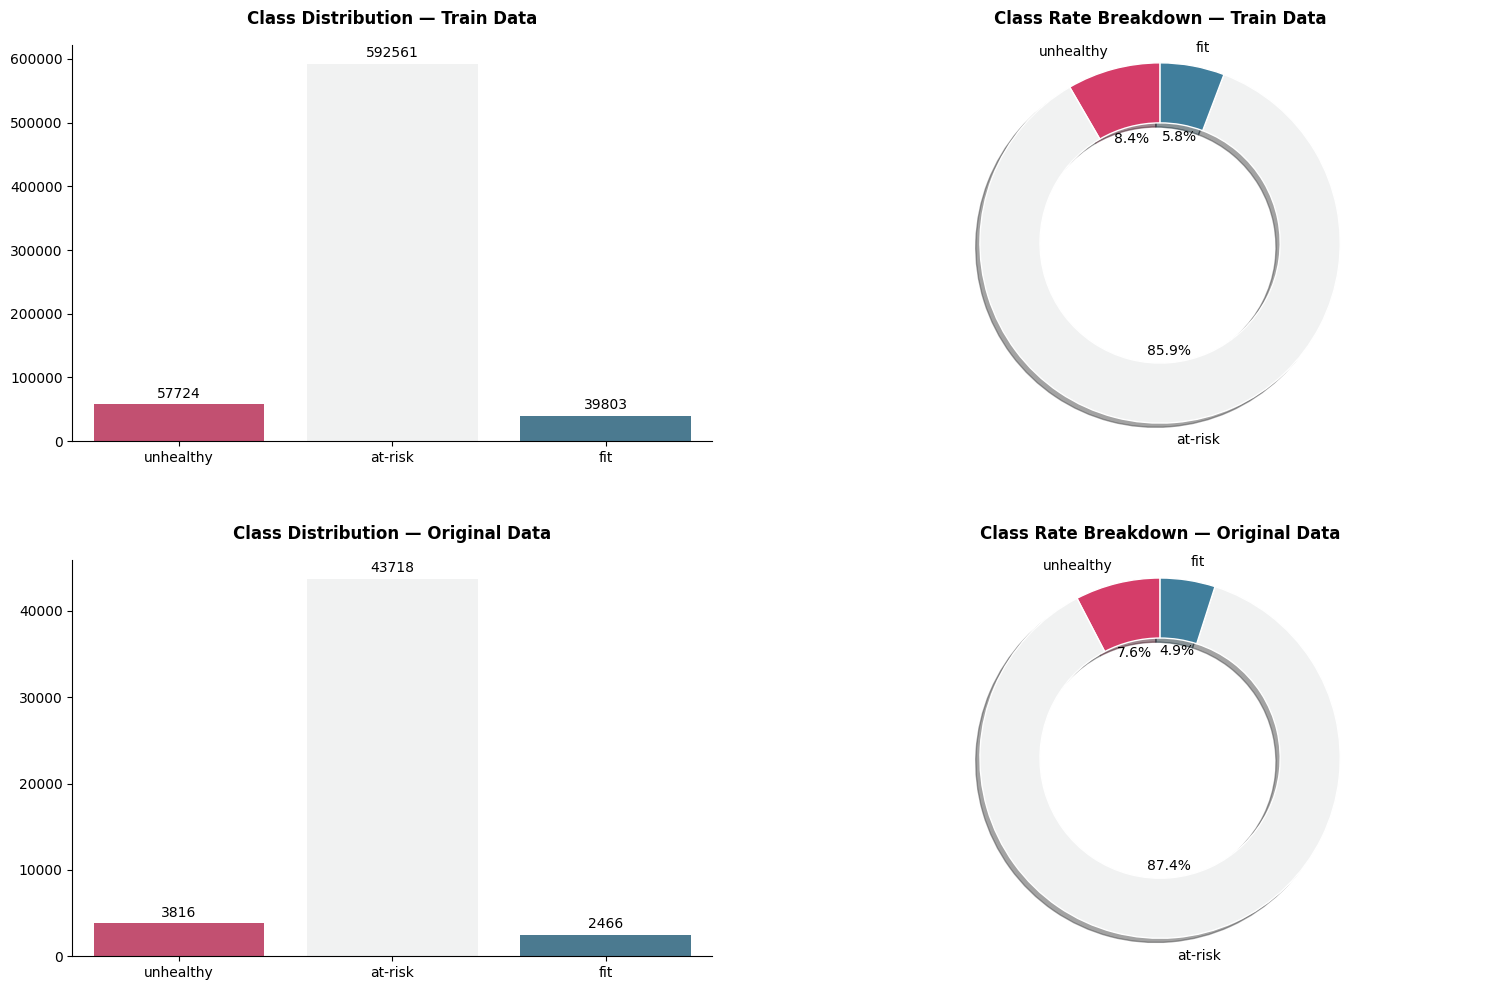

In [14]:
# Set target variable
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
datasets = [("Train Data", df_train), ("Original Data", df_original)]
n_color = df_train[CFG.TARGET_FEATURE].nunique()
health_condition_class = df_train[CFG.TARGET_FEATURE].unique().tolist()

for i, (title, data) in enumerate(datasets):
    ax = axes[i, 0]
    # Vertical barplot
    sns.countplot(x=CFG.TARGET_FEATURE, data=data, ax=ax,
                  palette=color(n_colors=n_color), order=health_condition_class)
    ax.set_title(f"Class Distribution — {title}", pad=15, weight="bold", fontsize=12)
    ax.set_xlabel("")
    ax.set_ylabel("")
    sns.despine(ax=ax, top=True, right=True, left=False, bottom=False)

    # Add count labels on top of bars
    for p in ax.patches:
        height = p.get_height()
        x = p.get_x() + p.get_width() / 2
        ax.text(x, height + max(data[CFG.TARGET_FEATURE].value_counts()) * 0.01,
                f"{int(height)}",
                ha="center", va="bottom", fontsize=10, color="black")

    # Pie chart
    y_counts = data[CFG.TARGET_FEATURE].value_counts().reindex(health_condition_class)
    wedges, texts, autotexts = axes[i, 1].pie(
        y_counts, autopct="%1.1f%%", startangle=90, colors=color(n_colors=n_color), wedgeprops=dict(width=0.4, edgecolor="w"),
        radius=1.2,  shadow=True, labels=health_condition_class)
    for text in texts + autotexts:
        text.set_fontsize(10)

    centre_circle = plt.Circle((0, 0), 0.70, fc="white")
    axes[i, 1].add_artist(centre_circle)
    axes[i, 1].set_title(f"Class Rate Breakdown — {title}", pad=15, weight="bold", fontsize=12)
    axes[i, 1].axis("equal")

plt.tight_layout()
plt.subplots_adjust(hspace=0.3, wspace=0.2)
plt.show()

<div style="
    background: linear-gradient(135deg, #1f2a44, #2c3e50);
    color: #ecf0f1;
    padding: 25px;
    border-radius: 12px;
    margin: 25px 0;
    box-shadow: 0 6px 18px rgba(0,0,0,0.25);
">

<div style="
    color:#f9e79f;
    margin: 0 0 20px 0;
    font-size: 22px;
    font-weight: 600;
    letter-spacing: 0.5px;
">
🏥 Health Condition Distribution
</div>

<table style="
    width:100%;
    border-collapse: collapse;
    margin-bottom: 20px;
    font-size: 15px;
">
<thead>
<tr style="background-color: rgba(249,231,159,0.15);">
<th style="padding:10px; border:1px solid rgba(255,255,255,0.2); text-align:left;">Dataset</th>
<th style="padding:10px; border:1px solid rgba(255,255,255,0.2); text-align:right;">At-risk</th>
<th style="padding:10px; border:1px solid rgba(255,255,255,0.2); text-align:right;">Unhealthy</th>
<th style="padding:10px; border:1px solid rgba(255,255,255,0.2); text-align:right;">Fit</th>
<th style="padding:10px; border:1px solid rgba(255,255,255,0.2); text-align:right;">At-risk Rate</th>
</tr>
</thead>

<tbody>

<tr>
<td style="padding:10px; border:1px solid rgba(255,255,255,0.2);"><b>Train</b></td>
<td style="padding:10px; border:1px solid rgba(255,255,255,0.2); text-align:right;">592,561</td>
<td style="padding:10px; border:1px solid rgba(255,255,255,0.2); text-align:right;">57,724</td>
<td style="padding:10px; border:1px solid rgba(255,255,255,0.2); text-align:right;">39,803</td>
<td style="padding:10px; border:1px solid rgba(255,255,255,0.2); text-align:right;"><b>85.9%</b></td>
</tr>

<tr>
<td style="padding:10px; border:1px solid rgba(255,255,255,0.2);"><b>Original</b></td>
<td style="padding:10px; border:1px solid rgba(255,255,255,0.2); text-align:right;">43,718</td>
<td style="padding:10px; border:1px solid rgba(255,255,255,0.2); text-align:right;">3,816</td>
<td style="padding:10px; border:1px solid rgba(255,255,255,0.2); text-align:right;">2,466</td>
<td style="padding:10px; border:1px solid rgba(255,255,255,0.2); text-align:right;"><b>87.4%</b></td>
</tr>

</tbody>
</table>

<ul style="line-height:1.8; padding-left:20px;">

<li>
<b>Majority class:</b> <code>at-risk</code> overwhelmingly dominates both datasets, accounting for approximately <b>86–87%</b> of all samples.
</li>

<li>
<b>Minority classes:</b> <code>unhealthy</code> represents about <b>8%</b>, while <code>fit</code> is the smallest class at only <b>5–6%</b>.
</li>

<li>
The class distributions in the <b>Train</b> and <b>Original</b> datasets are highly consistent, with only minor differences in class proportions.
</li>

<li>
The Train dataset contains a slightly higher proportion of <code>fit</code> and <code>unhealthy</code> samples, while the <code>at-risk</code> class is marginally reduced compared with the Original dataset.
</li>

<li>
Overall, the competition dataset preserves the original class distribution, suggesting there is <b>no significant class distribution shift</b> after data expansion.
</li>

</ul>

<div style="
    margin-top: 18px;
    padding: 12px 16px;
    background-color: rgba(249, 231, 159, 0.15);
    border-left: 4px solid #f9e79f;
    border-radius: 6px;
    font-size: 15px;
">
<b>Key Insight:</b> This is a <b>highly imbalanced multi-class classification problem</b>, with the <code>at-risk</code> class accounting for nearly 86% of all observations. Without appropriate handling, the model may become biased toward predicting the majority class while underperforming on the minority classes (<code>fit</code> and <code>unhealthy</code>). Techniques such as <b>class weighting</b>, <b>stratified cross-validation</b>, and <b>macro-averaged evaluation metrics</b> should be considered to achieve balanced performance across all health conditions.
</div>

</div>

## Numerical Feature Distributions

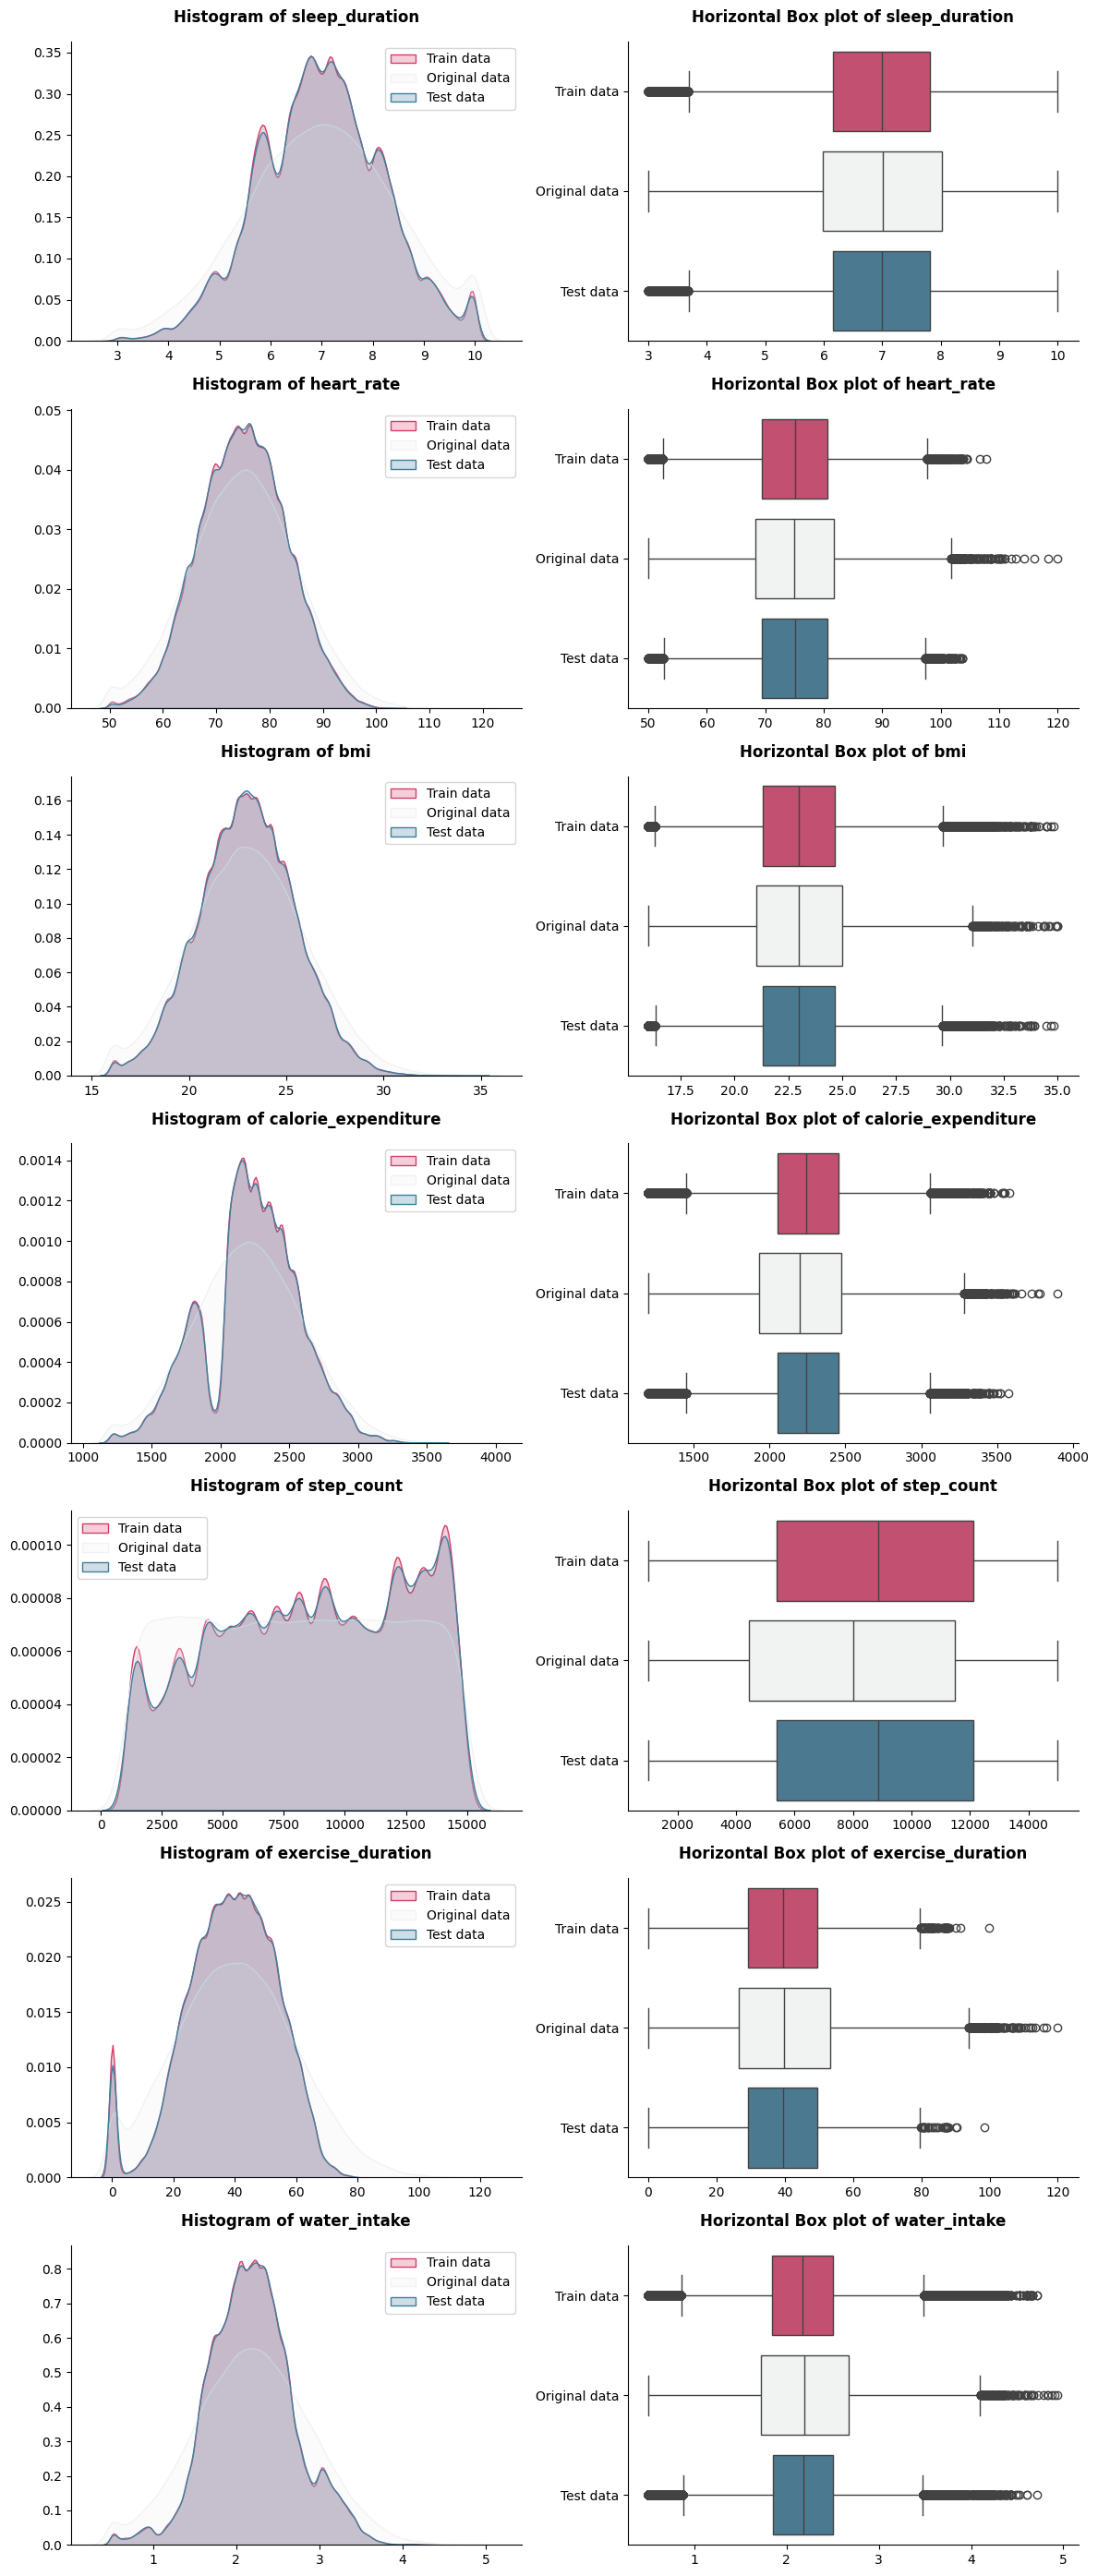

In [15]:
def plot_numerical_features(df_train: pd.DataFrame, df_test: pd.DataFrame, 
                            df_origin: pd.DataFrame, num_features: List[str]) -> None:
    """
    Plot histogram and boxplot for each numerical feature.

    - Histogram shows distribution and skewness.
    - Boxplot highlights median and potential outliers.
    """

    # Generate color palette for 3 datasets
    colors = color(n_colors=3, tone = "diverging")
    n = len(num_features)

    # Create subplot grid: each feature has 1 row, 2 columns (hist + boxplot)
    fig, ax = plt.subplots(n, 2, figsize=(12, n * 4))
    ax = np.array(ax).reshape(n, 2)

    for i, feature in enumerate(num_features):
        # Histogram + KDE Plot
        sns.kdeplot(data=df_train[feature], color=colors[0], ax=ax[i, 0], label="Train data", fill=True)
        sns.kdeplot(data=df_origin[feature], color=colors[1], ax=ax[i, 0], label="Original data", fill=True)
        sns.kdeplot(data=df_test[feature], color=colors[2], ax=ax[i, 0], label="Test data", fill=True)
        # Format histogram
        ax[i, 0].set_title(f"Histogram of {feature}", pad=15, weight="bold", fontsize=12)
        ax[i, 0].legend()
        ax[i, 0].set_xlabel("")
        ax[i, 0].set_ylabel("")
        sns.despine(left=False, bottom=False, ax=ax[i, 0])

        df_plot = pd.concat([
            pd.DataFrame({"Dataset": "Train data", feature: df_train[feature]}),
            pd.DataFrame({"Dataset": "Original data", feature: df_origin[feature]}),
            pd.DataFrame({"Dataset": "Test data", feature: df_test[feature]})
        ]).reset_index(drop=True)

        # Prepare Data for Boxplot
        sns.boxplot(
            data=df_plot,
            x=feature,
            y="Dataset",
            palette=colors,
            orient="h",
            ax=ax[i, 1]
        )
        ax[i, 1].set_title(f"Horizontal Box plot of {feature}", pad=15, weight="bold", fontsize=12)
        ax[i, 1].set_xlabel("")
        ax[i, 1].set_ylabel("")
        sns.despine(left=False, bottom=False, ax=ax[i, 1])

    # Adjust layout to prevent overlap
    plt.tight_layout()
    plt.show()

plot_numerical_features(df_train = df_train, df_test = df_test, df_origin = df_original, 
                        num_features=num_features)

### Analyze skewness

In [16]:
def check_skewness(data: pd.DataFrame, dataset_name: str, numerical_features: List[str] =num_features, 
                   sort=True, logger: logging.Logger=logger):
    """
    Analyze skewness of numerical features in a dataset and log summary insights.

    This function computes the skewness for each numerical feature, optionally
    sorts them by absolute skewness, and categorizes features based on the
    degree of skewness. Detailed results are logged at DEBUG level, while
    high-level insights and recommendations are logged at INFO level.

    Parameters
    ----------
    data : pandas.DataFrame
        The input dataset containing numerical features to be analyzed.

    dataset_name : str
        A descriptive name of the dataset, used for logging and reporting.

    numerical_features : list of str, optional
        List of numerical feature names to evaluate.
        Default is `num_features`.

    sort : bool, optional (default=True)
        If True, sort features by absolute skewness in descending order.

    logger : logging.Logger
        Logger object used to output analysis results and insights.

    Returns
    -------
    list of str
        A list of feature names that are considered highly skewed
        (|skewness| > 1).

    Notes
    -----
    - Skewness interpretation:
        * |skew| ≤ 0.5  : Approximately symmetric
        * 0.5 < |skew| ≤ 1 : Moderately skewed
        * |skew| > 1   : Highly skewed
    - Highly skewed features may benefit from transformations such as:
        log, Box-Cox, or Yeo-Johnson.
    - This function is intended for exploratory data analysis (EDA)
      and feature preprocessing stages.
    """

    skewness_dict = {}
    skew_features = []
    for feature in numerical_features:
        skew = data[feature].skew(skipna=True)
        skewness_dict[feature] = skew

    skew_df = pd.DataFrame.from_dict(skewness_dict, orient="index", columns=["Skewness"])
    if sort:
        skew_df = skew_df.reindex(skew_df["Skewness"].abs().sort_values(ascending=False).index)

    # ===== Summary header =====
    logger.info(f"Skewness analysis for {dataset_name}")
    logger.info(f"Total numerical features checked: {len(skew_df)}")

    # ===== Detailed table (DEBUG) =====
    logger.debug("-"*70)
    logger.debug(f"{'Feature':<30} | {'Skewness':<9} | {'Remark'}")
    logger.debug("-"*70)
    for feature, row in skew_df.iterrows():
        skew = row["Skewness"]
        abs_skew = abs(skew)
        if abs_skew > 1:
            remark = "Highly skewed"
            skew_features.append(feature)
        elif abs_skew > 0.5:
            remark = "Moderately skewed"
        else:
            remark = "Approximately symmetric"
        logger.debug(f"{feature:<30} | {skew:>+9.4f} | {remark}")
    logger.debug("-" * 70)

    # ===== Summary insight =====
    if skew_features:
        logger.info(f"{len(skew_features)} features are highly skewed (|skew| > 1).")
        logger.info(f"Recommendation: Consider log / Box-Cox / Yeo-Johnson transformation.")
    else:
        logger.info("No highly skewed features detected.")

    return skew_features

skew_feature = check_skewness(df_train, "Student Health Risk Data Train")
logger.info("-" * 80)
skew_feature_original = check_skewness(df_original, "Student Health Risk Data Original")
logger.info("-" * 80)
skew_feature_test = check_skewness(df_test, "Student Health Risk Data Test")
logger.info("-" * 80)
logger.info("Checking skewness successfully completed the dataset.")

2026-07-04 01:04:02 | INFO     | Skewness analysis for Student Health Risk Data Train
2026-07-04 01:04:02 | INFO     | Total numerical features checked: 7
2026-07-04 01:04:02 | DEBUG    | ----------------------------------------------------------------------
2026-07-04 01:04:02 | DEBUG    | Feature                        | Skewness  | Remark
2026-07-04 01:04:02 | DEBUG    | ----------------------------------------------------------------------
2026-07-04 01:04:02 | DEBUG    | exercise_duration              |   -0.3746 | Approximately symmetric
2026-07-04 01:04:02 | DEBUG    | calorie_expenditure            |   -0.1839 | Approximately symmetric
2026-07-04 01:04:02 | DEBUG    | step_count                     |   -0.1802 | Approximately symmetric
2026-07-04 01:04:02 | DEBUG    | water_intake                   |   +0.1100 | Approximately symmetric
2026-07-04 01:04:02 | DEBUG    | bmi                            |   +0.0246 | Approximately symmetric
2026-07-04 01:04:02 | DEBUG    | sleep_dur

### Correlation Analysis of Numerical Features

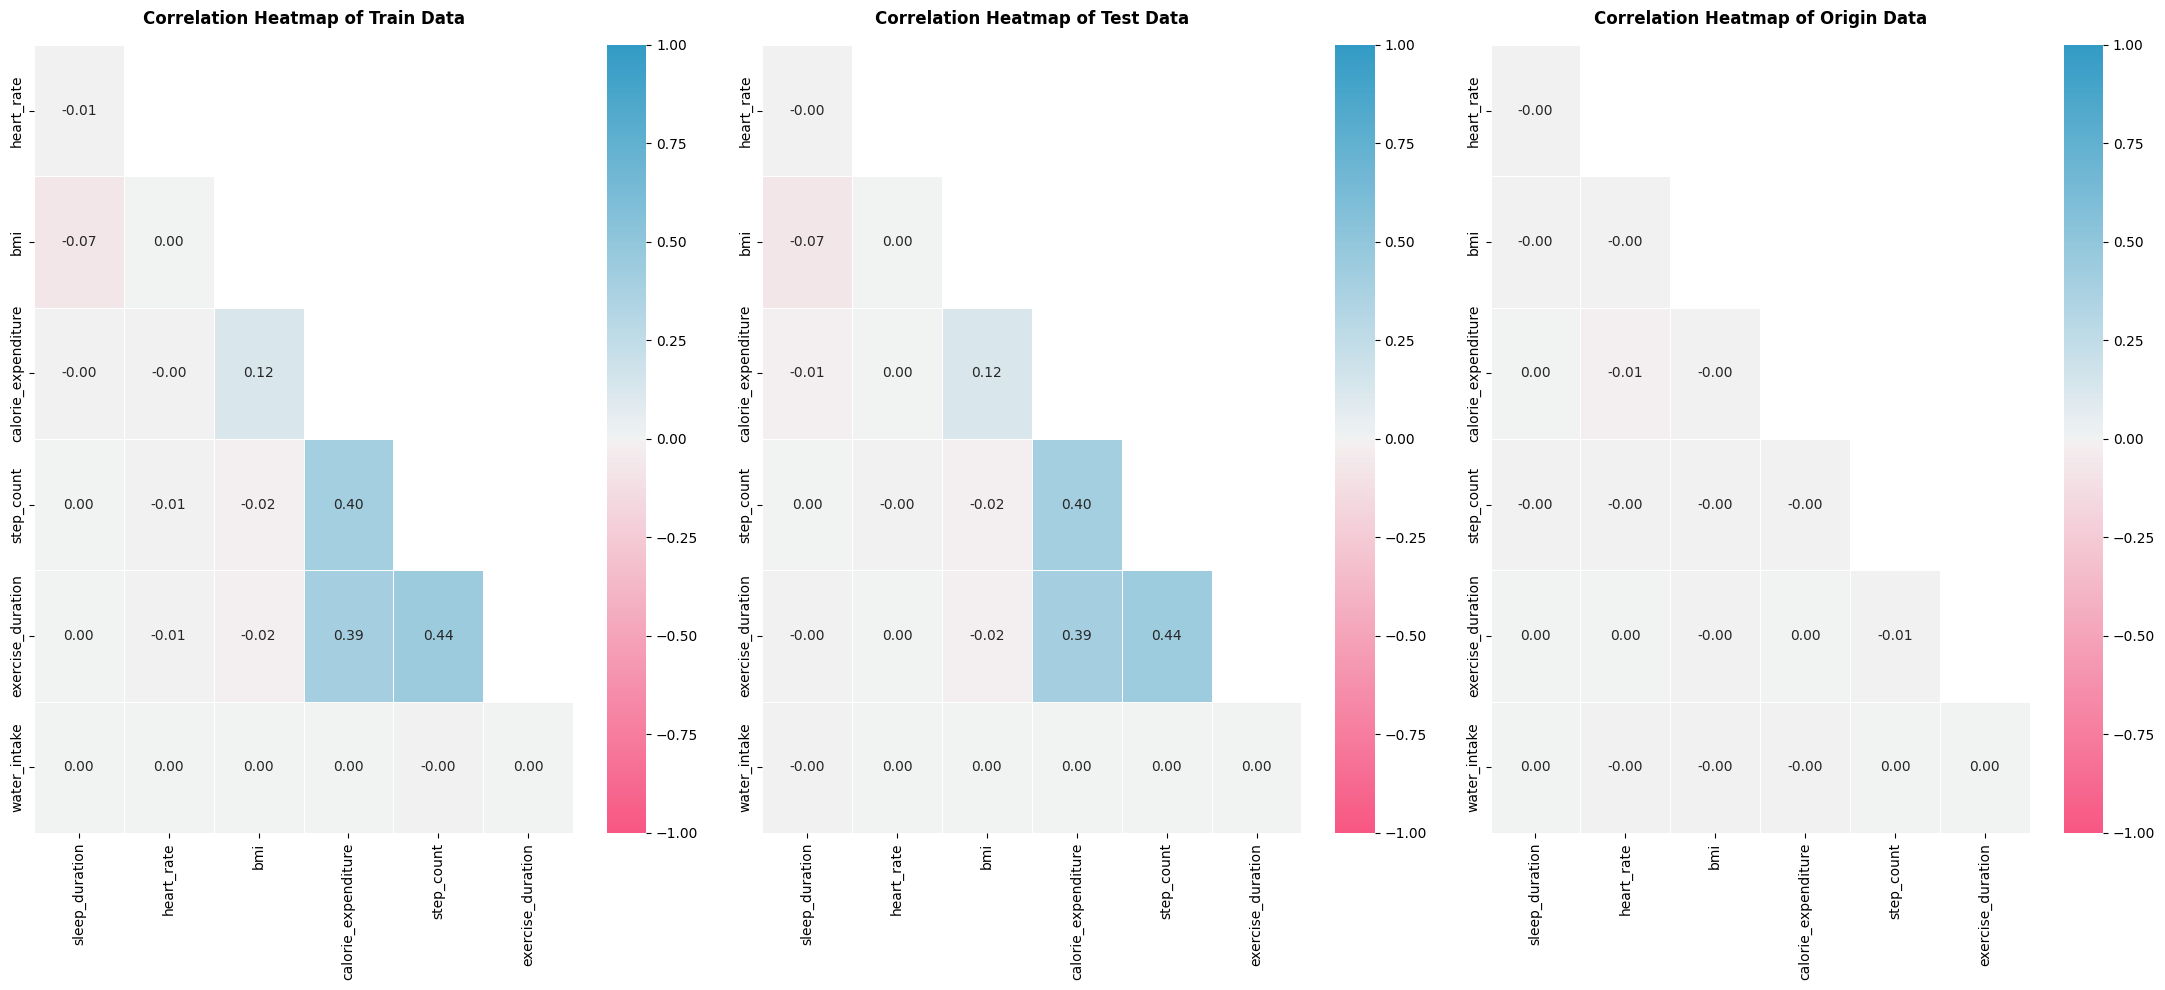

In [17]:
def plot_correlation(df_train, df_origin, df_test, origin_name="Origin Data", train_name="Train Data", test_name="Test Data"):
    """
    Plot side-by-side correlation heatmaps for training and test datasets.

    This function computes Pearson correlation matrices for numerical features
    in both training and test datasets, applies a triangular mask to avoid
    duplicated information, and visualizes the results using seaborn heatmaps.

    Parameters
    ----------
    df_train : pandas.DataFrame
        Training dataset (features only, target column should be removed).

    df_test : pandas.DataFrame
        Test dataset (features only).

    train_name : str, default="Train Data"
        Title name for the training heatmap.

    test_name : str, default="Test Data"
        Title name for the test heatmap.

    Returns
    -------
    None
        Displays correlation heatmaps for train and test datasets.
    """

    corr_train = df_train.corr(numeric_only=True)
    corr_origin = df_origin.corr(numeric_only=True)
    corr_test = df_test.corr(numeric_only=True)

    mask_train = np.triu(np.ones_like(corr_train, dtype=bool))
    adjusted_mask_train = mask_train[1:, :-1]
    adjusted_cereal_corr_train = corr_train.iloc[1:, :-1]

    mask_origin = np.triu(np.ones_like(corr_origin, dtype=bool))
    adjusted_mask_origin = mask_origin[1:, :-1]
    adjusted_cereal_corr_origin = corr_origin.iloc[1:, :-1]

    mask_test = np.triu(np.ones_like(corr_test, dtype=bool))
    adjusted_mask_test = mask_test[1:, :-1]
    adjusted_cereal_corr_test = corr_test.iloc[1:, :-1]

    cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)
    fig, ax = plt.subplots(1, 3, figsize=(22, 10))

    sns.heatmap(data=adjusted_cereal_corr_train, mask=adjusted_mask_train,
                annot=True, fmt=".2f", cmap=cmap,
                vmin=-1, vmax=1, linecolor="white", linewidths=0.5, ax=ax[0])
    ax[0].set_title(f"Correlation Heatmap of {train_name}", fontsize=12, weight="bold", pad=15)

    sns.heatmap(data=adjusted_cereal_corr_test, mask=adjusted_mask_test,
                annot=True, fmt=".2f", cmap=cmap,
                vmin=-1, vmax=1, linecolor="white", linewidths=0.5, ax=ax[1])
    ax[1].set_title(f"Correlation Heatmap of {test_name}", fontsize=12, weight="bold", pad=15)

    sns.heatmap(data=adjusted_cereal_corr_origin, mask=adjusted_mask_origin,
                annot=True, fmt=".2f", cmap=cmap,
                vmin=-1, vmax=1, linecolor="white", linewidths=0.5, ax=ax[2])
    ax[2].set_title(f"Correlation Heatmap of {origin_name}", fontsize=12, weight="bold", pad=15)

    plt.tight_layout()
    plt.show()

plot_correlation(df_train=df_train.drop(columns=CFG.TARGET_FEATURE),
                 df_origin=df_original.drop(columns=CFG.TARGET_FEATURE),
                 df_test=df_test)

<div style="
    background: linear-gradient(135deg, #1f2a44, #2c3e50);
    color: #ecf0f1;
    padding: 25px;
    border-radius: 12px;
    margin: 25px 0;
    box-shadow: 0 6px 18px rgba(0,0,0,0.25);
">

<div style="
    color:#f9e79f;
    margin: 0 0 20px 0;
    font-size: 22px;
    font-weight: 600;
    letter-spacing: 0.5px;
">
📊 Correlation & Distribution Analysis (Health Features)
</div>

<ul style="line-height: 1.8; padding-left: 20px;">

<li>
Correlation analysis shows that <b>most numerical features have weak relationships</b>, indicating they capture different aspects of students' health and lifestyle.
</li>

<li>
The strongest positive correlations are observed between:
<ul style="margin-top:8px; line-height:1.7;">
<li><code>step_count ↔ exercise_duration</code>: <b>0.44</b></li>
<li><code>step_count ↔ calorie_expenditure</code>: <b>0.40</b></li>
<li><code>exercise_duration ↔ calorie_expenditure</code>: <b>0.39</b></li>
</ul>
These relationships are expected since more physical activity generally leads to higher calorie expenditure.
</li>

<li>
Other feature pairs exhibit <b>very weak or near-zero correlations</b>, suggesting minimal multicollinearity among the remaining variables.
</li>

</ul>

<h3>Distribution & Skewness Analysis</h3>

<ul style="line-height: 1.8; padding-left: 20px;">

<li>
Histograms show that most numerical features follow <b>approximately symmetric distributions</b>, which is confirmed by the skewness analysis.
</li>

<li>
<b>No highly skewed features</b> were detected in the Train, Test, or Original datasets, so distribution transformation is generally unnecessary.
</li>

<li>
Box plots reveal several outliers in features such as <code>heart_rate</code>, <code>bmi</code>, <code>calorie_expenditure</code>, and <code>water_intake</code>, while <code>step_count</code> remains relatively stable.</li>

</ul>

<h3>Train–Test Consistency</h3>

<ul style="line-height: 1.8; padding-left: 20px;">

<li>
The Train and Test datasets exhibit <b>nearly identical distributions and correlation patterns</b>, indicating excellent statistical consistency.
</li>

<li>
The Original dataset follows the same overall trends, although it shows slightly greater variability in some numerical features.
</li>

<li>
Overall, there is <b>no significant distribution drift</b>, providing a reliable foundation for model training and evaluation.
</li>

</ul>

<div style="
    margin-top: 18px;
    padding: 12px 16px;
    background-color: rgba(249, 231, 159, 0.15);
    border-left: 4px solid #f9e79f;
    border-radius: 6px;
    font-size: 15px;
">

<b>Modeling Implications:</b>

<ul style="margin-top:8px; padding-left:18px; line-height:1.7;">

<li>
The absence of highly skewed features means that <b>log or power transformations are generally unnecessary</b>.
</li>

<li>
The moderate correlations among physical activity variables are unlikely to cause serious multicollinearity, especially for tree-based models such as <code>CatBoost</code>, <code>LightGBM</code>, and <code>XGBoost</code>.
</li>

<li>
Since the Train and Test datasets share highly similar statistical characteristics, the risk of train–test distribution mismatch is low.
</li>
</ul>
</div>
</div>

## Categorical Feature Distributions

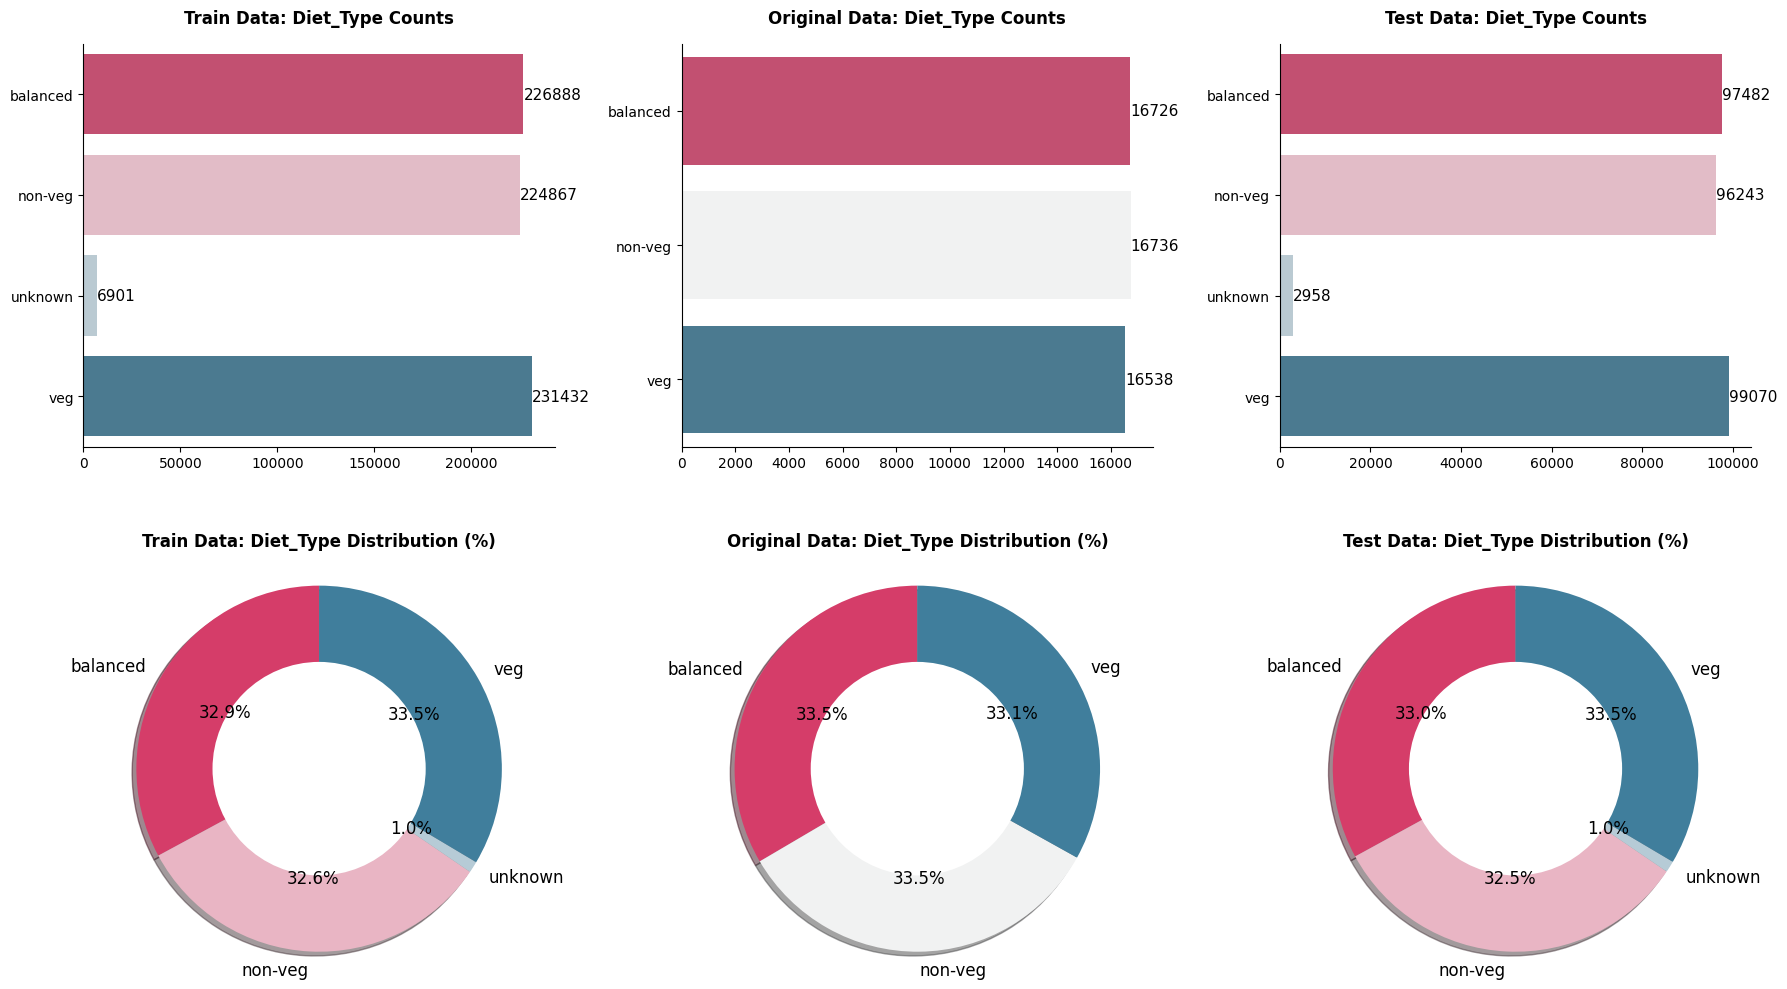

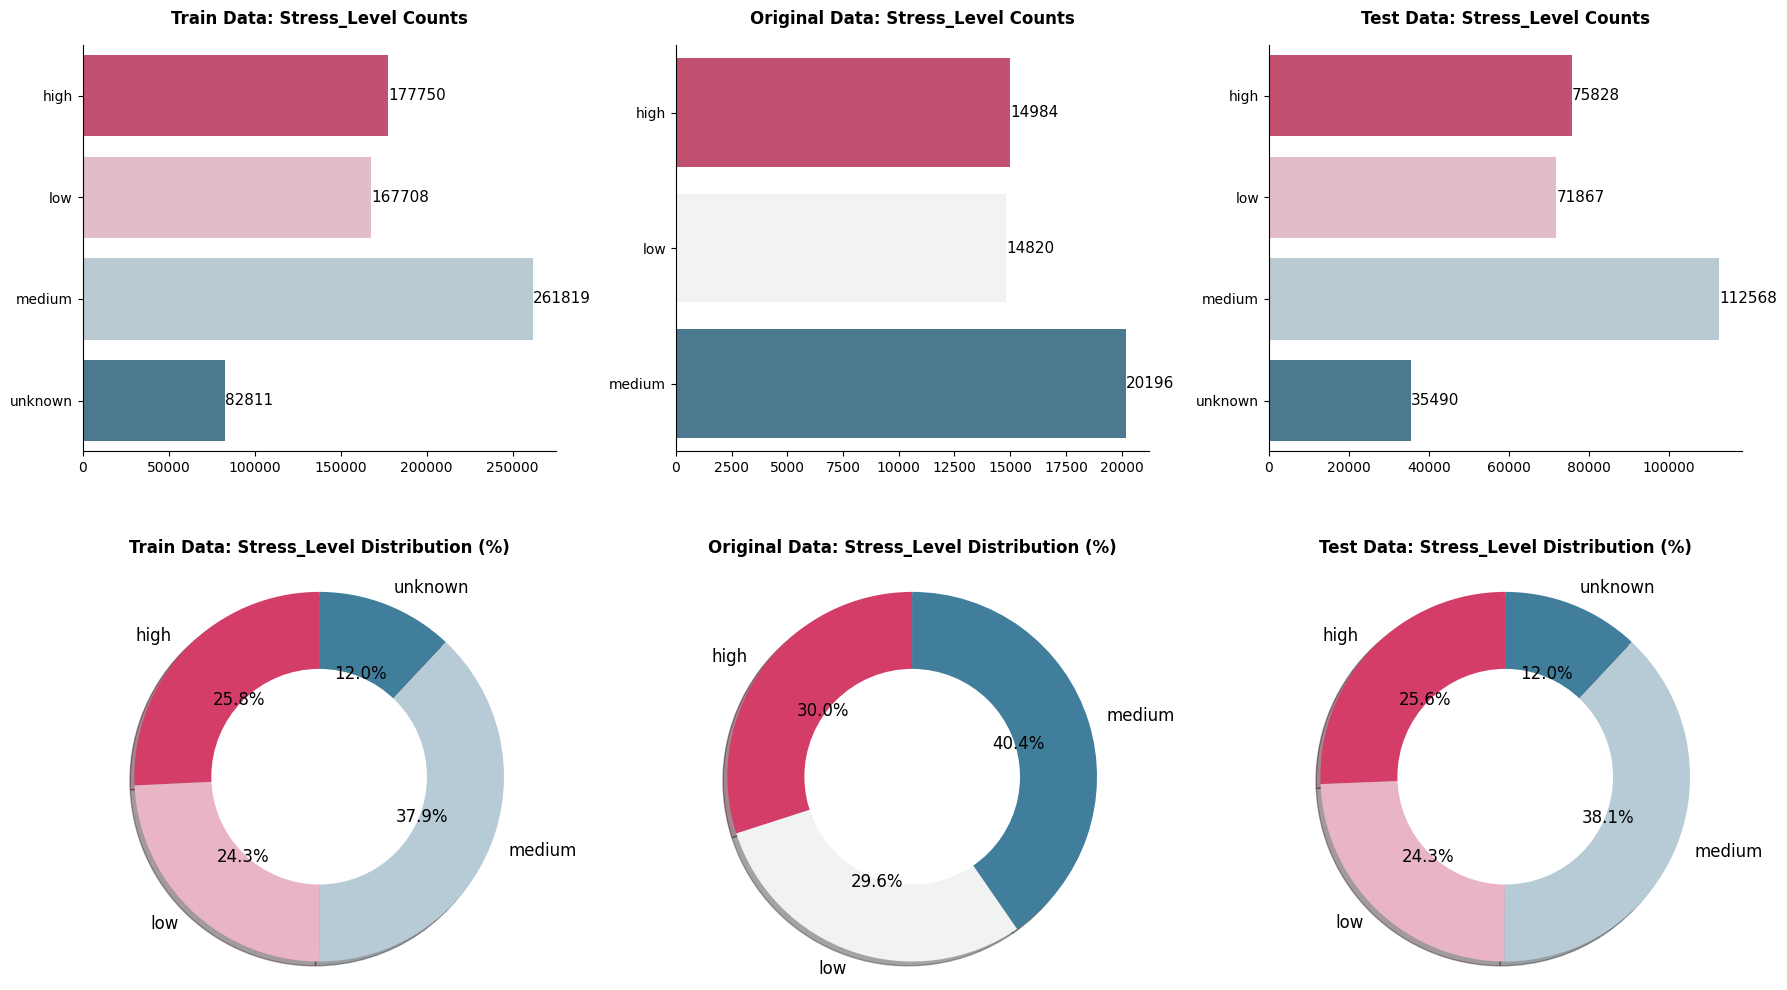

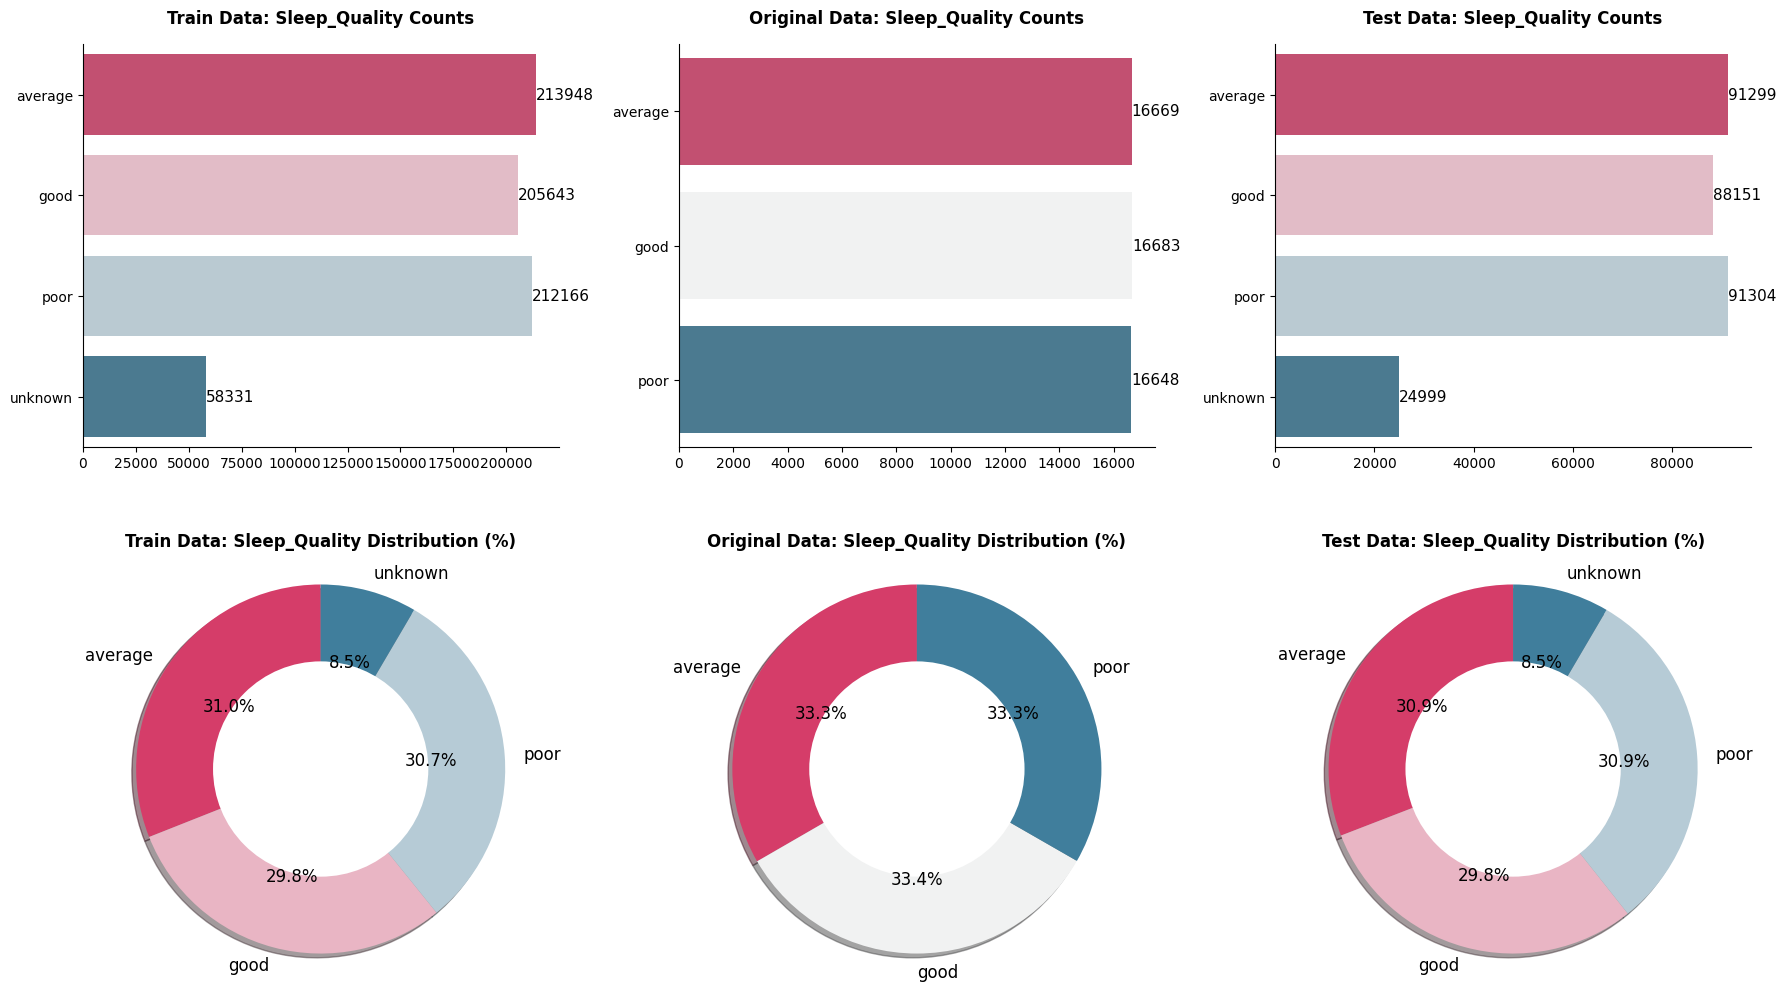

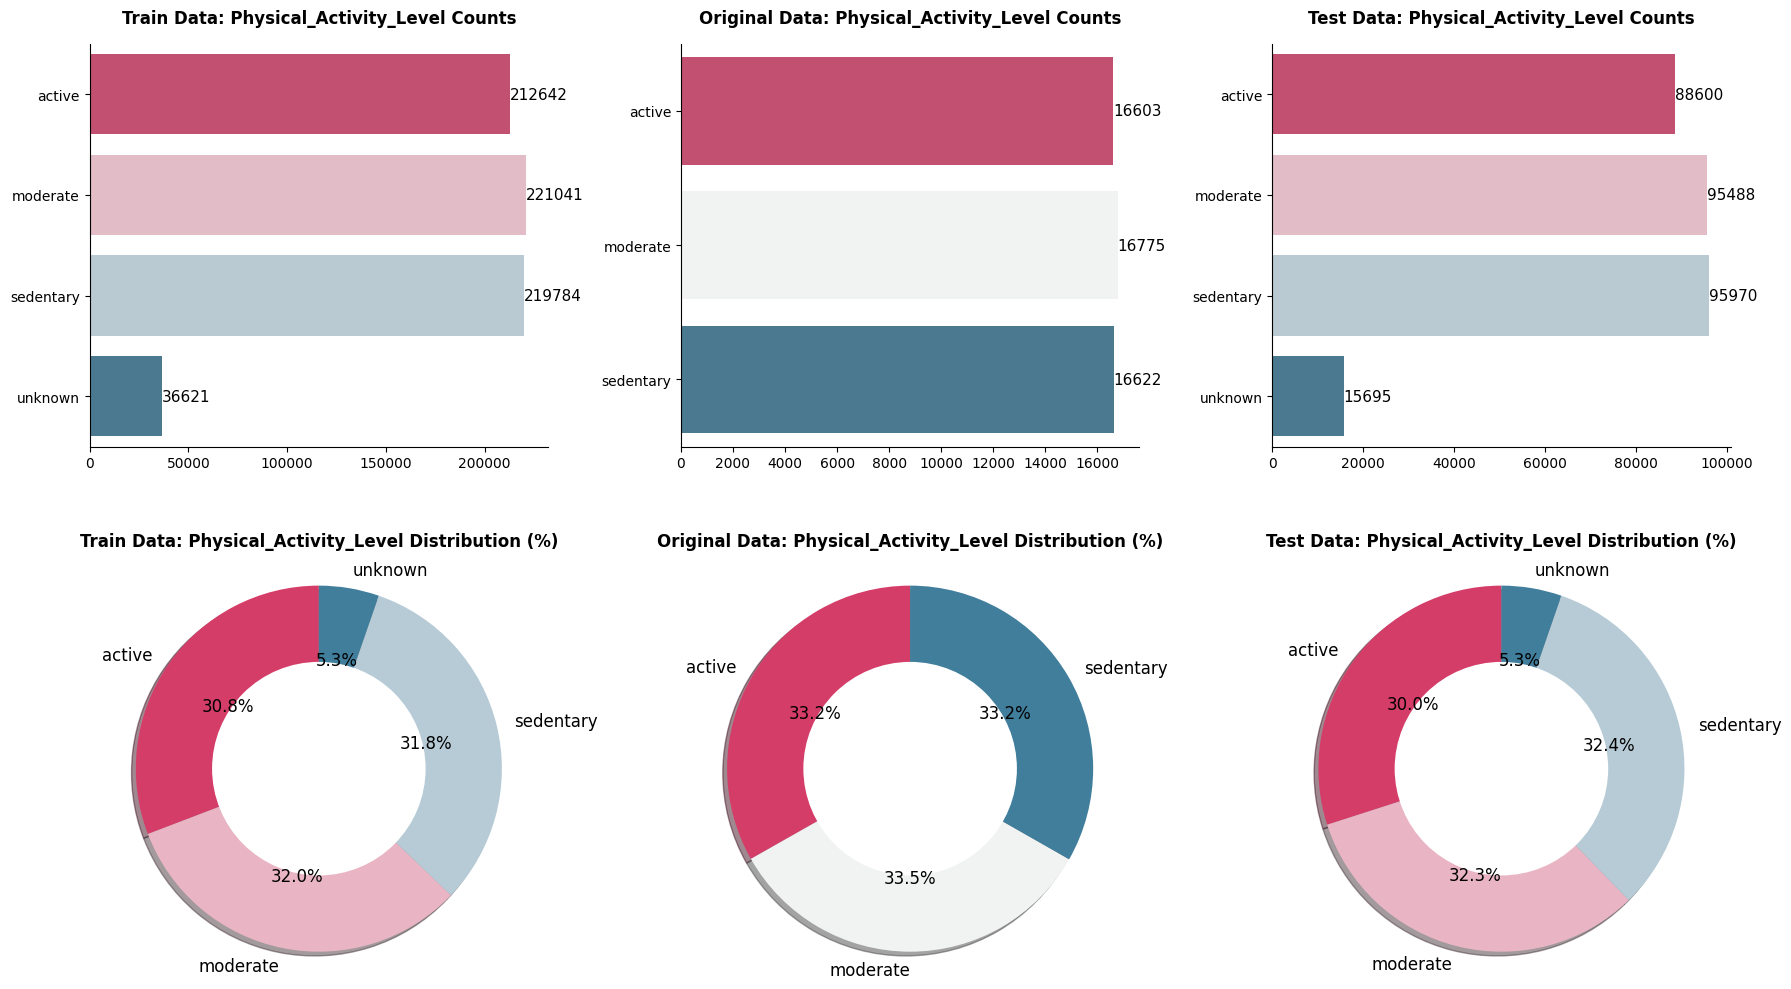

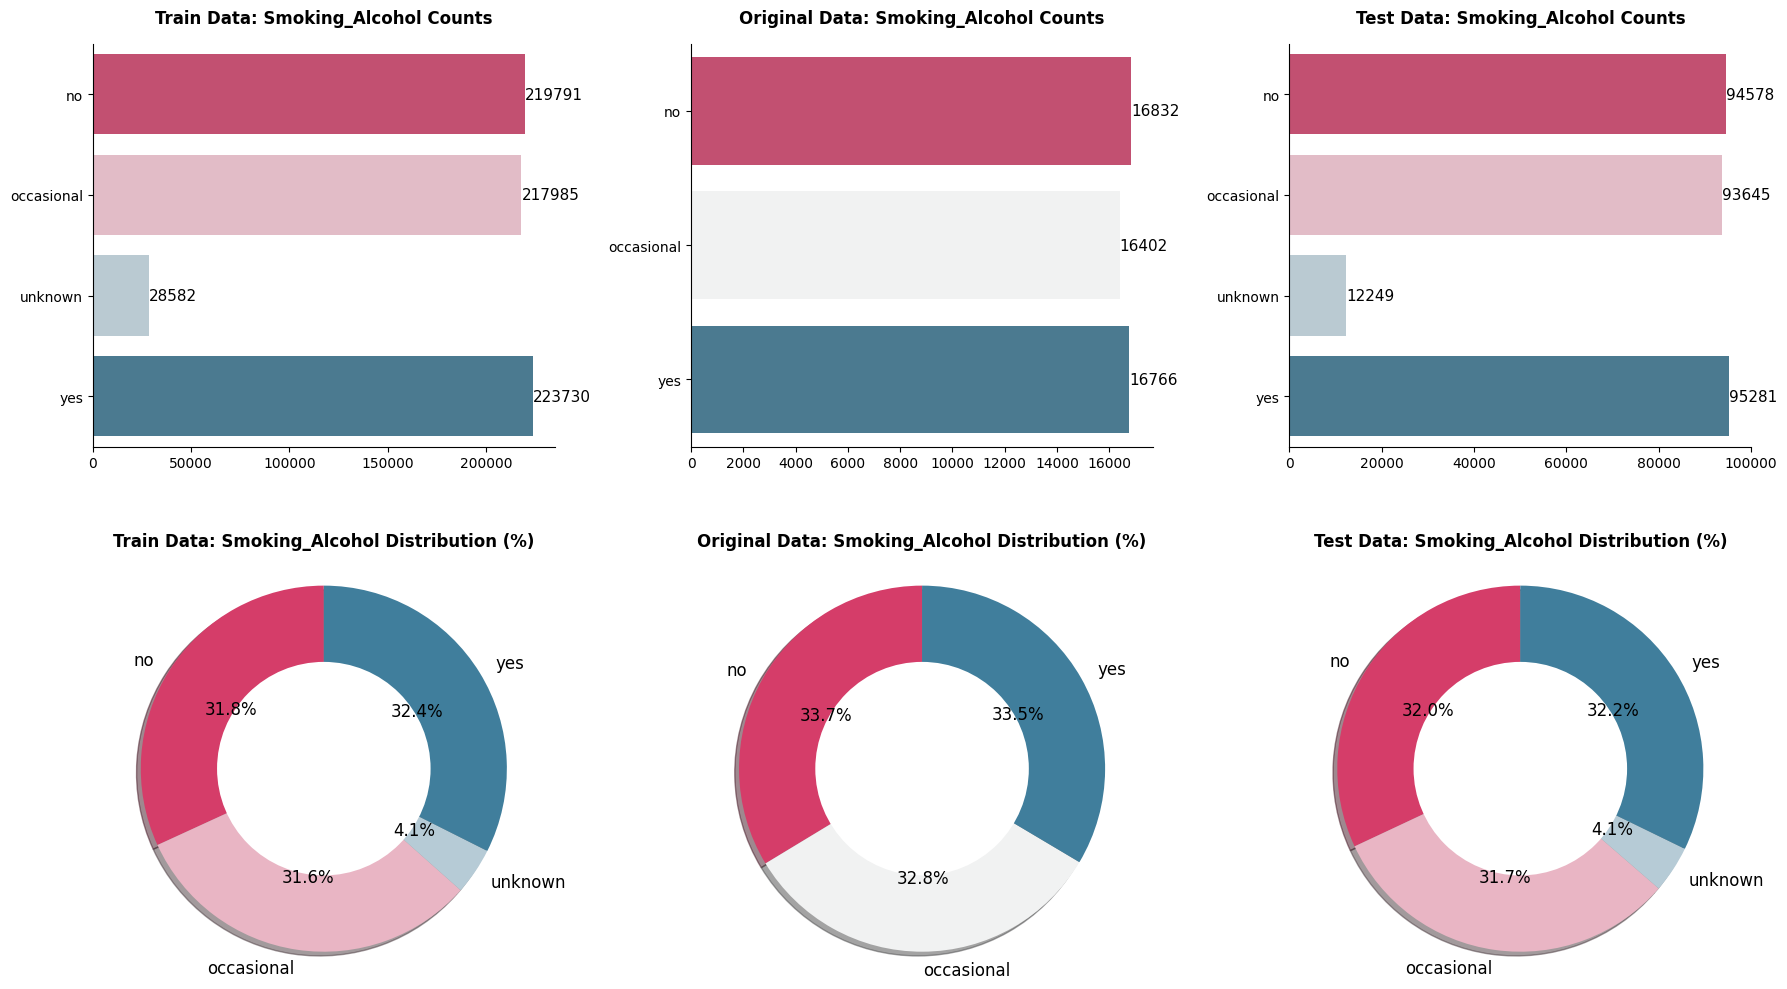

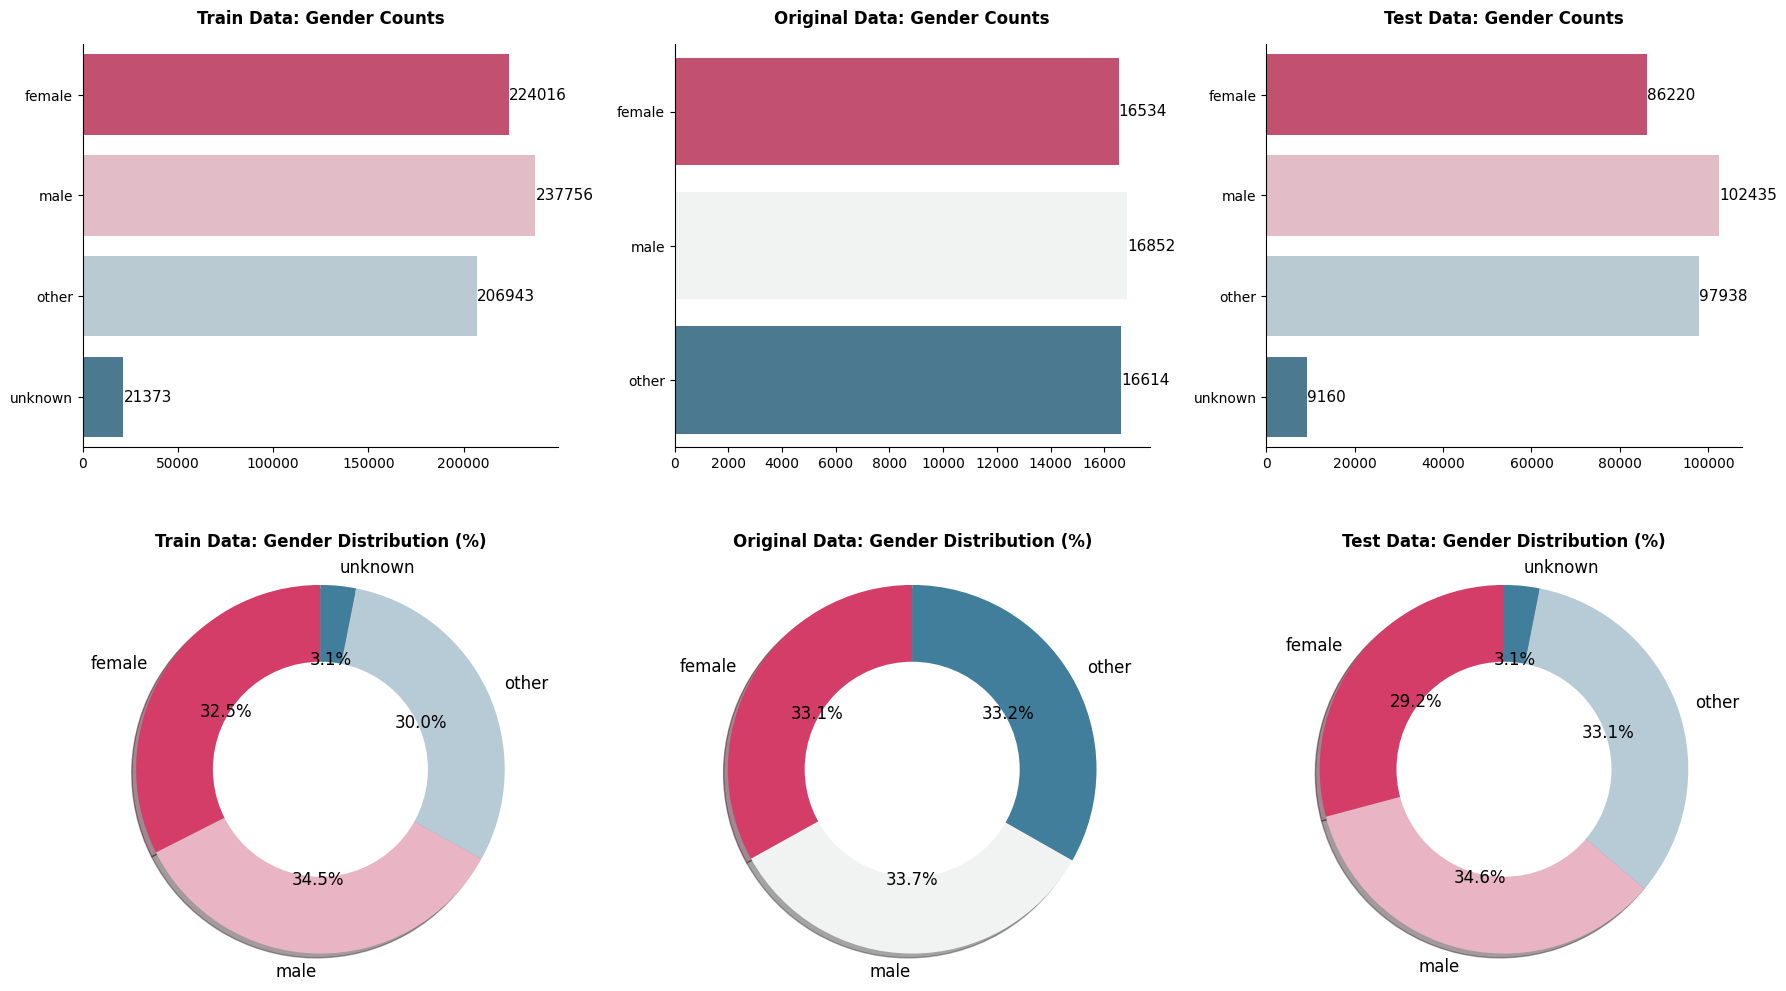

In [18]:
def plot_categorical_distribution_across_datasets(
    train_data: pd.DataFrame,
    original_data: pd.DataFrame,
    test_data: pd.DataFrame,
    feature: str
) -> None:
    """
    Plot categorical feature distribution across Train, Original, and Test datasets.
    """

    dataset_names = ["Train", "Original", "Test"]
    datasets = [train_data, original_data, test_data]

    # Get consistent category order from all datasets
    order = sorted(
        set(train_data[feature].dropna().unique())
        | set(original_data[feature].dropna().unique())
        | set(test_data[feature].dropna().unique())
    )

    fig, ax = plt.subplots(2, 3, figsize=(18, 10))

    # Row 1: Count plots
    for i, (data, name) in enumerate(zip(datasets, dataset_names)):
        counts = data[feature].value_counts().reindex(order, fill_value=0)
        counts = counts[counts > 0]
        plot_order = counts.index.tolist()
        plot_colors = color(n_colors=len(plot_order))
        sns.countplot(y=feature, data=data, ax=ax[0, i], palette=plot_colors, order=plot_order)
        ax[0, i].set_title(f"{name} Data: {feature.title()} Counts", fontsize=12, weight="bold", pad=15)
        ax[0, i].set_xlabel("")
        ax[0, i].set_ylabel("")

        for p in ax[0, i].patches:
            width = p.get_width()
            if width > 0:
                ax[0, i].annotate(
                    f"{int(width)}",
                    (width, p.get_y() + p.get_height() / 2),
                    ha="left",
                    va="center",
                    color="black",
                    fontsize=11
                )

        ax[0, i].set_axisbelow(True)
        sns.despine(ax=ax[0, i])

    # Row 2: Donut pie charts
    for i, (data, name) in enumerate(zip(datasets, dataset_names)):
        counts = data[feature].value_counts().reindex(order, fill_value=0).astype(float)
        counts = counts[counts > 0]
        pie_order = counts.index.tolist()
        pie_colors = color(n_colors=len(pie_order))
        ax[1, i].pie(
            counts,
            labels=pie_order,
            autopct="%1.1f%%",
            startangle=90,
            colors=pie_colors,
            textprops={"fontsize": 12},
            radius=1.2,
            shadow=True
        )

        centre_circle = plt.Circle((0, 0), 0.70, fc="white")
        ax[1, i].add_artist(centre_circle)
        ax[1, i].set_title(f"{name} Data: {feature.title()} Distribution (%)", fontsize=12, weight="bold", pad=15)
        ax[1, i].axis("equal")

    plt.tight_layout()
    plt.subplots_adjust(hspace=0.3)
    plt.show()

# Fill missing categorical values with "unknown"
for df in [df_train, df_test, df_original]:
    for feature in cat_features:
        if "unknown" not in df[feature].cat.categories:
            df[feature] = df[feature].cat.add_categories(["unknown"])
        df[feature] = df[feature].fillna("unknown")

# Apply function to all categorical features
for feature in cat_features:
    plot_categorical_distribution_across_datasets(df_train, df_original, df_test, feature)

<div style="
    background: linear-gradient(135deg, #1f2a44, #2c3e50);
    color: #ecf0f1;
    padding: 25px;
    border-radius: 12px;
    margin: 25px 0;
    box-shadow: 0 6px 18px rgba(0,0,0,0.25);
">

<div style="
    color:#f9e79f;
    margin: 0 0 20px 0;
    font-size: 22px;
    font-weight: 600;
    letter-spacing: 0.5px;
">
📊 Categorical Feature Distribution Analysis
</div>

<ul style="line-height: 1.8; padding-left: 20px;">

<li>
All categorical features (<code>diet_type</code>, <code>stress_level</code>, <code>sleep_quality</code>, <code>physical_activity_level</code>, <code>smoking_alcohol</code>, and <code>gender</code>) exhibit <b>highly consistent distributions</b> across the Train, Test, and Original datasets.
</li>

<li>
The Original dataset shows an almost <b>balanced distribution</b> for every categorical feature, while the Train and Test datasets maintain similar proportions after data expansion.
</li>

<li>
The <code>Unknown</code> category appears only in the Train and Test datasets, reflecting the presence of missing values, whereas the Original dataset contains <b>no missing categorical data</b>.
</li>

<li>
For all categorical features, no single category overwhelmingly dominates the others. Most valid categories account for approximately <b>25–40%</b> of their respective distributions, indicating a well-balanced representation.
</li>

<li>
The Train and Test datasets share nearly identical categorical distributions, suggesting <b>minimal distribution drift</b> and consistent synthetic data generation.
</li>

</ul>

<div style="
    margin-top: 18px;
    padding: 12px 16px;
    background-color: rgba(249, 231, 159, 0.15);
    border-left: 4px solid #f9e79f;
    border-radius: 6px;
    font-size: 15px;
">

<b>Key Insight:</b> The categorical feature distributions remain highly stable across datasets, providing a reliable foundation for model training and evaluation. The primary difference is the introduction of the <code>Unknown</code> category in the Train and Test datasets due to missing values, which should be treated as a valid category during modeling rather than discarded.

</div>

</div>

## Multivariate Statistical Analysis

,health_condition,Count,Mean,Median,Std
0,fit,35447,7.954311,7.840000,0.777578
1,at-risk,527253,7.086467,7.030000,1.143340
2,unhealthy,51389,5.366118,5.530000,0.670365


2026-07-04 01:04:13 | INFO     | Checking normality of feature 'sleep_duration' by groups of 'health_condition'...
2026-07-04 01:04:13 | INFO     | Evaluating distribution characteristics (skewness & kurtosis)...
2026-07-04 01:04:13 | DEBUG    | Number of groups detected: 3
2026-07-04 01:04:13 | DEBUG    | Thresholds → |skew|≤0.5, |kurtosis|≤1.5
2026-07-04 01:04:14 | DEBUG    | [health_condition=at-risk] skew=0.0353, kurtosis=0.1209 → Approximately symmetric, Normal tails
2026-07-04 01:04:14 | DEBUG    | [health_condition=fit] skew=0.3187, kurtosis=0.9792 → Approximately symmetric, Normal tails
2026-07-04 01:04:14 | DEBUG    | [health_condition=unhealthy] skew=0.2388, kurtosis=5.1453 → Approximately symmetric, Heavy/light tails
2026-07-04 01:04:14 | INFO     | Generating Q–Q plots for visual assessment...


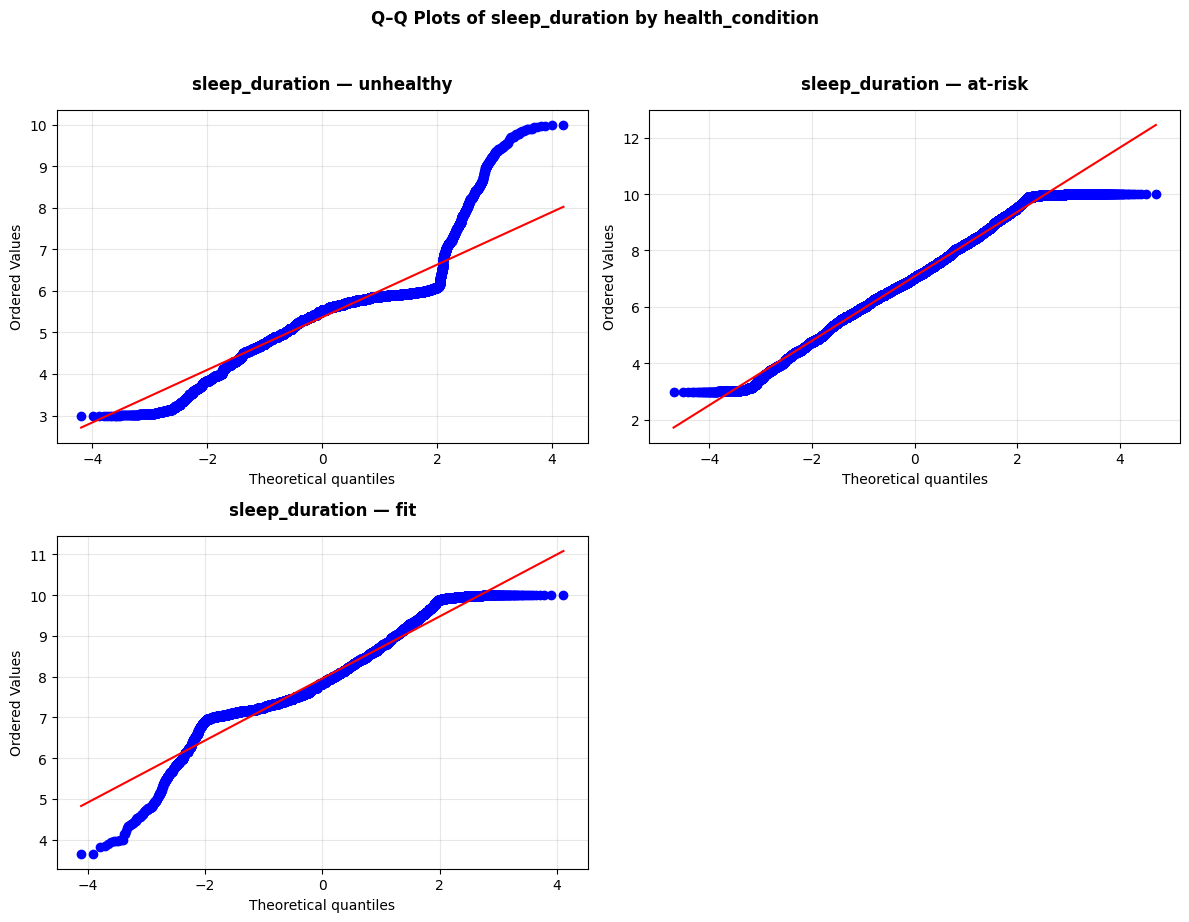

,Feature,Group,Skewness,Kurtosis,Remark
0,sleep_duration,at-risk,0.0353,0.1209,"Approximately symmetric, Normal tails"
1,sleep_duration,fit,0.3187,0.9792,"Approximately symmetric, Normal tails"
2,sleep_duration,unhealthy,0.2388,5.1453,"Approximately symmetric, Heavy/light tails"


2026-07-04 01:04:16 | WARNING  | Normality assumption violated in at least one group.
2026-07-04 01:04:16 | INFO     | Recommendation: Use non-parametric tests (Kruskal–Wallis / Mann–Whitney U).
2026-07-04 01:04:16 | INFO     | Kruskal-Wallis Test: sleep_duration ~ health_condition...
2026-07-04 01:04:16 | DEBUG    | Number of groups detected: 3
2026-07-04 01:04:16 | INFO     | Kruskal-Wallis H-statistic: 119475.238
2026-07-04 01:04:16 | INFO     | p-value: 0.0
2026-07-04 01:04:16 | INFO     | Significant difference detected among groups (p < 0.05).
2026-07-04 01:04:16 | DEBUG    | Running Dunn's Post-Hoc Test (Bonferroni corrected)...
           at-risk  fit  unhealthy
at-risk        1.0  0.0        0.0
fit            0.0  1.0        0.0
unhealthy      0.0  0.0        1.0


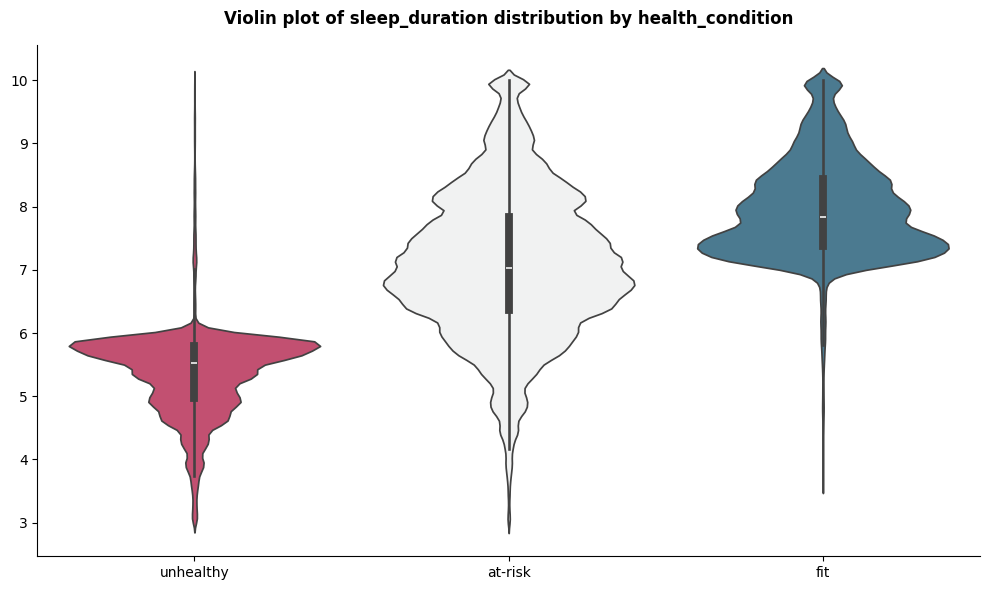

,health_condition,Count,Mean,Median,Std
0,unhealthy,57145,75.256897,75.099998,7.954250
1,at-risk,585740,75.100533,75.099998,8.192666
2,fit,39370,74.803741,74.500000,8.222343


2026-07-04 01:04:19 | INFO     | Checking normality of feature 'heart_rate' by groups of 'health_condition'...
2026-07-04 01:04:19 | INFO     | Evaluating distribution characteristics (skewness & kurtosis)...
2026-07-04 01:04:19 | DEBUG    | Number of groups detected: 3
2026-07-04 01:04:19 | DEBUG    | Thresholds → |skew|≤0.5, |kurtosis|≤1.5
2026-07-04 01:04:19 | DEBUG    | [health_condition=at-risk] skew=-0.0072, kurtosis=-0.1879 → Approximately symmetric, Normal tails
2026-07-04 01:04:19 | DEBUG    | [health_condition=fit] skew=0.1090, kurtosis=-0.1781 → Approximately symmetric, Normal tails
2026-07-04 01:04:19 | DEBUG    | [health_condition=unhealthy] skew=0.0074, kurtosis=-0.1788 → Approximately symmetric, Normal tails
2026-07-04 01:04:19 | INFO     | Generating Q–Q plots for visual assessment...


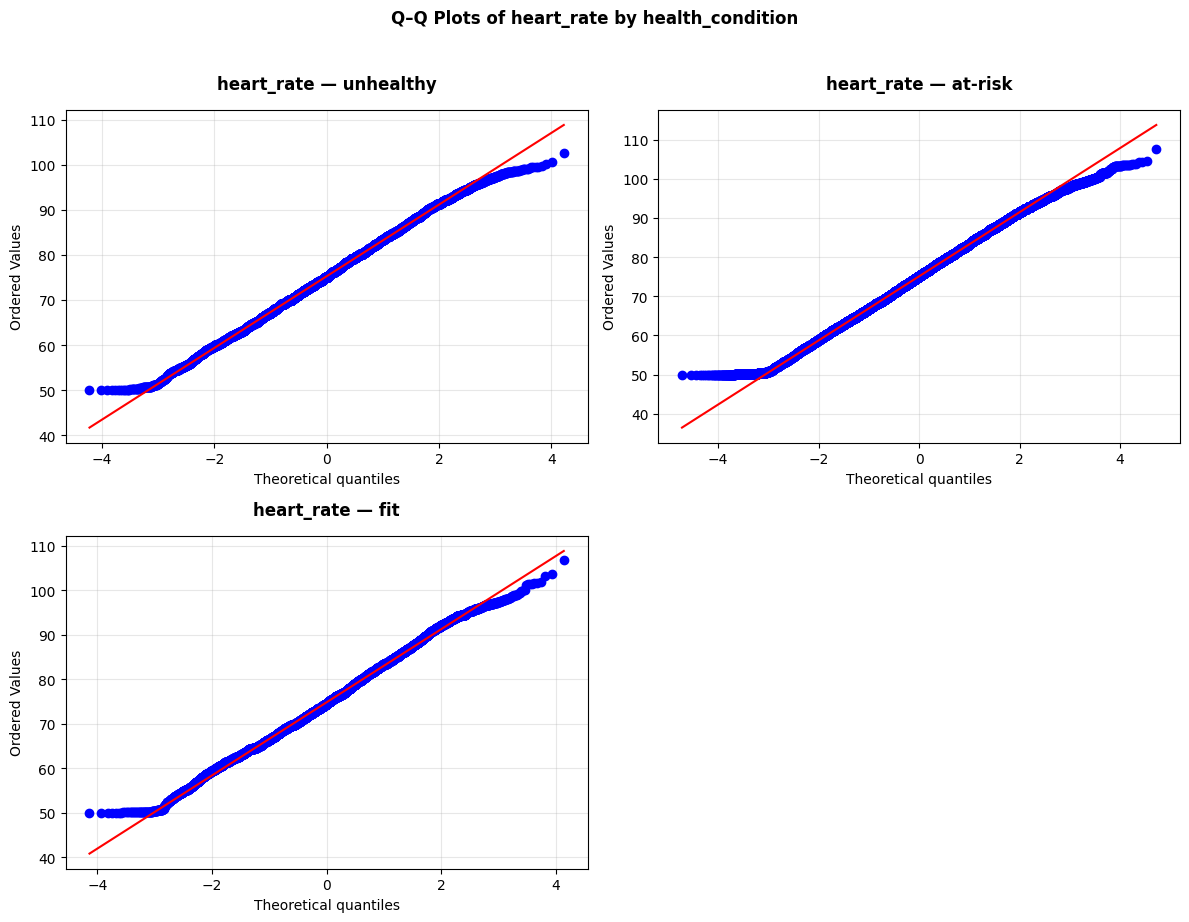

,Feature,Group,Skewness,Kurtosis,Remark
0,heart_rate,at-risk,-0.0072,-0.1879,"Approximately symmetric, Normal tails"
1,heart_rate,fit,0.1090,-0.1781,"Approximately symmetric, Normal tails"
2,heart_rate,unhealthy,0.0074,-0.1788,"Approximately symmetric, Normal tails"


2026-07-04 01:04:20 | INFO     | All groups approximately follow a normal distribution.
2026-07-04 01:04:21 | INFO     | Check homogeneity of variances across groups using Levene’s test (median-centered)
2026-07-04 01:04:21 | DEBUG    | Number of groups detected: 3


,Metric,Value
0,Levene’s Statistic,44.9863
1,p-value,0.000000
2,Max/Min Variance Ratio,1.07


2026-07-04 01:04:21 | INFO     | Interpretation:
2026-07-04 01:04:21 | INFO     | - Status: Statistically different variances, but practical difference is small.
2026-07-04 01:04:21 | INFO     | - Recommendation: ANOVA or T-Test are acceptable, but Welch’s ANOVA or Welch’s T-Test is recommended.
2026-07-04 01:04:21 | INFO     | Running Welch’s ANOVA Test: heart_rate ~ health_condition
2026-07-04 01:04:21 | DEBUG    | Number of groups detected: 3
2026-07-04 01:04:21 | INFO     | Assessing mean differences under heteroscedastic conditions...
2026-07-04 01:04:21 | INFO     | Welch ANOVA F-statistic: 36.6398
2026-07-04 01:04:21 | INFO     | p-value: 0.000000
2026-07-04 01:04:21 | DEBUG    | Welch ANOVA table:
             Source  ddof1         ddof2         F         p-unc       np2
0  health_condition      2  71752.658331  36.63976  1.246448e-16  0.000106
2026-07-04 01:04:21 | INFO     | Result: p-value < 0.05 → Reject H0
2026-07-04 01:04:21 | INFO     | Conclusion: Significant mean diffe

,A,B,mean(A),mean(B),diff,se,T,df,pval,hedges
0,at-risk,fit,75.1005,74.8037,0.2968,0.0428,6.9345,44783.8327,0.0000,0.0362
1,at-risk,unhealthy,75.1005,75.2569,-0.1564,0.0350,-4.4735,69509.2337,0.0000,-0.0191
2,fit,unhealthy,74.8037,75.2569,-0.4532,0.0531,-8.5268,82790.0036,0.0000,-0.0562


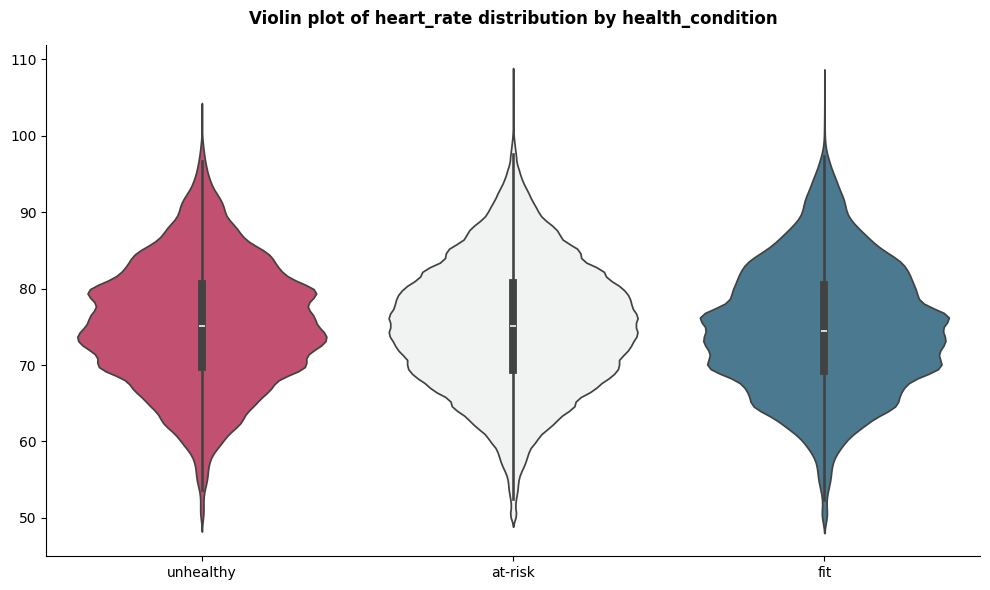

,health_condition,Count,Mean,Median,Std
0,unhealthy,57317,24.122660,23.700001,2.594285
1,at-risk,580209,22.949591,22.959999,2.422431
2,fit,38664,21.828545,22.250000,2.531088


2026-07-04 01:04:24 | INFO     | Checking normality of feature 'bmi' by groups of 'health_condition'...
2026-07-04 01:04:24 | INFO     | Evaluating distribution characteristics (skewness & kurtosis)...
2026-07-04 01:04:24 | DEBUG    | Number of groups detected: 3
2026-07-04 01:04:24 | DEBUG    | Thresholds → |skew|≤0.5, |kurtosis|≤1.5
2026-07-04 01:04:24 | DEBUG    | [health_condition=at-risk] skew=-0.0234, kurtosis=-0.2594 → Approximately symmetric, Normal tails
2026-07-04 01:04:24 | DEBUG    | [health_condition=fit] skew=-0.5603, kurtosis=-0.4804 → Moderately skewed, Normal tails
2026-07-04 01:04:24 | DEBUG    | [health_condition=unhealthy] skew=0.6773, kurtosis=-0.0837 → Moderately skewed, Normal tails
2026-07-04 01:04:24 | INFO     | Generating Q–Q plots for visual assessment...


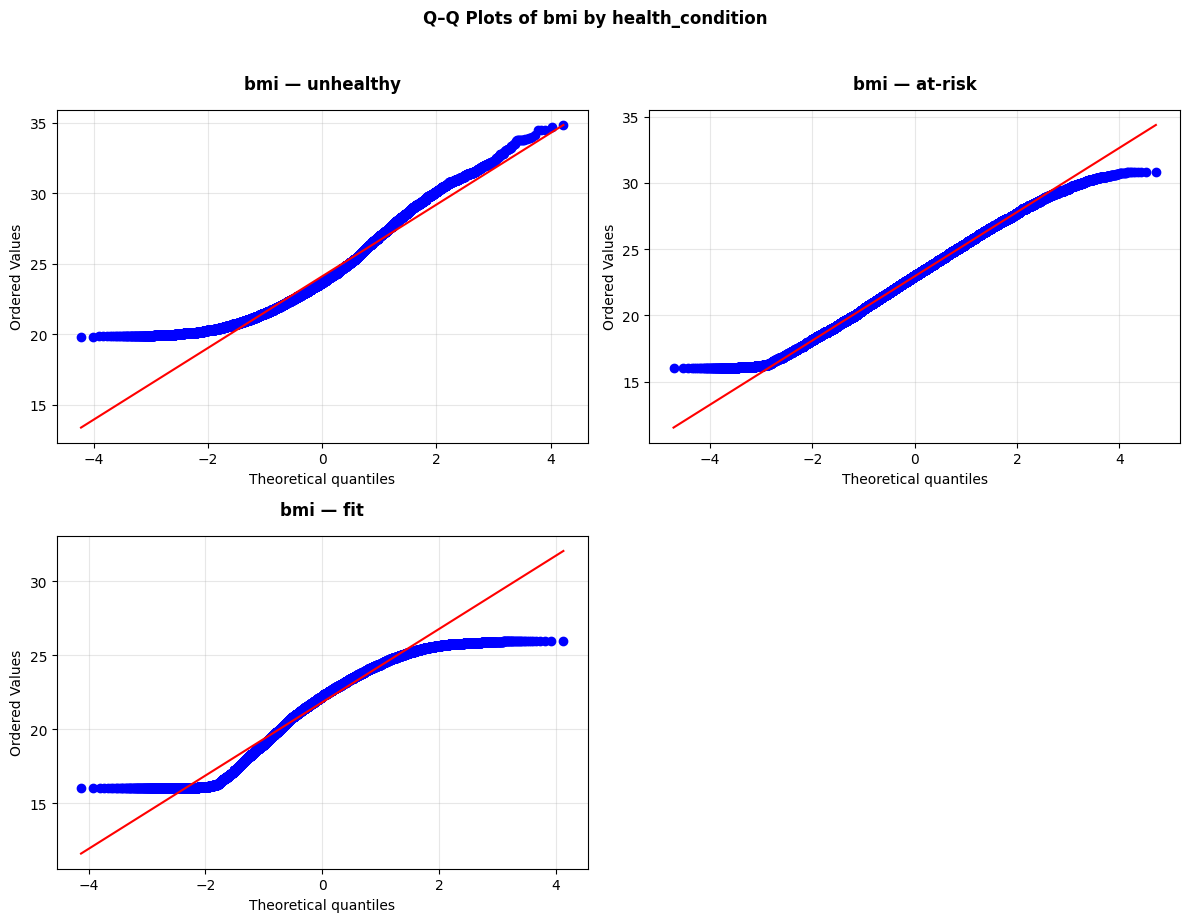

,Feature,Group,Skewness,Kurtosis,Remark
0,bmi,at-risk,-0.0234,-0.2594,"Approximately symmetric, Normal tails"
1,bmi,fit,-0.5603,-0.4804,"Moderately skewed, Normal tails"
2,bmi,unhealthy,0.6773,-0.0837,"Moderately skewed, Normal tails"


2026-07-04 01:04:26 | WARNING  | Normality assumption violated in at least one group.
2026-07-04 01:04:26 | INFO     | Recommendation: Use non-parametric tests (Kruskal–Wallis / Mann–Whitney U).
2026-07-04 01:04:26 | INFO     | Kruskal-Wallis Test: bmi ~ health_condition...
2026-07-04 01:04:26 | DEBUG    | Number of groups detected: 3
2026-07-04 01:04:26 | INFO     | Kruskal-Wallis H-statistic: 13329.348
2026-07-04 01:04:26 | INFO     | p-value: 0.0
2026-07-04 01:04:26 | INFO     | Significant difference detected among groups (p < 0.05).
2026-07-04 01:04:26 | DEBUG    | Running Dunn's Post-Hoc Test (Bonferroni corrected)...
           at-risk  fit  unhealthy
at-risk        1.0  0.0        0.0
fit            0.0  1.0        0.0
unhealthy      0.0  0.0        1.0


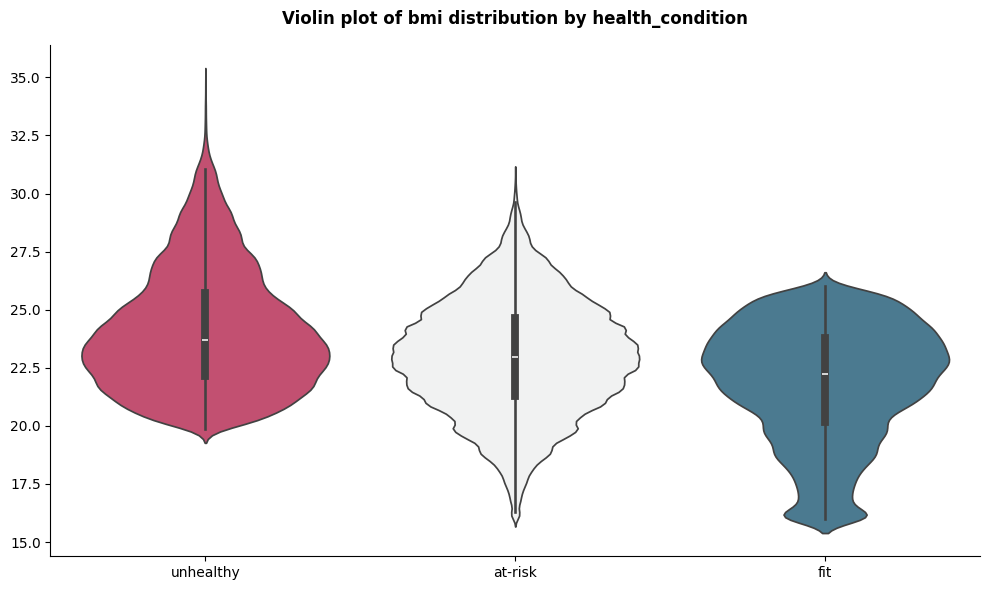

,health_condition,Count,Mean,Median,Std
0,fit,36738,2363.991943,2345.000000,312.395569
1,unhealthy,53286,2245.420166,2255.000000,348.343567
2,at-risk,547211,2214.943604,2235.000000,347.625275


2026-07-04 01:04:29 | INFO     | Checking normality of feature 'calorie_expenditure' by groups of 'health_condition'...
2026-07-04 01:04:29 | INFO     | Evaluating distribution characteristics (skewness & kurtosis)...
2026-07-04 01:04:29 | DEBUG    | Number of groups detected: 3
2026-07-04 01:04:29 | DEBUG    | Thresholds → |skew|≤0.5, |kurtosis|≤1.5
2026-07-04 01:04:29 | DEBUG    | [health_condition=at-risk] skew=-0.1932, kurtosis=-0.0906 → Approximately symmetric, Normal tails
2026-07-04 01:04:29 | DEBUG    | [health_condition=fit] skew=0.0877, kurtosis=-0.1617 → Approximately symmetric, Normal tails
2026-07-04 01:04:29 | DEBUG    | [health_condition=unhealthy] skew=-0.1423, kurtosis=-0.0054 → Approximately symmetric, Normal tails
2026-07-04 01:04:29 | INFO     | Generating Q–Q plots for visual assessment...


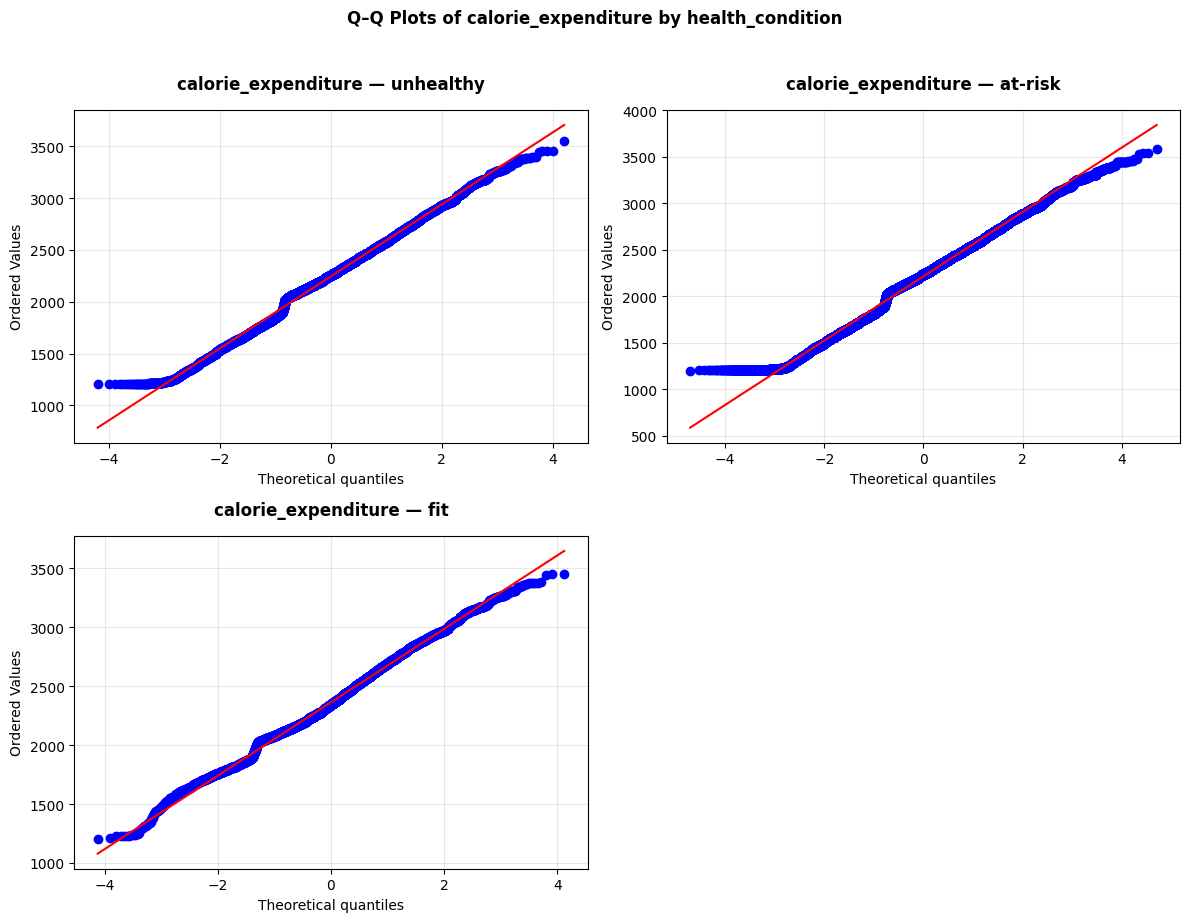

,Feature,Group,Skewness,Kurtosis,Remark
0,calorie_expenditure,at-risk,-0.1932,-0.0906,"Approximately symmetric, Normal tails"
1,calorie_expenditure,fit,0.0877,-0.1617,"Approximately symmetric, Normal tails"
2,calorie_expenditure,unhealthy,-0.1423,-0.0054,"Approximately symmetric, Normal tails"


2026-07-04 01:04:30 | INFO     | All groups approximately follow a normal distribution.
2026-07-04 01:04:30 | INFO     | Check homogeneity of variances across groups using Levene’s test (median-centered)
2026-07-04 01:04:30 | DEBUG    | Number of groups detected: 3


,Metric,Value
0,Levene’s Statistic,159.8398
1,p-value,0.000000
2,Max/Min Variance Ratio,1.24


2026-07-04 01:04:31 | INFO     | Interpretation:
2026-07-04 01:04:31 | INFO     | - Status: Statistically different variances, but practical difference is small.
2026-07-04 01:04:31 | INFO     | - Recommendation: ANOVA or T-Test are acceptable, but Welch’s ANOVA or Welch’s T-Test is recommended.
2026-07-04 01:04:31 | INFO     | Running Welch’s ANOVA Test: calorie_expenditure ~ health_condition
2026-07-04 01:04:31 | DEBUG    | Number of groups detected: 3
2026-07-04 01:04:31 | INFO     | Assessing mean differences under heteroscedastic conditions...
2026-07-04 01:04:31 | INFO     | Welch ANOVA F-statistic: 3933.5793
2026-07-04 01:04:31 | INFO     | p-value: 0.000000
2026-07-04 01:04:31 | DEBUG    | Welch ANOVA table:
             Source  ddof1         ddof2           F  p-unc      np2
0  health_condition      2  67728.160802  3933.57934    0.0  0.01022
2026-07-04 01:04:31 | INFO     | Result: p-value < 0.05 → Reject H0
2026-07-04 01:04:31 | INFO     | Conclusion: Significant mean differ

,A,B,mean(A),mean(B),diff,se,T,df,pval,hedges
0,at-risk,fit,2214.9436,2363.9919,-149.0483,1.6962,-87.8701,43078.1603,0.0000,-0.4314
1,at-risk,unhealthy,2214.9436,2245.4202,-30.4766,1.5805,-19.2828,64060.8631,0.0000,-0.0877
2,fit,unhealthy,2363.9919,2245.4202,118.5718,2.2212,53.3826,84106.4120,0.0000,0.3549


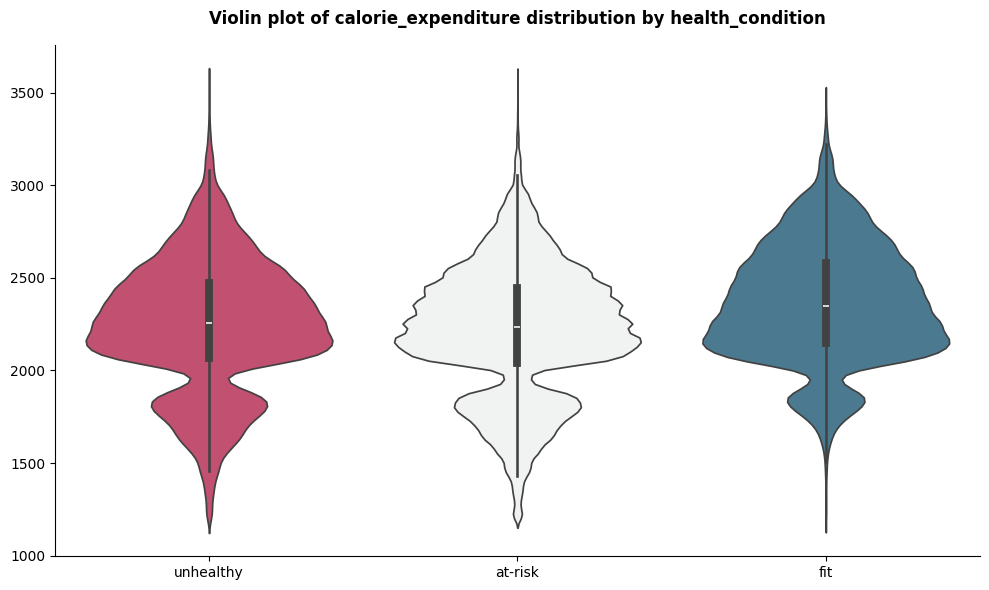

,health_condition,Count,Mean,Median,Std
0,fit,39010,11651.306641,12342.500000,2655.613281
1,unhealthy,56598,8670.234375,8941.500000,3918.243164
2,at-risk,580564,8406.706055,8483.000000,3917.807861


2026-07-04 01:04:34 | INFO     | Checking normality of feature 'step_count' by groups of 'health_condition'...
2026-07-04 01:04:34 | INFO     | Evaluating distribution characteristics (skewness & kurtosis)...
2026-07-04 01:04:34 | DEBUG    | Number of groups detected: 3
2026-07-04 01:04:34 | DEBUG    | Thresholds → |skew|≤0.5, |kurtosis|≤1.5
2026-07-04 01:04:34 | DEBUG    | [health_condition=at-risk] skew=-0.1219, kurtosis=-1.1289 → Approximately symmetric, Normal tails
2026-07-04 01:04:34 | DEBUG    | [health_condition=fit] skew=-0.8291, kurtosis=-0.0407 → Moderately skewed, Normal tails
2026-07-04 01:04:34 | DEBUG    | [health_condition=unhealthy] skew=-0.1966, kurtosis=-1.1055 → Approximately symmetric, Normal tails
2026-07-04 01:04:34 | INFO     | Generating Q–Q plots for visual assessment...


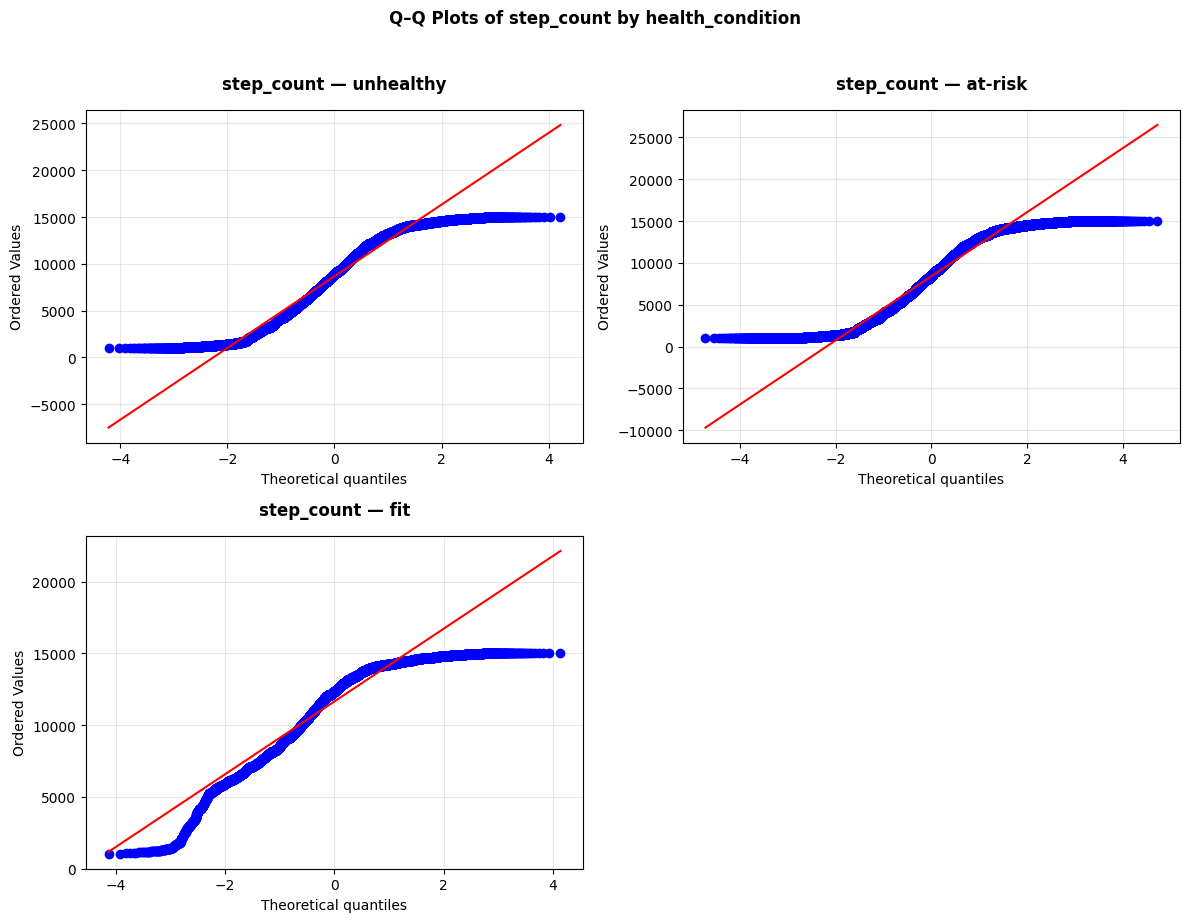

,Feature,Group,Skewness,Kurtosis,Remark
0,step_count,at-risk,-0.1219,-1.1289,"Approximately symmetric, Normal tails"
1,step_count,fit,-0.8291,-0.0407,"Moderately skewed, Normal tails"
2,step_count,unhealthy,-0.1966,-1.1055,"Approximately symmetric, Normal tails"


2026-07-04 01:04:35 | WARNING  | Normality assumption violated in at least one group.
2026-07-04 01:04:35 | INFO     | Recommendation: Use non-parametric tests (Kruskal–Wallis / Mann–Whitney U).
2026-07-04 01:04:35 | INFO     | Kruskal-Wallis Test: step_count ~ health_condition...
2026-07-04 01:04:35 | DEBUG    | Number of groups detected: 3
2026-07-04 01:04:36 | INFO     | Kruskal-Wallis H-statistic: 25904.553
2026-07-04 01:04:36 | INFO     | p-value: 0.0
2026-07-04 01:04:36 | INFO     | Significant difference detected among groups (p < 0.05).
2026-07-04 01:04:36 | DEBUG    | Running Dunn's Post-Hoc Test (Bonferroni corrected)...
                at-risk  fit     unhealthy
at-risk    1.000000e+00  0.0  9.209792e-51
fit        0.000000e+00  1.0  0.000000e+00
unhealthy  9.209792e-51  0.0  1.000000e+00


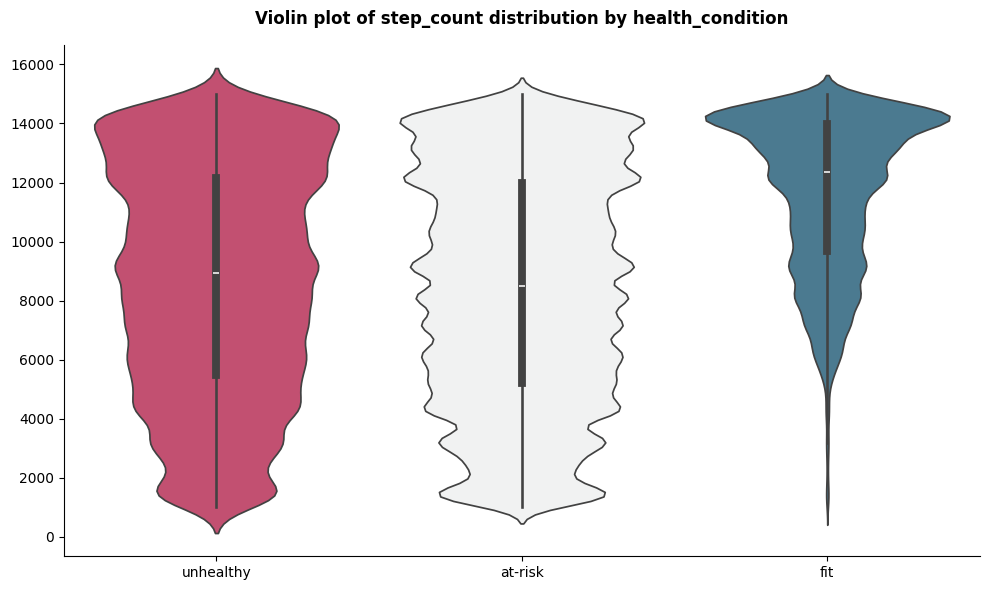

,health_condition,Count,Mean,Median,Std
0,fit,39386,50.042381,50.500000,10.541754
1,unhealthy,57112,39.044281,39.700001,14.693088
2,at-risk,586689,37.964958,38.599998,14.677118


2026-07-04 01:04:38 | INFO     | Checking normality of feature 'exercise_duration' by groups of 'health_condition'...
2026-07-04 01:04:38 | INFO     | Evaluating distribution characteristics (skewness & kurtosis)...
2026-07-04 01:04:38 | DEBUG    | Number of groups detected: 3
2026-07-04 01:04:38 | DEBUG    | Thresholds → |skew|≤0.5, |kurtosis|≤1.5
2026-07-04 01:04:39 | DEBUG    | [health_condition=at-risk] skew=-0.3537, kurtosis=0.0243 → Approximately symmetric, Normal tails
2026-07-04 01:04:39 | DEBUG    | [health_condition=fit] skew=-0.2573, kurtosis=0.0854 → Approximately symmetric, Normal tails
2026-07-04 01:04:39 | DEBUG    | [health_condition=unhealthy] skew=-0.3825, kurtosis=0.0725 → Approximately symmetric, Normal tails
2026-07-04 01:04:39 | INFO     | Generating Q–Q plots for visual assessment...


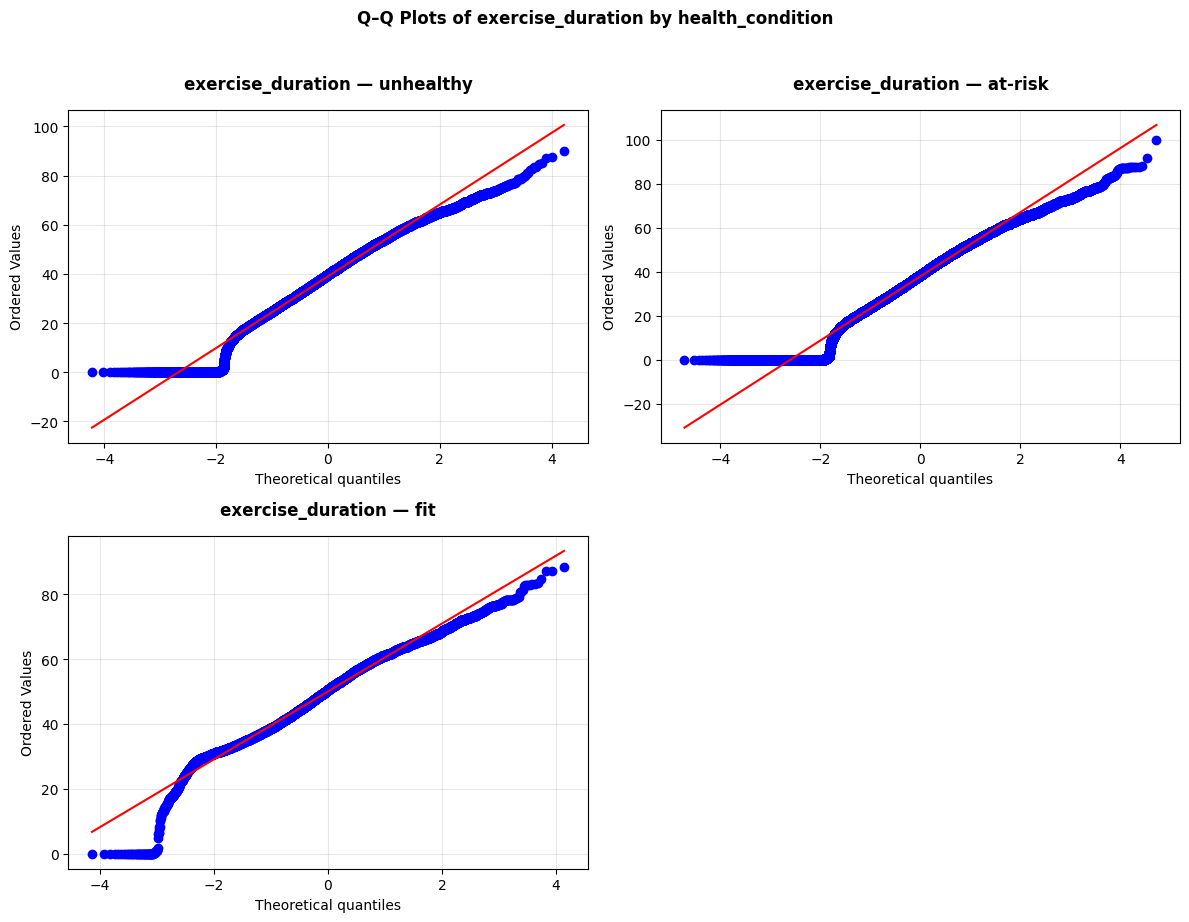

,Feature,Group,Skewness,Kurtosis,Remark
0,exercise_duration,at-risk,-0.3537,0.0243,"Approximately symmetric, Normal tails"
1,exercise_duration,fit,-0.2573,0.0854,"Approximately symmetric, Normal tails"
2,exercise_duration,unhealthy,-0.3825,0.0725,"Approximately symmetric, Normal tails"


2026-07-04 01:04:40 | INFO     | All groups approximately follow a normal distribution.
2026-07-04 01:04:40 | INFO     | Check homogeneity of variances across groups using Levene’s test (median-centered)
2026-07-04 01:04:40 | DEBUG    | Number of groups detected: 3


,Metric,Value
0,Levene’s Statistic,2294.1907
1,p-value,0.000000
2,Max/Min Variance Ratio,1.94


2026-07-04 01:04:40 | INFO     | Interpretation:
2026-07-04 01:04:40 | INFO     | - Status: Statistically different variances, but practical difference is small.
2026-07-04 01:04:40 | INFO     | - Recommendation: ANOVA or T-Test are acceptable, but Welch’s ANOVA or Welch’s T-Test is recommended.
2026-07-04 01:04:40 | INFO     | Running Welch’s ANOVA Test: exercise_duration ~ health_condition
2026-07-04 01:04:40 | DEBUG    | Number of groups detected: 3
2026-07-04 01:04:40 | INFO     | Assessing mean differences under heteroscedastic conditions...
2026-07-04 01:04:41 | INFO     | Welch ANOVA F-statistic: 22884.6812
2026-07-04 01:04:41 | INFO     | p-value: 0.000000
2026-07-04 01:04:41 | DEBUG    | Welch ANOVA table:
             Source  ddof1         ddof2             F  p-unc       np2
0  health_condition      2  75758.242065  22884.681215    0.0  0.036294
2026-07-04 01:04:41 | INFO     | Result: p-value < 0.05 → Reject H0
2026-07-04 01:04:41 | INFO     | Conclusion: Significant mean d

,A,B,mean(A),mean(B),diff,se,T,df,pval,hedges
0,at-risk,fit,37.9650,50.0424,-12.0774,0.0565,-213.8836,50241.2949,0.0000,-0.8357
1,at-risk,unhealthy,37.9650,39.0443,-1.0793,0.0644,-16.7601,68677.1601,0.0000,-0.0735
2,fit,unhealthy,50.0424,39.0443,10.9981,0.0813,135.3609,96348.2523,0.0000,0.8359


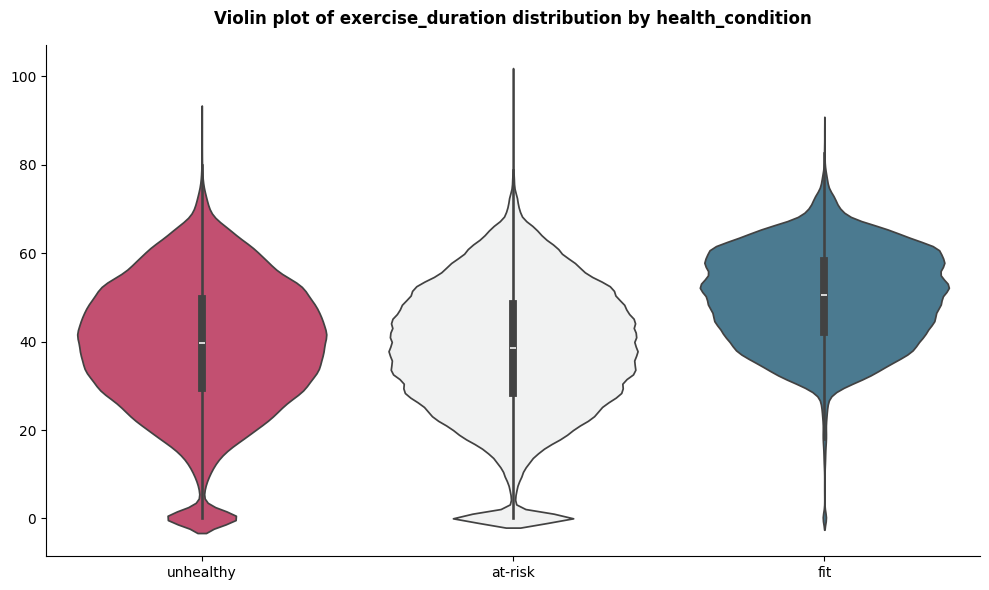

,health_condition,Count,Mean,Median,Std
0,at-risk,555384,2.189130,2.180000,0.517423
1,unhealthy,53948,2.188961,2.180000,0.520977
2,fit,37279,2.179176,2.140000,0.530531


2026-07-04 01:04:44 | INFO     | Checking normality of feature 'water_intake' by groups of 'health_condition'...
2026-07-04 01:04:44 | INFO     | Evaluating distribution characteristics (skewness & kurtosis)...
2026-07-04 01:04:44 | DEBUG    | Number of groups detected: 3
2026-07-04 01:04:44 | DEBUG    | Thresholds → |skew|≤0.5, |kurtosis|≤1.5
2026-07-04 01:04:44 | DEBUG    | [health_condition=at-risk] skew=0.1011, kurtosis=0.5059 → Approximately symmetric, Normal tails
2026-07-04 01:04:44 | DEBUG    | [health_condition=fit] skew=0.1962, kurtosis=0.3066 → Approximately symmetric, Normal tails
2026-07-04 01:04:44 | DEBUG    | [health_condition=unhealthy] skew=0.1385, kurtosis=0.5162 → Approximately symmetric, Normal tails
2026-07-04 01:04:44 | INFO     | Generating Q–Q plots for visual assessment...


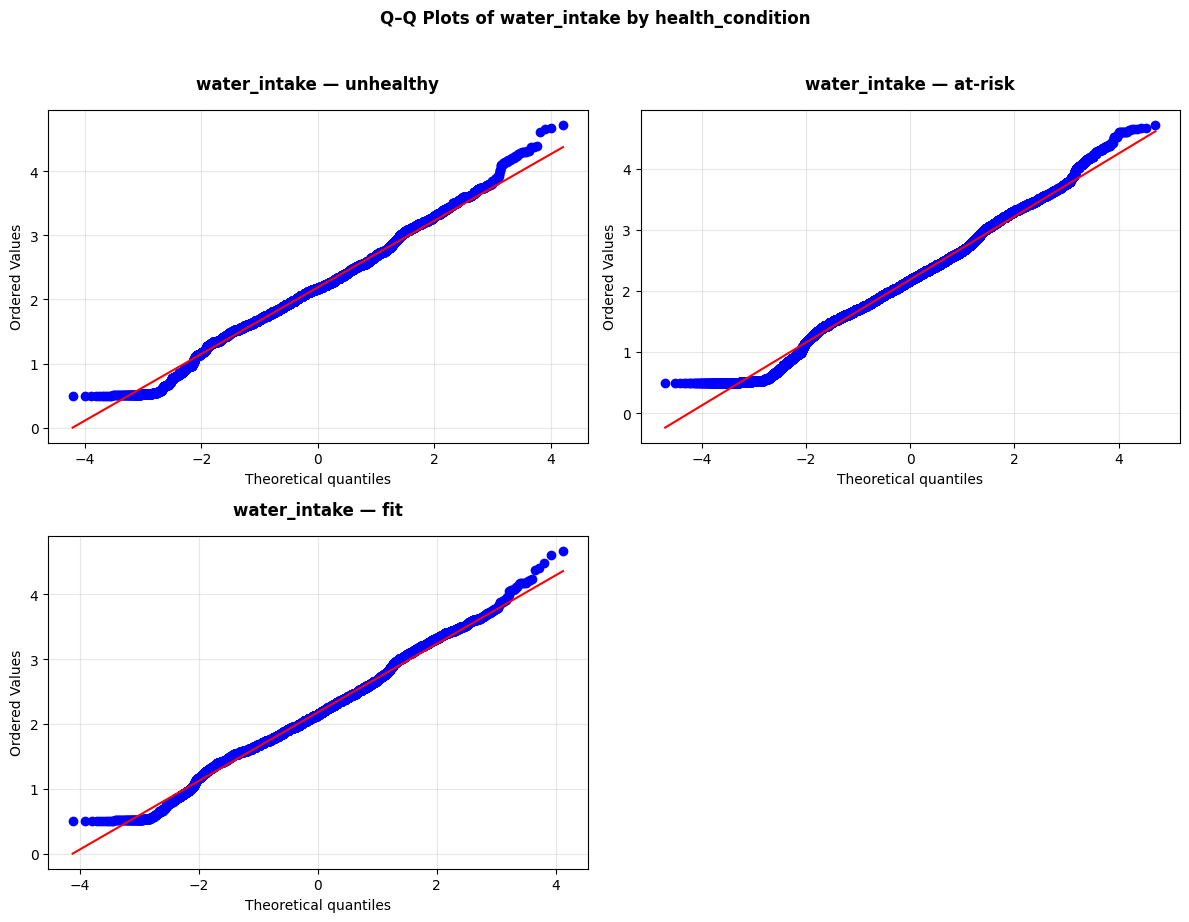

,Feature,Group,Skewness,Kurtosis,Remark
0,water_intake,at-risk,0.1011,0.5059,"Approximately symmetric, Normal tails"
1,water_intake,fit,0.1962,0.3066,"Approximately symmetric, Normal tails"
2,water_intake,unhealthy,0.1385,0.5162,"Approximately symmetric, Normal tails"


2026-07-04 01:04:45 | INFO     | All groups approximately follow a normal distribution.
2026-07-04 01:04:46 | INFO     | Check homogeneity of variances across groups using Levene’s test (median-centered)
2026-07-04 01:04:46 | DEBUG    | Number of groups detected: 3


,Metric,Value
0,Levene’s Statistic,32.8943
1,p-value,0.000000
2,Max/Min Variance Ratio,1.05


2026-07-04 01:04:46 | INFO     | Interpretation:
2026-07-04 01:04:46 | INFO     | - Status: Statistically different variances, but practical difference is small.
2026-07-04 01:04:46 | INFO     | - Recommendation: ANOVA or T-Test are acceptable, but Welch’s ANOVA or Welch’s T-Test is recommended.
2026-07-04 01:04:46 | INFO     | Running Welch’s ANOVA Test: water_intake ~ health_condition
2026-07-04 01:04:46 | DEBUG    | Number of groups detected: 3
2026-07-04 01:04:46 | INFO     | Assessing mean differences under heteroscedastic conditions...
2026-07-04 01:04:46 | INFO     | Welch ANOVA F-statistic: 6.1848
2026-07-04 01:04:46 | INFO     | p-value: 0.002062
2026-07-04 01:04:46 | DEBUG    | Welch ANOVA table:
             Source  ddof1         ddof2        F     p-unc      np2
0  health_condition      2  67362.347243  6.18476  0.002062  0.00002
2026-07-04 01:04:46 | INFO     | Result: p-value < 0.05 → Reject H0
2026-07-04 01:04:46 | INFO     | Conclusion: Significant mean differences dete

,A,B,mean(A),mean(B),diff,se,T,df,pval,hedges
0,at-risk,fit,2.1891,2.1792,0.0100,0.0028,3.5123,42178.9170,0.0013,0.0192
1,at-risk,unhealthy,2.1891,2.1890,0.0002,0.0023,0.0719,64723.1494,0.9972,0.0003
2,fit,unhealthy,2.1792,2.1890,-0.0098,0.0035,-2.7588,79207.9715,0.0160,-0.0186


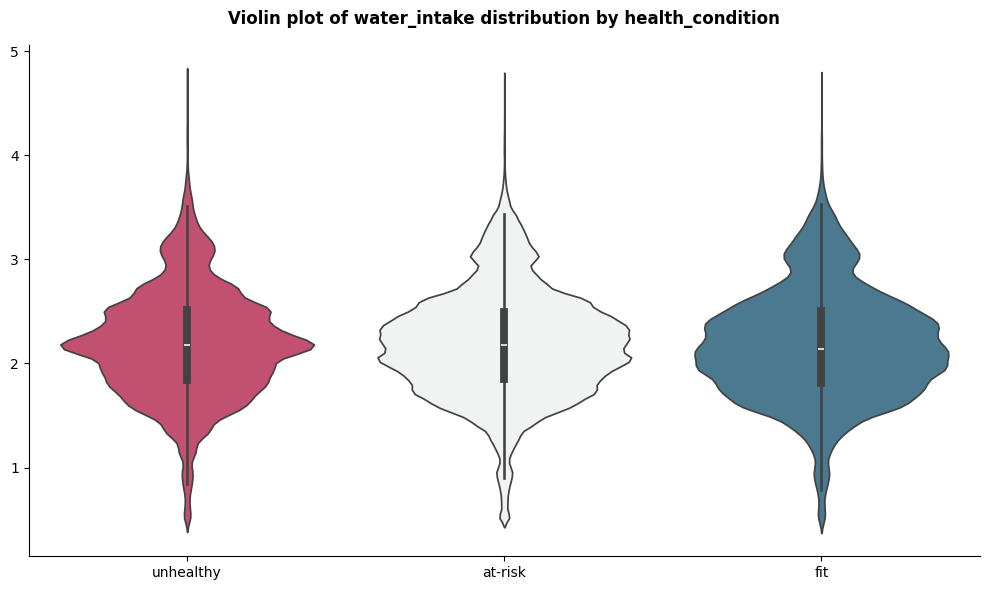

In [19]:
def perform_statical_testing(feature: str, df: pd.DataFrame = df_train, 
                             target_feature: str = CFG.TARGET_FEATURE) -> None:
    """
    Automatically select and perform appropriate statistical tests
    for comparing a numerical feature across categorical groups.

    This function implements a decision-based statistical testing pipeline
    that selects parametric or non-parametric tests based on:

    - Distribution normality (via skewness, kurtosis, and Q–Q plots)
    - Homogeneity of variances
    - Number of categorical groups

    The procedure follows standard statistical analysis guidelines:

    1. Check normality of the numerical feature within each group.
    2. Determine the number of comparison groups.
    3. Evaluate homogeneity of variance when parametric tests are applicable.
    4. Select and execute the most appropriate hypothesis test.

    Decision Logic
    --------------
    For more than two groups:

    - Non-normal distribution → Kruskal–Wallis test
    - Normal + equal variances → One-way ANOVA + Tukey HSD
    - Normal + unequal variances → Welch’s ANOVA
    - Otherwise → Kruskal–Wallis test

    For two groups:

    - Non-normal distribution → Mann–Whitney U test
    - Normal + equal variances → Independent t-test (with Cohen’s d)
    - Normal + unequal variances → Welch’s t-test (with Cohen’s d)
    - Otherwise → Mann–Whitney U test

    The function also reports effect sizes and post-hoc comparisons
    where applicable.

    Parameters
    ----------
    feature : str
        Name of the numerical feature to be analyzed.

    df : pandas.DataFrame, default=df_train
        Dataset containing the numerical feature and categorical target.

    target_feature : str, default=config.target_feature
        Categorical variable defining comparison groups.

    Returns
    -------
    None
        Executes statistical tests and logs/prints results.
        No value is returned.

    Notes
    -----
    - This function is designed for exploratory and confirmatory
      statistical analysis in machine learning and research workflows.
    - Assumption checks (normality and homoscedasticity) are performed
      automatically prior to testing.
    - For small sample sizes, non-parametric tests are generally preferred.

    Examples
    --------
    >>> perform_statical_testing(
    ...     feature="cholesterol",
    ...     df=df_train,
    ...     target_feature="heart_disease"
    ... )
    """

    # Step 1: Check normality of the feature in each group
    non_normal_detected = check_normality_with_plots(df=df, feature=feature, target_feature=target_feature)
    # Count number of categories in target feature
    total_categories = df[target_feature].nunique()
    # Case 1: More than two groups (Multi-class comparison)
    if total_categories > 2:
        # If data is not normally distributed → use Kruskal–Wallis
        if non_normal_detected:
            perform_kruskal_test(df=df, categorical_feature=target_feature,
                                numeric_feature=feature)
        # If data is approximately normal → check variance homogeneity
        else:
            anove_use, is_homogeneous_variances = check_homogeneity_of_variance(df=df, feature=feature,
                                                                                target_feature=target_feature)
            # Normal + equal variance → One-way ANOVA + Tukey test
            if anove_use and is_homogeneous_variances:
                perform_anova_with_tukey(df=df, numeric_feature=feature,
                                        categorical_feature=target_feature)
            # Normal + unequal variance → Welch ANOVA
            elif anove_use and is_homogeneous_variances == False:
                perform_welch_anova(df=df, numeric_feature=feature, categorical_feature=target_feature)
            # Otherwise → fallback to Kruskal–Wallis
            else:
                perform_kruskal_test(df=df, categorical_feature=target_feature,
                        numeric_feature=feature)
    # Case 2: Two groups (Binary comparison)
    else:
        # If data is not normal → use Mann–Whitney U test
        if non_normal_detected:
            cal_mannwhitneyu(dataframe=df, categorical_feature=target_feature, num_feature=feature)
        # If data is approximately normal → check variance homogeneity
        else:
            anove_use, is_homogeneous_variances = check_homogeneity_of_variance(df=df, feature=feature,
                                                                                target_feature=target_feature)
            # Normal + equal variance → Independent t-test + Cohen's d
            if anove_use and is_homogeneous_variances:
                t_test_with_cohens_d(data=df, categorical_feature=target_feature, num_feature=feature, equal_var=True)
            # Normal + unequal variance → Welch t-test + Cohen's d
            elif anove_use and is_homogeneous_variances == False:
                t_test_with_cohens_d(data=df, categorical_feature=target_feature, num_feature=feature, equal_var=False)
            # Otherwise → fallback to Mann–Whitney U
            else:
                cal_mannwhitneyu(dataframe=df, categorical_feature=target_feature, num_feature=feature)

def plot_numerical_distribution(feature: str, df: pd.DataFrame = df_train,
                                target_feature: str = CFG.TARGET_FEATURE, order: list = None) -> None:
    """
    Analyze and visualize the distribution of a numerical feature
    across categories of a target variable.

    This function performs:
    - Descriptive statistics (mean, median, std) by group
    - Overall summary statistics
    - Automated statistical hypothesis testing
    - Violin plot visualization

    Parameters
    ----------
    feature : str
        Numerical feature to be analyzed.

    df : pandas.DataFrame
        Input dataset containing the feature and target variable.

    target_feature : str
        Categorical variable used for grouping.

    order : list, optional
        Custom order of categories for plotting.

    Returns
    -------
    None
        Displays summary tables, test results, and plots.
    """

    # Compute summary statistics for each Fertilizer category
    df_summary_feature = (
        df.groupby(by=target_feature, as_index=False)
        .agg(
            Count=(feature, "count"),
            Mean=(feature, "mean"),
            Median=(feature, "median"),
            Std=(feature, "std")
        )
        .sort_values(by="Mean", ascending=False).reset_index(drop=True)
    )

    # Compute global statistics for the entire feature
    summary_data = [
        ("Overall Mean", f"{df[feature].mean():.2f}"),
        ("Overall Median", f"{df[feature].median()}"),
        ("Overall Std", f"{df[feature].std():.2f}")
    ]

    # Display overall statistics in HTML format for better notebook visualization
    summary_html = "<ul>" + "".join([
        f"<li><b>{k}:</b> {v}</li>" for k, v in summary_data
    ]) + "</ul>"
    display(HTML(summary_html))

    # Display detailed summary per category as styled dataframe
    display(
        df_summary_feature.style.background_gradient(cmap=cm)
        .set_table_attributes('style="width:75%; margin:auto;"')
    )

    # Run statistical significance testing
    perform_statical_testing(feature=feature, target_feature=target_feature)

    # Visualize distribution via violin plot
    plt.figure(figsize=(10, 6))
    sns.violinplot(x=target_feature, y=feature, data=df, hue=target_feature, order=order,
                   palette=color(n_colors=df[target_feature].nunique()))

    plt.title(f"Violin plot of {feature} distribution by {target_feature}", pad=15, weight="bold", fontsize=12)
    plt.xlabel("")
    plt.ylabel("")
    plt.legend().remove()
    sns.despine(left=False, bottom=False)
    plt.tight_layout()
    plt.show()

for feature in num_features:
    display(HTML(f"<h2 style='text-align:center; font-size:22px; color:blue;'><b>Distribution of {feature} by Health Condition</b></h2>"))
    plot_numerical_distribution(feature=feature, df = df_train)

<div style="
    background: linear-gradient(135deg, #1f2a44, #2c3e50);
    color: #ecf0f1;
    padding: 25px;
    border-radius: 12px;
    margin: 25px 0;
    box-shadow: 0 6px 18px rgba(0,0,0,0.25);
">

<div style="
    color:#f9e79f;
    margin: 0 0 20px 0;
    font-size: 22px;
    font-weight: 600;
    letter-spacing: 0.5px;
">
🏥 Numerical Feature Impact by Health Condition
</div>

<ul style="line-height:1.8; padding-left:20px;">

<li><code>sleep_duration</code>: Significantly associated with health condition (p &lt; 0.05), with <b>fit students sleeping the longest</b> and <b>unhealthy students the shortest</b>.</li>

<li><code>heart_rate</code>: Shows statistically significant differences across health conditions, but the <b>effect size is negligible</b>.</li>

<li><code>bmi</code>: Differs significantly across health conditions (Kruskal–Wallis, p &lt; 0.05), with <b>unhealthy individuals having the highest BMI</b> and <b>fit individuals the lowest</b>.</li>

<li><code>calorie_expenditure</code>: Differs significantly across health conditions (Welch's ANOVA, p &lt; 0.05), with <b>fit individuals showing the highest average calorie expenditure</b>.</li>

<li><code>step_count</code>: Differs significantly across health conditions (Kruskal–Wallis, p &lt; 0.05), with <b>fit individuals recording the highest daily step count</b>.</li>

<li><code>exercise_duration</code>: Differs significantly across health conditions (Welch's ANOVA, p &lt; 0.05), with <b>fit individuals exercising substantially longer</b> than at-risk and unhealthy groups.</li>

<li><code>water_intake</code>: Statistically differs across health conditions (p &lt; 0.05), but the differences are <b>negligible in practical terms</b>.</li>

</ul>

<div style="
    margin-top: 18px;
    padding: 12px 16px;
    background-color: rgba(249, 231, 159, 0.15);
    border-left: 4px solid #f9e79f;
    border-radius: 6px;
    font-size: 15px;
">
<b>Key Insight:</b> Lifestyle and activity-related features such as 
<code>sleep_duration</code>, <code>bmi</code>, <code>calorie_expenditure</code>, 
<code>step_count</code>, and <code>exercise_duration</code> show the clearest separation across health conditions, while 
<code>heart_rate</code> and <code>water_intake</code> have limited practical impact.
</div>

</div>

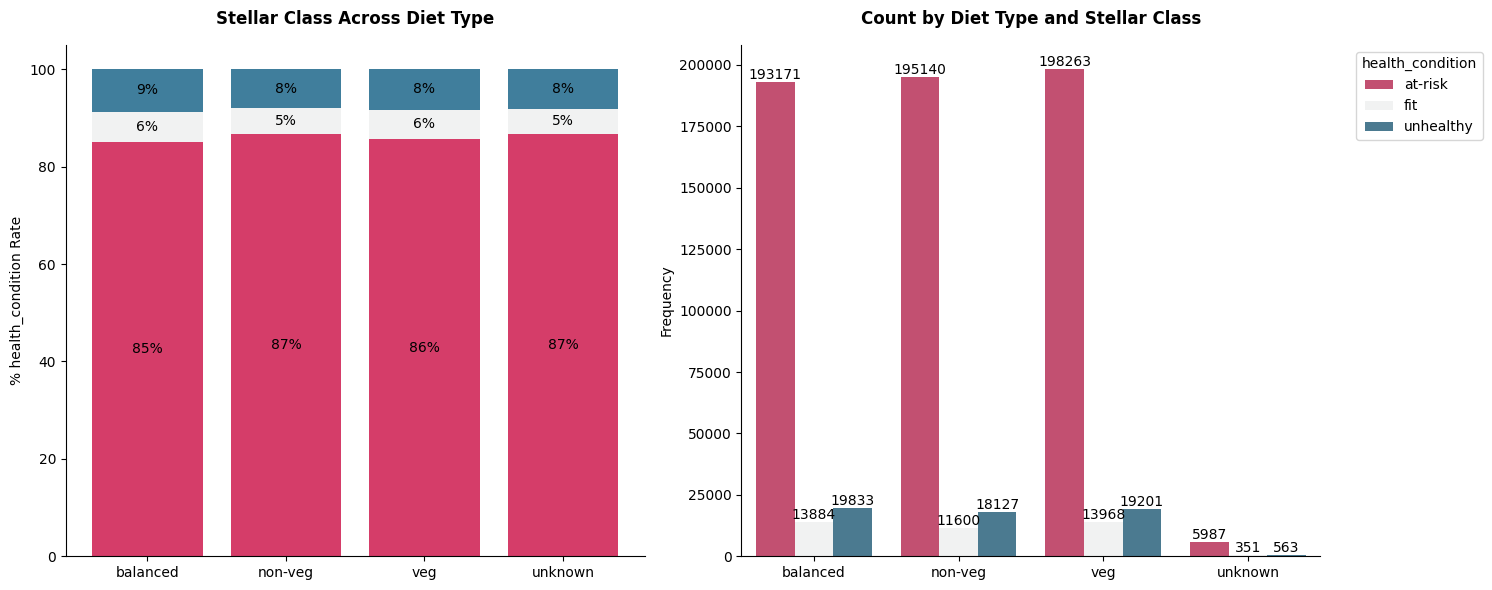

2026-07-04 01:04:50 | INFO     | Chi-Square Test of Independence: 'diet_type' vs. 'health_condition'...
2026-07-04 01:04:50 | INFO     | Chi-squared statistic: 329.998
2026-07-04 01:04:50 | INFO     | Degrees of freedom: 6
2026-07-04 01:04:50 | INFO     | p-value: 0.000000
2026-07-04 01:04:50 | INFO     | Result: p-value < 0.05 → Reject H₀
2026-07-04 01:04:50 | INFO     | Variables 'diet_type' and 'health_condition' are statistically associated.
2026-07-04 01:04:50 | DEBUG    | Displaying standardized residuals heatmap.


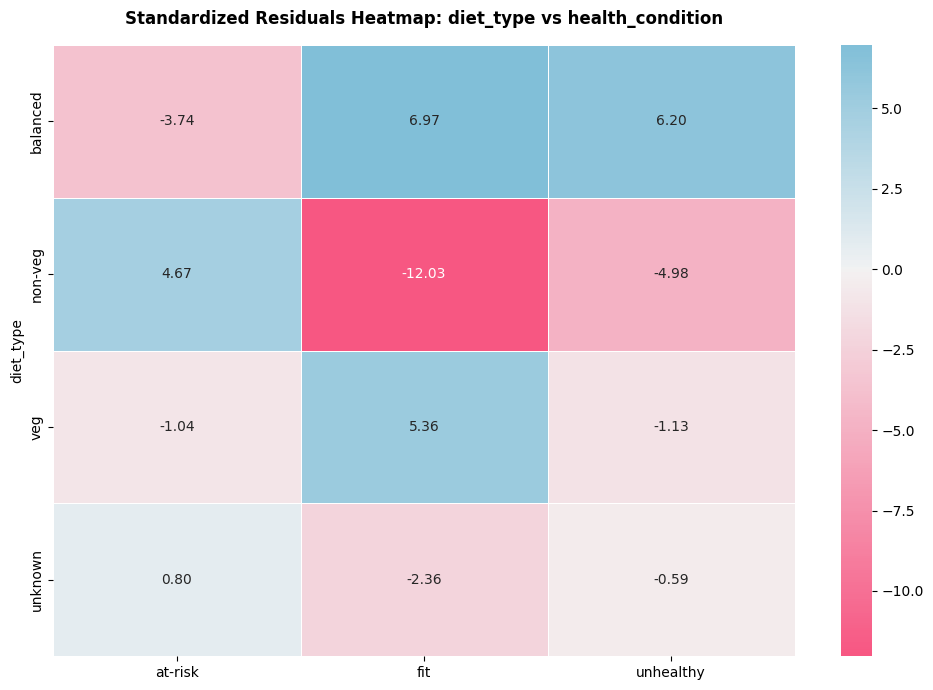

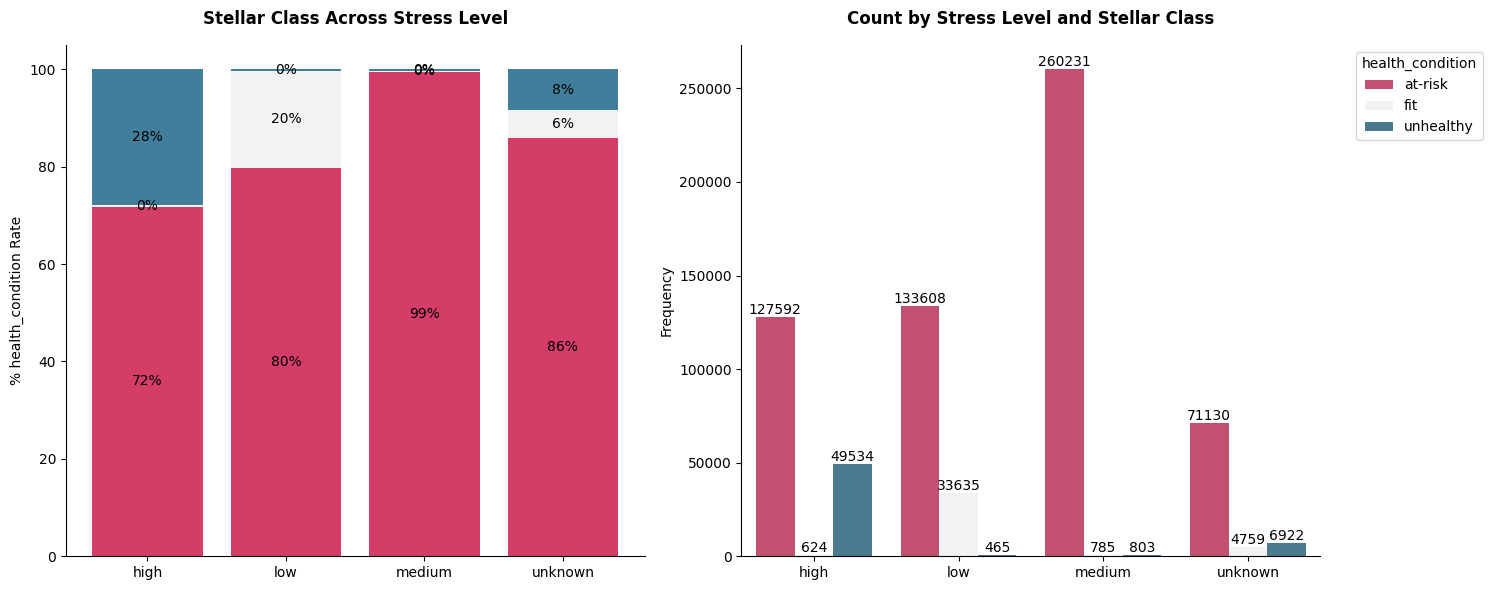

2026-07-04 01:04:52 | INFO     | Chi-Square Test of Independence: 'stress_level' vs. 'health_condition'...
2026-07-04 01:04:52 | INFO     | Chi-squared statistic: 206669.884
2026-07-04 01:04:52 | INFO     | Degrees of freedom: 6
2026-07-04 01:04:52 | INFO     | p-value: 0.000000
2026-07-04 01:04:52 | INFO     | Result: p-value < 0.05 → Reject H₀
2026-07-04 01:04:52 | INFO     | Variables 'stress_level' and 'health_condition' are statistically associated.
2026-07-04 01:04:52 | DEBUG    | Displaying standardized residuals heatmap.


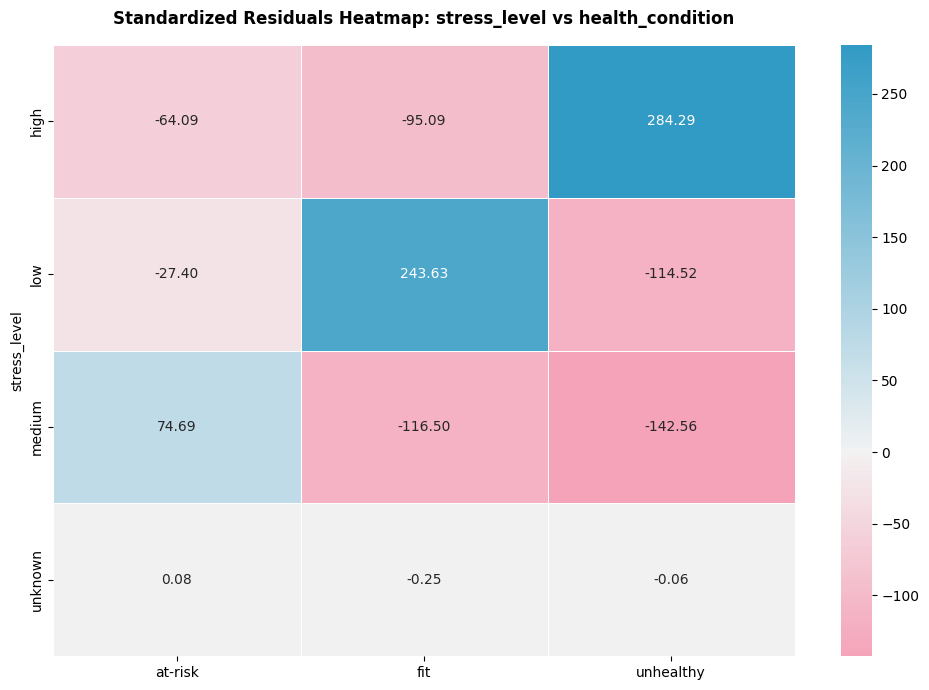

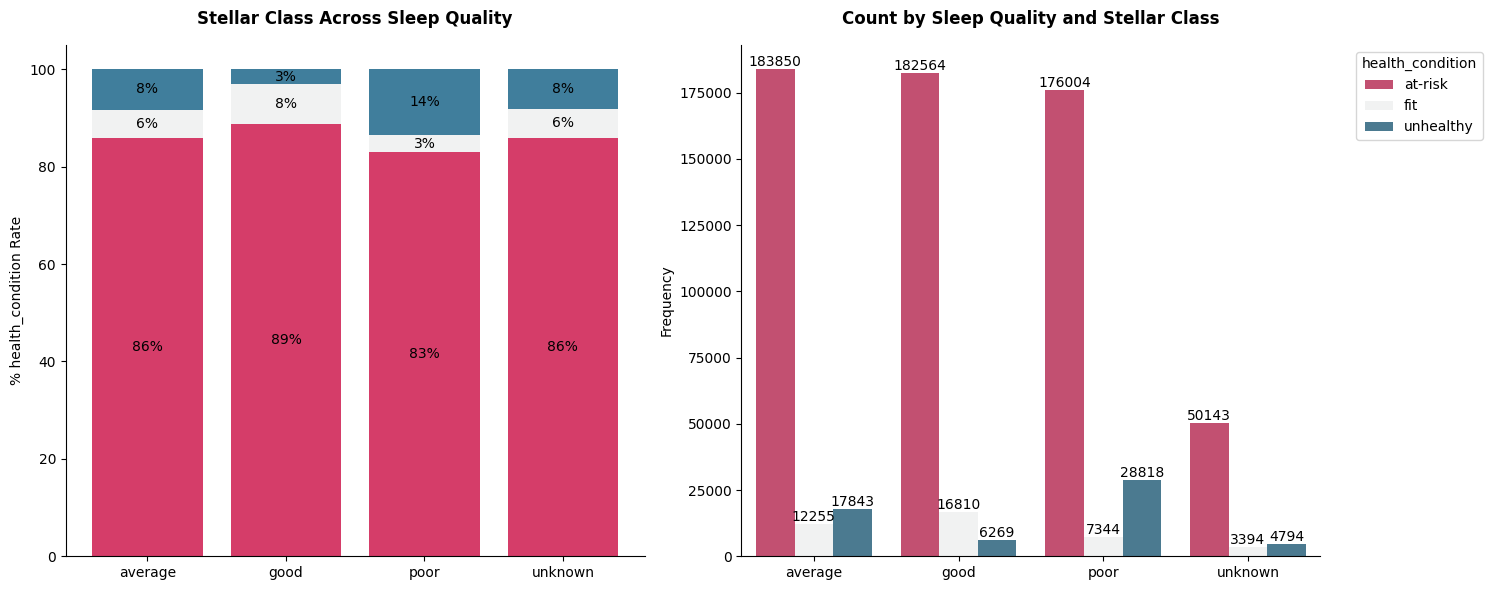

2026-07-04 01:04:53 | INFO     | Chi-Square Test of Independence: 'sleep_quality' vs. 'health_condition'...
2026-07-04 01:04:54 | INFO     | Chi-squared statistic: 18290.809
2026-07-04 01:04:54 | INFO     | Degrees of freedom: 6
2026-07-04 01:04:54 | INFO     | p-value: 0.000000
2026-07-04 01:04:54 | INFO     | Result: p-value < 0.05 → Reject H₀
2026-07-04 01:04:54 | INFO     | Variables 'sleep_quality' and 'health_condition' are statistically associated.
2026-07-04 01:04:54 | DEBUG    | Displaying standardized residuals heatmap.


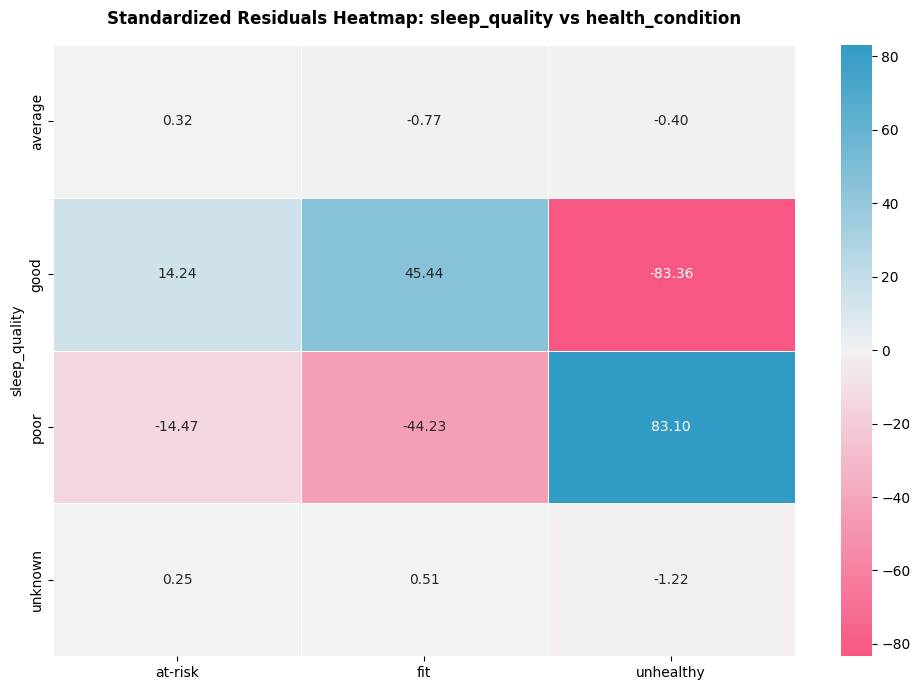

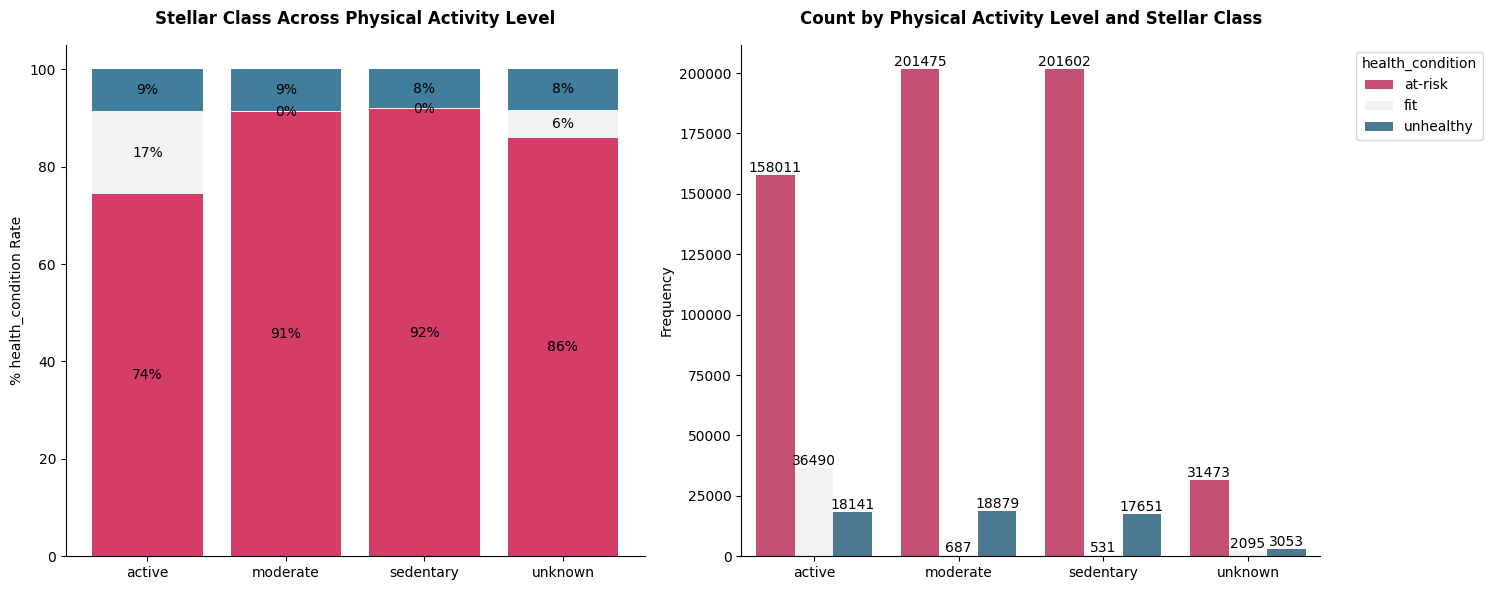

2026-07-04 01:04:55 | INFO     | Chi-Square Test of Independence: 'physical_activity_level' vs. 'health_condition'...
2026-07-04 01:04:55 | INFO     | Chi-squared statistic: 75848.612
2026-07-04 01:04:55 | INFO     | Degrees of freedom: 6
2026-07-04 01:04:55 | INFO     | p-value: 0.000000
2026-07-04 01:04:55 | INFO     | Result: p-value < 0.05 → Reject H₀
2026-07-04 01:04:55 | INFO     | Variables 'physical_activity_level' and 'health_condition' are statistically associated.
2026-07-04 01:04:55 | DEBUG    | Displaying standardized residuals heatmap.


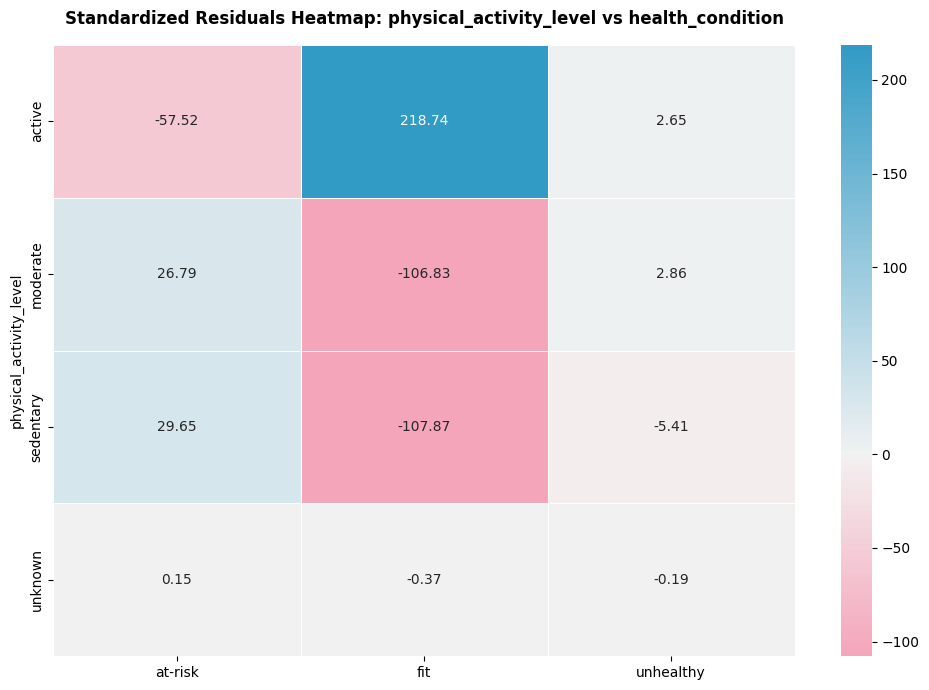

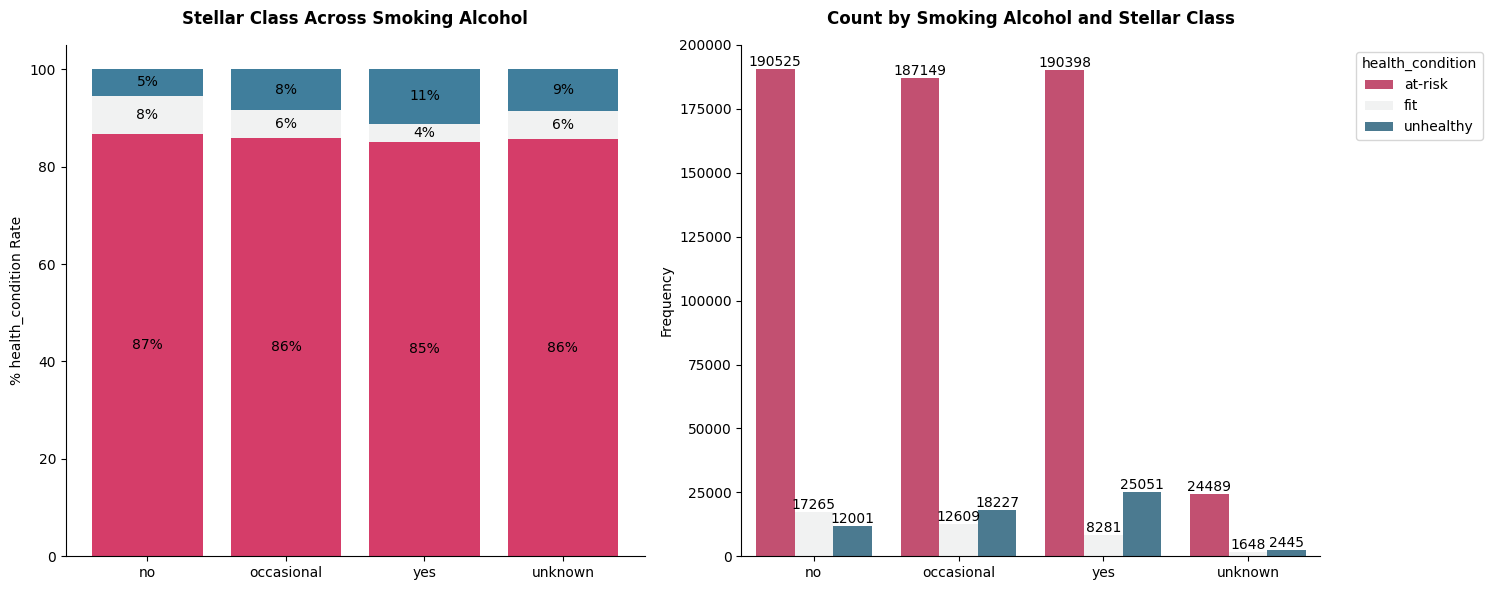

2026-07-04 01:04:57 | INFO     | Chi-Square Test of Independence: 'smoking_alcohol' vs. 'health_condition'...
2026-07-04 01:04:57 | INFO     | Chi-squared statistic: 7712.878
2026-07-04 01:04:57 | INFO     | Degrees of freedom: 6
2026-07-04 01:04:57 | INFO     | p-value: 0.000000
2026-07-04 01:04:57 | INFO     | Result: p-value < 0.05 → Reject H₀
2026-07-04 01:04:57 | INFO     | Variables 'smoking_alcohol' and 'health_condition' are statistically associated.
2026-07-04 01:04:57 | DEBUG    | Displaying standardized residuals heatmap.


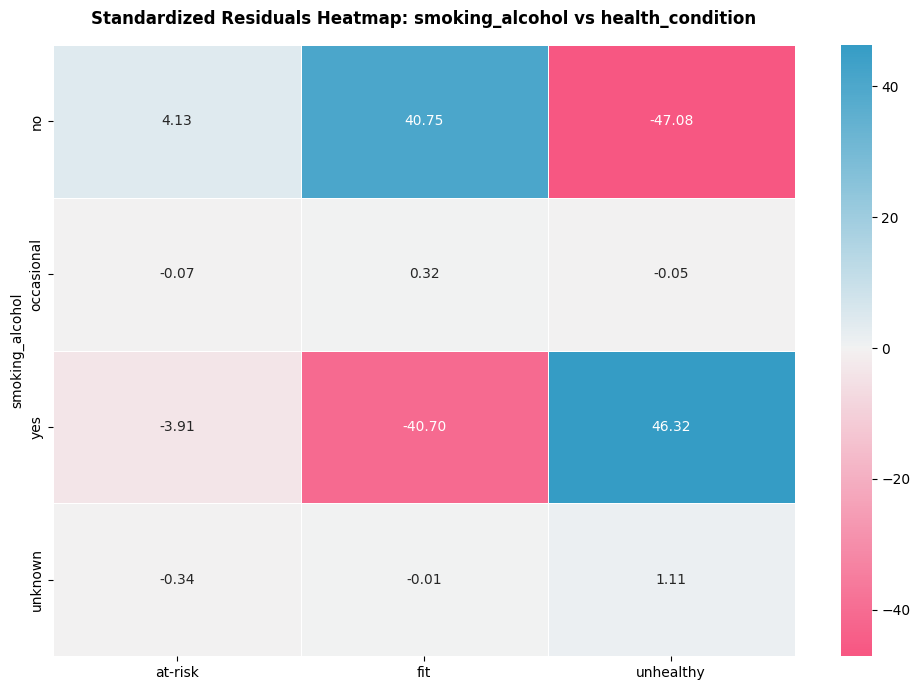

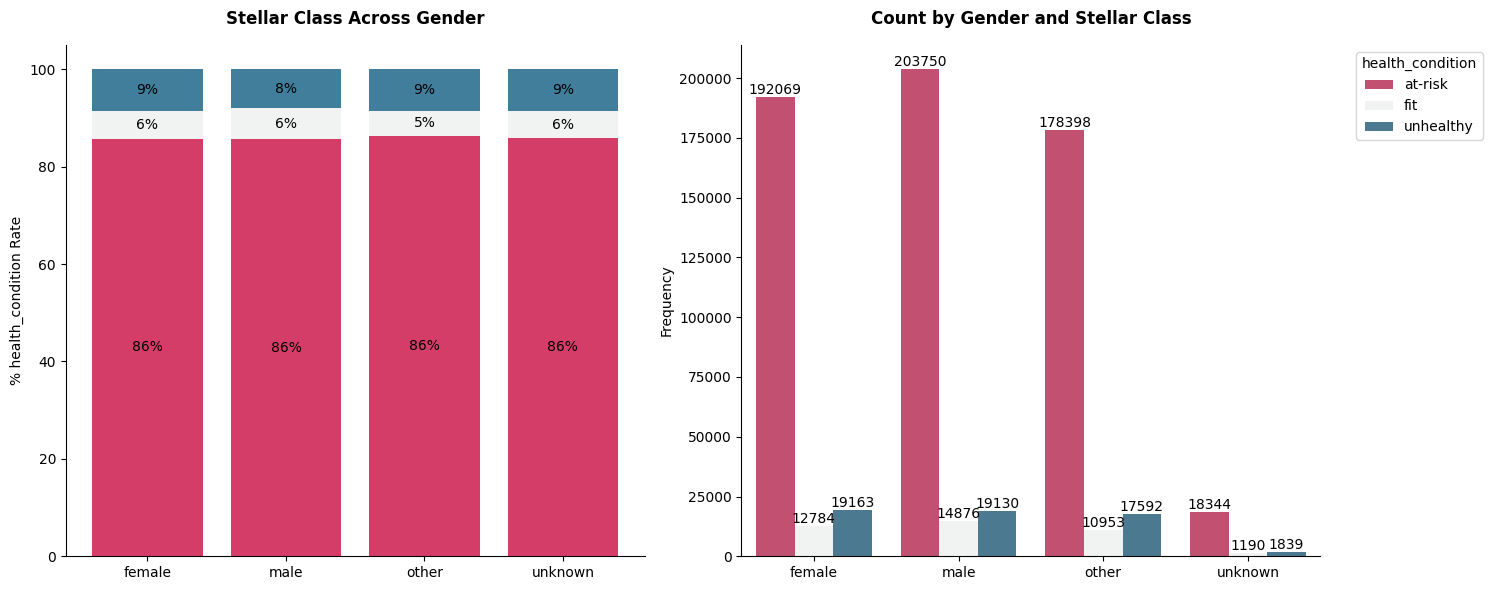

2026-07-04 01:04:58 | INFO     | Chi-Square Test of Independence: 'gender' vs. 'health_condition'...
2026-07-04 01:04:58 | INFO     | Chi-squared statistic: 231.025
2026-07-04 01:04:58 | INFO     | Degrees of freedom: 6
2026-07-04 01:04:58 | INFO     | p-value: 0.000000
2026-07-04 01:04:58 | INFO     | Result: p-value < 0.05 → Reject H₀
2026-07-04 01:04:58 | INFO     | Variables 'gender' and 'health_condition' are statistically associated.
2026-07-04 01:04:58 | DEBUG    | Displaying standardized residuals heatmap.


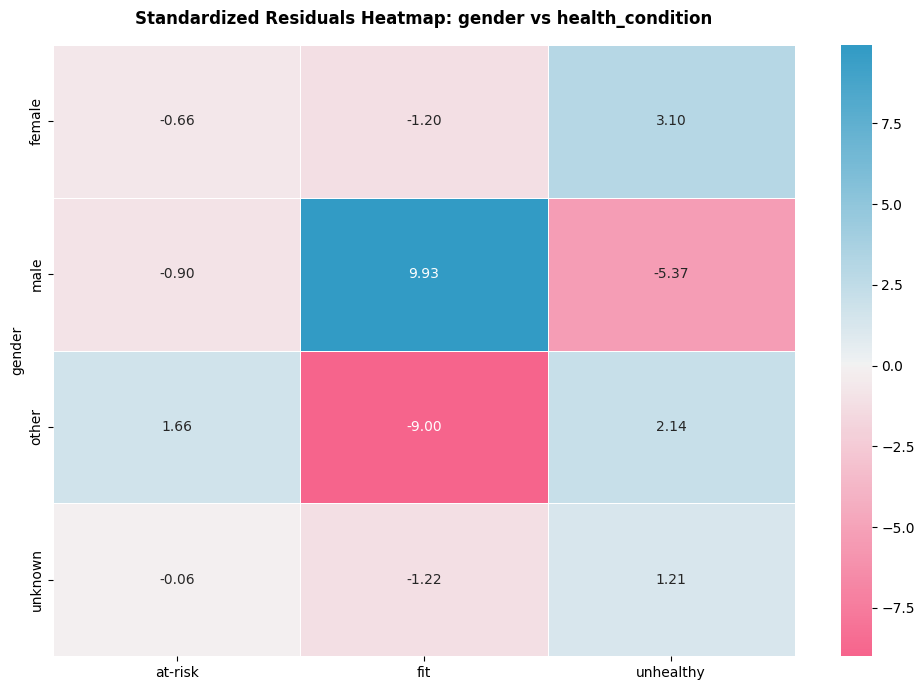

In [20]:
def bivariate_percent_plot(cat: str, target_feature: str,
                           df: pd.DataFrame, figsize=(15, 6), order=None) -> None:
    """
    Plot the relationship between a categorical feature and the target variable.

    This function displays:
    - A stacked bar chart showing percentage distribution of target classes.
    - A count plot showing absolute frequencies.
    - A Chi-Square test for feature–target dependence.

    Parameters
    ----------
    cat : str
        Categorical feature name.

    target_feature : str
        Target variable name.

    df : pd.DataFrame
        Input dataset.

    figsize : tuple, optional
        Figure size (width, height). Default is (15, 6).

    order : list, optional
        Custom order of categories on x-axis.

    Returns
    -------
    None
    """

    display(HTML(f"<h2 style='text-align:center; font-size:22px; color:blue;'><b>Distribution of {cat.title()} by {target_feature.title()}</b></h2>"))
    fig, ax = plt.subplots(nrows=1, ncols=2, sharey=False, figsize=figsize)

    # Data processing
    grouped = df.groupby([cat, target_feature]).size().unstack(fill_value=0)

    # Define a fixed hue order (adjust if needed)
    target_order = [c for c in ["Yes", "No"] if c in grouped.columns]

    # Fallback if the labels are 0/1 or have different names
    if not target_order:
        target_order = list(grouped.columns)

    # Calculate percentages row-wise and reorder columns by target_order
    percentages = grouped.div(grouped.sum(axis=1), axis=0)[target_order] * 100

    # Define X-axis category order
    if order is not None:
        percentages = percentages.loc[order]
        labels = order
    else:
        labels = percentages.index.tolist()

    # Consistent color palette for both charts
    base_colors = color(n_colors=len(target_order))
    color_map = dict(zip(target_order, base_colors))

    # Plot 1: Stacked bar chart (percentage)
    bottom = np.zeros(len(percentages))
    for cls in target_order:
        ax[0].bar(percentages.index.astype(str), percentages[cls].values, bottom=bottom,
                  label=cls, color=color_map[cls])
        bottom += percentages[cls].values

    # Add percentage labels
    for container in ax[0].containers:
        ax[0].bar_label(container, fmt="%1.0f%%", label_type="center",
                        fontsize=10, color="black")

    ax[0].set_title(f"Stellar Class Across {cat.replace('_', ' ').title()}", fontsize=12, weight="bold", pad=15)
    ax[0].set_xlabel("")
    ax[0].set_ylabel(f"% {target_feature} Rate", fontsize=10)
    sns.despine(left=False, bottom=False, ax=ax[0])
    ax[0].legend().remove()

    # Plot 2: Count plot (using same color_map + hue_order)
    sns.countplot(data=df, hue=target_feature, x=cat,
                  order=labels, hue_order=target_order,
                  palette=color_map, ax=ax[1])

    for container in ax[1].containers:
        ax[1].bar_label(container, fmt="%d", label_type="edge",
                        fontsize=10, color="black")

    ax[1].set_title(f"Count by {cat.replace('_', ' ').title()} and Stellar Class", fontsize=12, weight="bold", pad=15)
    ax[1].set_xlabel("")
    ax[1].set_ylabel("Frequency")
    ax[1].legend(title=target_feature, bbox_to_anchor=(1.05, 1), loc="upper left")
    sns.despine(left=False, bottom=False, ax=ax[1])
    plt.tight_layout()
    plt.show()

    # Chi-Square Test
    cal_ChiSquare(cat_feature=cat, target_feature=target_feature, df=df, show_residuals=True)

# Run for all categorical features
for feature in cat_features:
    bivariate_percent_plot(cat=feature, target_feature=CFG.TARGET_FEATURE, df=df_train)

<div style="
    background: linear-gradient(135deg, #1f2a44, #2c3e50);
    color: #ecf0f1;
    padding: 25px;
    border-radius: 12px;
    margin: 25px 0;
    box-shadow: 0 6px 18px rgba(0,0,0,0.25);
">

<div style="
    color:#f9e79f;
    margin: 0 0 20px 0;
    font-size: 22px;
    font-weight: 600;
    letter-spacing: 0.5px;
">
🏥 Categorical Feature Impact by Health Condition
</div>

<ul style="line-height:1.8; padding-left:20px;">

<li><code>diet_type</code>: Balanced and vegetarian diets are slightly associated with better health outcomes, while non-vegetarian diets are underrepresented in the fit group (p &lt; 0.05).</li>

<li><code>stress_level</code>: Strongly associated with health condition (Chi-square, p &lt; 0.05), with high stress linked to unhealthy status and low stress linked to fit status.</li>

<li><code>sleep_quality</code>: Strongly associated with health condition (Chi-square, p &lt; 0.05), with good sleep quality linked to fit status and poor sleep quality linked to unhealthy status.</li>

<li><code>physical_activity_level</code>: Strongly associated with health condition (Chi-square, p &lt; 0.05), with active individuals more likely to be fit, while moderate and sedentary individuals are more likely to be at-risk.</li>

<li><code>smoking_alcohol</code>: Significantly associated with health condition (Chi-square, p &lt; 0.05), with non-smokers/non-drinkers more likely to be fit and smokers/drinkers more likely to be unhealthy.</li>

<li><code>gender</code>: Shows a statistically significant but relatively weak association with health condition, suggesting it is less informative than lifestyle-related features.</li>

</ul>

<div style="
    margin-top: 18px;
    padding: 12px 16px;
    background-color: rgba(249, 231, 159, 0.15);
    border-left: 4px solid #f9e79f;
    border-radius: 6px;
    font-size: 15px;
">
<b>Key Insight:</b> Lifestyle-related categorical features such as 
<code>stress_level</code>, <code>sleep_quality</code>, 
<code>physical_activity_level</code>, and <code>smoking_alcohol</code> show clearer associations with health condition, while 
<code>gender</code> has weaker practical predictive value.
</div>

</div>

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Overall Picture</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Overall Picture
    </h1>
</div>

<div style="
    background: linear-gradient(135deg, #1f2a44, #2c3e50);
    color: #ecf0f1;
    padding: 25px;
    border-radius: 12px;
    margin: 25px 0;
    box-shadow: 0 6px 18px rgba(0,0,0,0.25);
">

<div style="
    color:#f9e79f;
    margin:0 0 20px 0;
    font-size:22px;
    font-weight:600;
    letter-spacing:0.5px;
">
📊 Key Health Drivers Identified from EDA
</div>

<table style="
    width:100%;
    border-collapse:collapse;
    font-size:14px;
">

<thead>
<tr style="background-color:rgba(249,231,159,0.15);">
<th style="padding:10px;border:1px solid rgba(255,255,255,0.2);text-align:left;">Feature</th>
<th style="padding:10px;border:1px solid rgba(255,255,255,0.2);text-align:left;">Summary</th>
</tr>
</thead>

<tbody>

<tr>
<td><b>Stress_Level</b></td>
<td><b>Strong lifestyle indicator</b> — high stress is linked to unhealthy status, while low stress is associated with healthier individuals.</td>
</tr>

<tr>
<td><b>Sleep_Quality</b></td>
<td><b>Strong health indicator</b> — good sleep quality aligns with healthier status, whereas poor sleep quality is linked to unhealthy outcomes.</td>
</tr>

<tr>
<td><b>Physical_Activity_Level</b></td>
<td><b>Major behavioral driver</b> — active lifestyles are associated with better health, while sedentary patterns increase risk.</td>
</tr>

<tr>
<td><b>Exercise_Duration</b></td>
<td><b>Strong activity signal</b> — healthier individuals tend to spend more time exercising.</td>
</tr>

<tr>
<td><b>Step_Count</b></td>
<td><b>Daily activity indicator</b> — higher daily step counts are consistently linked to better health status.</td>
</tr>

<tr>
<td><b>Sleep_Duration</b></td>
<td><b>Recovery factor</b> — longer sleep duration generally aligns with healthier status.</td>
</tr>

<tr>
<td><b>BMI</b></td>
<td><b>Body composition indicator</b> — poorer health conditions are associated with higher BMI levels.</td>
</tr>

<tr>
<td><b>Calorie_Expenditure</b></td>
<td><b>Metabolic activity signal</b> — healthier individuals show higher average calorie expenditure.</td>
</tr>

<tr>
<td><b>Smoking_Alcohol</b></td>
<td><b>Lifestyle risk factor</b> — smoking and alcohol behaviors are associated with poorer health outcomes.</td>
</tr>

<tr>
<td><b>Diet_Type</b></td>
<td><b>Moderate dietary signal</b> — balanced and vegetarian patterns show slight association with healthier outcomes.</td>
</tr>

<tr>
<td><b>Heart_Rate</b></td>
<td><b>Weak physiological signal</b> — differences exist statistically but provide limited practical separation.</td>
</tr>

<tr>
<td><b>Water_Intake</b></td>
<td><b>Weak lifestyle signal</b> — observed differences are statistically detectable but practically small.</td>
</tr>

<tr>
<td><b>Gender</b></td>
<td><b>Weak demographic signal</b> — lifestyle behaviors appear substantially more informative.</td>
</tr>

</tbody>
</table>

<div style="
    margin-top:18px;
    padding:12px 16px;
    background-color:rgba(249,231,159,0.15);
    border-left:4px solid #f9e79f;
    border-radius:6px;
    font-size:15px;
">
<b>Key Insight:</b> Student health status appears to be driven mainly by 
<b>behavioral and lifestyle factors</b> such as stress, sleep, and physical activity, while demographic and physiological variables contribute relatively less practical value.
</div>

</div>

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Feature Engineering</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Feature Engineering
    </h1>
</div>

In [21]:
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Perform feature engineering for the student health dataset.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataset.

    Returns
    -------
    pd.DataFrame
        Dataset with engineered numerical, categorical, interaction,
        transformation, and missing-indicator features.
    """

    df = df.copy()

    # -----------------------------------------------
    # NUMERIC INTERACTIONS
    # -----------------------------------------------

    # BMI categories (clinical thresholds)
    df["bmi_cat"] = pd.cut(
        df["bmi"],
        bins=[-np.inf, 18.5, 25.0, 30.0, np.inf],
        labels=[0, 1, 2, 3]          # underweight / normal / overweight / obese
    ).astype(float)

    # Sleep deprivation flag (<6 hrs = concerning)
    df["sleep_deprived"] = (df["sleep_duration"] < 6).astype(float)
    df["sleep_excess"]   = (df["sleep_duration"] > 9).astype(float)

    # Tachycardia flag (resting HR > 100)
    df["tachycardia"]    = (df["heart_rate"] > 100).astype(float)
    df["bradycardia"]    = (df["heart_rate"] < 60).astype(float)

    # Activity-related
    df["steps_per_exercise"]    = df["step_count"] / (df["exercise_duration"] + 1)
    df["calories_per_step"]     = df["calorie_expenditure"] / (df["step_count"] + 1)
    df["calories_per_exercise"] = df["calorie_expenditure"] / (df["exercise_duration"] + 1)

    # Water intake per BMI unit (hydration relative to body mass)
    df["water_per_bmi"] = df["water_intake"] / (df["bmi"] + 1e-6)

    # Exercise intensity proxy
    df["exercise_intensity"] = df["calorie_expenditure"] / (df["exercise_duration"].clip(lower=1) * df["bmi"].clip(lower=1))

    # Log transforms for heavy-tailed numerics
    df["log_step_count"]      = np.log1p(df["step_count"].clip(lower=0))
    df["log_calorie_exp"]     = np.log1p(df["calorie_expenditure"].clip(lower=0))
    df["log_exercise_dur"]    = np.log1p(df["exercise_duration"].clip(lower=0))

    # Heart rate zones (sport medicine)
    # Resting HR categories
    df["hr_zone"] = pd.cut(
        df["heart_rate"],
        bins=[-np.inf, 60, 70, 80, 90, 100, np.inf],
        labels=[0, 1, 2, 3, 4, 5]
    ).astype(float)

    # Quadratic features for key numerics
    df["bmi_sq"]            = df["bmi"] ** 2
    df["sleep_sq"]          = df["sleep_duration"] ** 2
    df["heart_rate_sq"]     = df["heart_rate"] ** 2

    # Missing-value indicator flags (informative missingness)
    for col in ["sleep_duration", "heart_rate", "bmi",
                "calorie_expenditure", "step_count", "exercise_duration",
                "water_intake"]:
        df[f"{col}_missing"] = df[col].isna().astype(int)

    # Replace inf with nan
    df = df.replace([np.inf, -np.inf], np.nan)

    return df

In [22]:
df_train    = engineer_features(df_train)
df_test     = engineer_features(df_test)
df_original = engineer_features(df_original)

le = LabelEncoder()
df_train[CFG.TARGET_FEATURE]    = le.fit_transform(df_train[CFG.TARGET_FEATURE])
df_original[CFG.TARGET_FEATURE] = le.transform(df_original[CFG.TARGET_FEATURE])

n_classes = len(le.classes_)
logger.info(f"Classes: {le.classes_}  ({n_classes} classes)")
logger.info(f"Class distribution in train:\n{pd.Series(df_train[CFG.TARGET_FEATURE]).value_counts()}")

2026-07-04 01:05:00 | INFO     | Classes: ['at-risk' 'fit' 'unhealthy']  (3 classes)
2026-07-04 01:05:00 | INFO     | Class distribution in train:
health_condition
0    592561
2     57724
1     39803
Name: count, dtype: int64


In [23]:
# Drop target column because it should not be used as model input
DROP_COLS = [CFG.TARGET_FEATURE]

# Select all columns except the target as training features
FEATURES = [c for c in df_train.columns if c not in DROP_COLS]

logger.info(f"Number of features: {len(FEATURES)}")
logger.info(f"Features: {FEATURES}")

# Align original dataset columns with training features
# This ensures original data has the same feature structure as train data
df_original = df_original.reindex(columns=df_train.columns)

# Merge competition train data with original data to increase training samples
df_train_merged = pd.concat([df_train, df_original], axis=0, ignore_index=True)

# Detect low-cardinality numerical features such as ordinal/binary flags
# Example: missing indicators, BMI category, heart-rate zone, ordinal encoded features
low_cardinality_features = [
    col for col in FEATURES
    if df_train[col].nunique(dropna=True) <= 6
]

# Combine original categorical features with detected low-cardinality features
CAT_FEATURES = list(dict.fromkeys(cat_features + low_cardinality_features))

for col in CAT_FEATURES:
    df_train_merged[col] = df_train_merged[col].astype("string").fillna("unknown")
    df_test[col] = df_test[col].astype("string").fillna("unknown")

# Convert categorical-like features to category dtype
df_train_merged = CFG.convert_cat(features=CAT_FEATURES, df=df_train_merged)
df_test = CFG.convert_cat(features=CAT_FEATURES, df=df_test)

# Remaining features are treated as numerical
num_features = [
    col for col in FEATURES
    if col not in CAT_FEATURES
]

# Reduce memory usage for numerical features only
df_train_merged = CFG.reduce_mem_usage(cols=num_features, df=df_train_merged)
df_test = CFG.reduce_mem_usage(cols=num_features, df=df_test)

# Display final dataframe information after merging and type conversion
datasets = {"Train Merged": df_train_merged, "Test": df_test}

for name, df in datasets.items():
    logger.info(f"{name} Data Info")
    df.info()

X      = df_train_merged[FEATURES]
y      = df_train_merged[CFG.TARGET_FEATURE]
X_test = df_test[FEATURES]

2026-07-04 01:05:00 | INFO     | Number of features: 37
2026-07-04 01:05:00 | INFO     | Features: ['sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure', 'step_count', 'exercise_duration', 'water_intake', 'diet_type', 'stress_level', 'sleep_quality', 'physical_activity_level', 'smoking_alcohol', 'gender', 'bmi_cat', 'sleep_deprived', 'sleep_excess', 'tachycardia', 'bradycardia', 'steps_per_exercise', 'calories_per_step', 'calories_per_exercise', 'water_per_bmi', 'exercise_intensity', 'log_step_count', 'log_calorie_exp', 'log_exercise_dur', 'hr_zone', 'bmi_sq', 'sleep_sq', 'heart_rate_sq', 'sleep_duration_missing', 'heart_rate_missing', 'bmi_missing', 'calorie_expenditure_missing', 'step_count_missing', 'exercise_duration_missing', 'water_intake_missing']
2026-07-04 01:05:06 | INFO     | Train Merged Data Info
<class 'pandas.DataFrame'>
RangeIndex: 740088 entries, 0 to 740087
Data columns (total 38 columns):
 #   Column                       Non-Null Count   Dtype   
---  ------

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Model</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Model
    </h1>
</div>

In [24]:
def evaluate_model(y_true, oof_probs, labels, display_labels, model_name="Model", optimize_weight=True, cmap="Blues"):
    """
    Evaluate multiclass model performance.

    Parameters
    ----------
    y_true : array-like
        Ground truth labels

    oof_probs : np.ndarray
        Out-of-fold predicted probabilities
        shape = (n_samples, n_classes)

    labels : list
        Encoded label values

    display_labels : list
        Class names for plotting

    model_name : str
        Model name

    optimize_weight : bool
        Whether to optimize class weights

    Returns
    -------
    dict
    """

    # ORIGINAL PREDICTION
    oof_labels = np.argmax(oof_probs, axis=1)
    ba = balanced_accuracy_score(y_true, oof_labels)
    final_probs = oof_probs.copy()
    final_labels = oof_labels.copy()
    optimal_weights = None
    calibrated_ba = None

    # WEIGHT OPTIMIZATION
    if optimize_weight:
        n_classes = oof_probs.shape[1]
        # Objective function for optimization
        # Multiply class probabilities by weights and evaluate BA
        def objective(weights):
            preds = np.argmax(oof_probs * weights, axis=1)
            return -balanced_accuracy_score(y_true, preds)

        # Search for optimal weights using Differential Evolution
        result = differential_evolution(
            objective,
            bounds=[(0.1,5)] * n_classes,
            seed=42,
            popsize=15,
            tol=1e-6,
            maxiter=1000
        )
        # Best class weights found
        optimal_weights = result.x

        # Apply weights to OOF probabilities
        final_probs = (oof_probs * optimal_weights)

        # Convert weighted probabilities → predicted labels
        final_labels = np.argmax(final_probs, axis=1)

        # Evaluate calibrated performance
        calibrated_ba = balanced_accuracy_score(y_true, final_labels)

        logger.info(
            f"Optimal weights: "
            f"{optimal_weights}"
        )

        logger.info(
            f"Calibrated BA: "
            f"{calibrated_ba:.5f}"
        )

    # CONFUSION MATRICES
    cm_raw = confusion_matrix(y_true, final_labels, labels=labels)
    cm_norm = confusion_matrix(y_true, final_labels, labels=labels, normalize="true")
    fig, ax = plt.subplots(1, 2, figsize=(16,6))
    sns.heatmap(
        cm_raw,
        annot=True,
        fmt="d",
        cmap=cmap,
        xticklabels=display_labels,
        yticklabels=display_labels,
        ax=ax[0]
    )

    ax[0].set_title(f"Count Matrix\nBA:{(calibrated_ba or ba):.5f}", fontsize=12, weight="bold")
    ax[0].set_xlabel("Predicted")
    ax[0].set_ylabel("Actual")
    sns.heatmap(
        cm_norm,
        annot=True,
        fmt=".2f",
        cmap=cmap,
        xticklabels=display_labels,
        yticklabels=display_labels,
        ax=ax[1]
    )

    ax[1].set_title(f"Normalized Matrix\nBA:{(calibrated_ba or ba):.5f}", fontsize=12, weight="bold")
    ax[1].set_xlabel("Predicted")
    ax[1].set_ylabel("Actual")
    plt.suptitle(f"{model_name} Performance", fontsize=14, weight="bold")
    plt.tight_layout()
    plt.show()

    # REPORT
    logger.info("="*80)
    logger.info(model_name)
    logger.info("="*80)

    logger.info(f"Original BA : {ba:.5f}")

    if calibrated_ba:
        logger.info(
            f"Optimized BA : "
            f"{calibrated_ba:.5f}"
        )

    logger.info(
        "\n"+
        classification_report(
            y_true,
            final_labels,
            target_names=display_labels
        )
    )

    return {
        "oof_labels": final_labels,
        "oof_probs": final_probs,
        "weights": optimal_weights,
        "ba": calibrated_ba if calibrated_ba else ba
    }

In [25]:
def train_cv_model(
    model_name,
    model_class,
    model_params,
    X,
    y,
    X_test,
    skf,
    use_sample_weight=False,
    use_gpu_cleanup=True
):
    """
    Generic CV training function for CatBoost / XGBoost / LightGBM

    Parameters
    ----------
    model_name : str
        Model display name

    model_class :
        CatBoostClassifier / XGBClassifier / LGBMClassifier

    model_params : dict
        Model parameters

    X : DataFrame
        Training features

    y : Series
        Training labels

    X_test : DataFrame
        Test features

    skf :
        Cross-validation splitter

    use_sample_weight : bool
        Apply balanced sample weights (for XGB)

    Returns
    -------
    dict
        Training results
    """

    logger.info(f"Training {model_name}...")

    n_classes = len(np.unique(y))

    oof_labels = np.zeros(len(X), dtype=int)
    oof_probs = np.zeros((len(X), n_classes))
    test_probs = np.zeros((len(X_test), n_classes))

    fold_scores = []
    best_iters = []
    feature_importances = []

    for fold, (train_idx, val_idx) in enumerate(
        skf.split(X, y)
    ):

        logger.info(f"{'='*20} Fold {fold+1} {'='*20}")

        # Split data
        X_train = X.iloc[train_idx]
        X_val = X.iloc[val_idx]

        y_train = y.iloc[train_idx]
        y_val = y.iloc[val_idx]

        # Balanced sample weights (optional)
        train_weights = None

        if use_sample_weight:
            train_weights = compute_sample_weight(class_weight="balanced", y=y_train)

        # Initialize model
        model = model_class(**model_params)

        # Train model (framework specific)
        if model_name.lower() == "catboost":
            model.fit(
                X_train,
                y_train,
                eval_set=(X_val, y_val),
                use_best_model=True
            )
        elif model_name.lower() == "xgboost":
            model.fit(
                X_train,
                y_train,
                sample_weight=train_weights,
                eval_set=[
                    (X_train, y_train),
                    (X_val, y_val)
                ],
                verbose=500
            )
        elif model_name.lower() == "lightgbm":
            model.fit(
                X_train,
                y_train,
                eval_set=[(X_val, y_val)],
                callbacks=[
                    early_stopping(
                        stopping_rounds=1000,
                        verbose=False
                    ),
                    log_evaluation(500)
                ]
            )

        # Validation prediction
        val_probs = model.predict_proba(X_val)
        oof_probs[val_idx] = val_probs
        val_labels = np.argmax(val_probs, axis=1)
        oof_labels[val_idx] = val_labels

        # Test prediction
        fold_test_probs = model.predict_proba(X_test)
        test_probs += (fold_test_probs / skf.n_splits)

        # Metrics
        fold_score = balanced_accuracy_score(y_val, val_labels)
        fold_scores.append(fold_score)
        logger.info(
            f"Fold {fold+1} BA: "
            f"{fold_score:.5f}"
        )

        # Feature importance
        try:
            if model_name.lower() == "catboost":
                importance = model.get_feature_importance()
            else:
                importance = model.feature_importances_
            feature_importances.append(importance)
        except:
            pass

        # Best iteration
        try:

            if hasattr(model, "best_iteration_"):
                best_iters.append(model.best_iteration_)
            elif hasattr(model, "best_iteration"):
                best_iters.append(model.best_iteration)
        except:
            pass

        del model
        gc.collect()

        if use_gpu_cleanup:
            try:
                cp.get_default_memory_pool().free_all_blocks()
            except:
                pass

    # Final results
    total_score = balanced_accuracy_score(y, np.argmax(oof_probs, axis=1))
    logger.info("="*80)
    logger.info(
        f"Mean Fold Score: "
        f"{np.mean(fold_scores):.5f} "
        f"(±{np.std(fold_scores):.5f})"
    )

    logger.info(
        f"OOF BA: "
        f"{total_score:.5f}"
    )

    if len(best_iters):
        logger.info(
            f"Average Best Iteration: "
            f"{np.mean(best_iters):.0f}"
        )
    logger.info("="*80)

    return {
        "oof_labels": oof_labels,
        "oof_probs": oof_probs,
        "test_probs": test_probs,
        "feature_importances": feature_importances,
        "fold_scores": fold_scores,
        "best_iters": best_iters
    }

## CatBoostClassifier

2026-07-04 01:05:07 | INFO     | Training CatBoost...
2026-07-04 01:05:07 | INFO     | ==================== Fold 1 ====================
0:	learn: 0.7853666	test: 0.7870727	best: 0.7870727 (0)	total: 6.33s	remaining: 21h 6m 52s
200:	learn: 0.9513872	test: 0.9522540	best: 0.9522571 (199)	total: 10.9s	remaining: 10m 42s
400:	learn: 0.9527036	test: 0.9527024	best: 0.9528140 (369)	total: 15.5s	remaining: 7m 27s
600:	learn: 0.9537261	test: 0.9527582	best: 0.9528726 (584)	total: 20s	remaining: 6m 20s
800:	learn: 0.9546543	test: 0.9526249	best: 0.9528726 (584)	total: 24.7s	remaining: 5m 45s
1000:	learn: 0.9556817	test: 0.9524482	best: 0.9528726 (584)	total: 29.4s	remaining: 5m 23s
1200:	learn: 0.9566362	test: 0.9525443	best: 0.9528726 (584)	total: 34.1s	remaining: 5m 6s
1400:	learn: 0.9574928	test: 0.9523313	best: 0.9528726 (584)	total: 38.8s	remaining: 4m 53s
bestTest = 0.9528725602
bestIteration = 584
Shrink model to first 585 iterations.
2026-07-04 01:06:20 | INFO     | Fold 1 BA: 0.95283
2

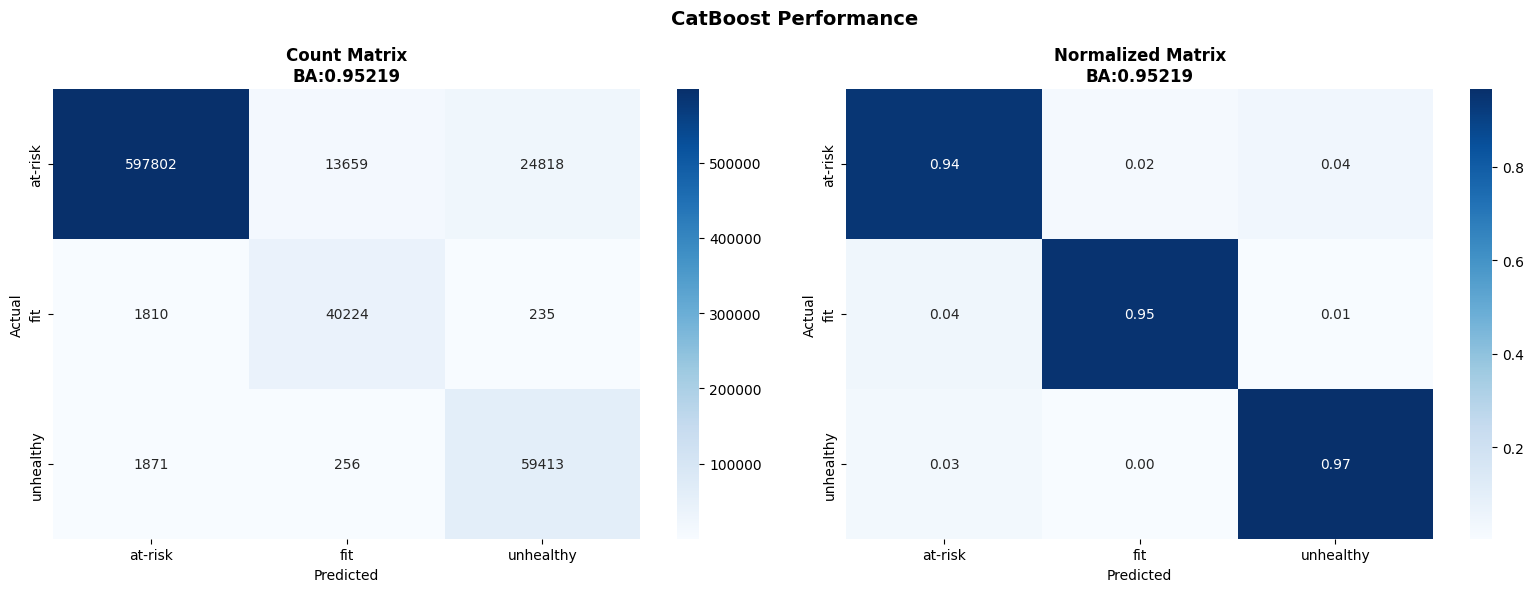

2026-07-04 01:10:43 | INFO     | ================================================================================
2026-07-04 01:10:43 | INFO     | CatBoost
2026-07-04 01:10:43 | INFO     | ================================================================================
2026-07-04 01:10:43 | INFO     | Original BA : 0.95219
2026-07-04 01:10:43 | INFO     | Optimized BA : 0.95219
2026-07-04 01:10:43 | INFO     | 
              precision    recall  f1-score   support

     at-risk       0.99      0.94      0.97    636279
         fit       0.74      0.95      0.83     42269
   unhealthy       0.70      0.97      0.81     61540

    accuracy                           0.94    740088
   macro avg       0.81      0.95      0.87    740088
weighted avg       0.96      0.94      0.95    740088



In [26]:
CAT_PARAMS = {
    "iterations": 12000,
    "learning_rate": 0.03,
    "depth": 8,
    "l2_leaf_reg": 5,
    "loss_function": "MultiClass",
    "auto_class_weights": "Balanced",
    "eval_metric": "TotalF1",
    "random_seed": CFG.RANDOM_STATE,
    "verbose": 200,
    "early_stopping_rounds": 1000,
    "task_type": "GPU",
    "cat_features": CAT_FEATURES,
    "bootstrap_type": "Bernoulli",
    "min_data_in_leaf": 20,
    "subsample": 0.8
}
skf = StratifiedKFold(n_splits=CFG.N_SPLIT_KFOLD, shuffle=True, random_state=CFG.RANDOM_STATE)

# CatBoost
cb_results = train_cv_model(
    model_name="CatBoost",
    model_class=CatBoostClassifier,
    model_params=CAT_PARAMS,
    X=X,
    y=y,
    X_test=X_test,
    skf=skf
)

labels = ["at-risk", "fit", "unhealthy"]
labels = np.unique(y)
display_labels = le.inverse_transform(labels)

cb_evaluate = evaluate_model(
    y_true=y.values,
    oof_probs=cb_results["oof_probs"],
    labels=labels,
    display_labels=display_labels,
    model_name="CatBoost"
)

## XGBClassifier

2026-07-04 01:10:43 | INFO     | Training XGBoost...
2026-07-04 01:10:44 | INFO     | ==================== Fold 1 ====================
[0]	validation_0-mlogloss:1.06938	validation_1-mlogloss:1.06937
[500]	validation_0-mlogloss:0.17530	validation_1-mlogloss:0.17782
[1000]	validation_0-mlogloss:0.17030	validation_1-mlogloss:0.17479
[1500]	validation_0-mlogloss:0.16920	validation_1-mlogloss:0.17416
[2000]	validation_0-mlogloss:0.16856	validation_1-mlogloss:0.17378
[2500]	validation_0-mlogloss:0.16796	validation_1-mlogloss:0.17337
[3000]	validation_0-mlogloss:0.16773	validation_1-mlogloss:0.17326
[3500]	validation_0-mlogloss:0.16750	validation_1-mlogloss:0.17313
[4000]	validation_0-mlogloss:0.16732	validation_1-mlogloss:0.17303
[4500]	validation_0-mlogloss:0.16714	validation_1-mlogloss:0.17293
[5000]	validation_0-mlogloss:0.16697	validation_1-mlogloss:0.17282
[5500]	validation_0-mlogloss:0.16685	validation_1-mlogloss:0.17277
[6000]	validation_0-mlogloss:0.16678	validation_1-mlogloss:0.1727

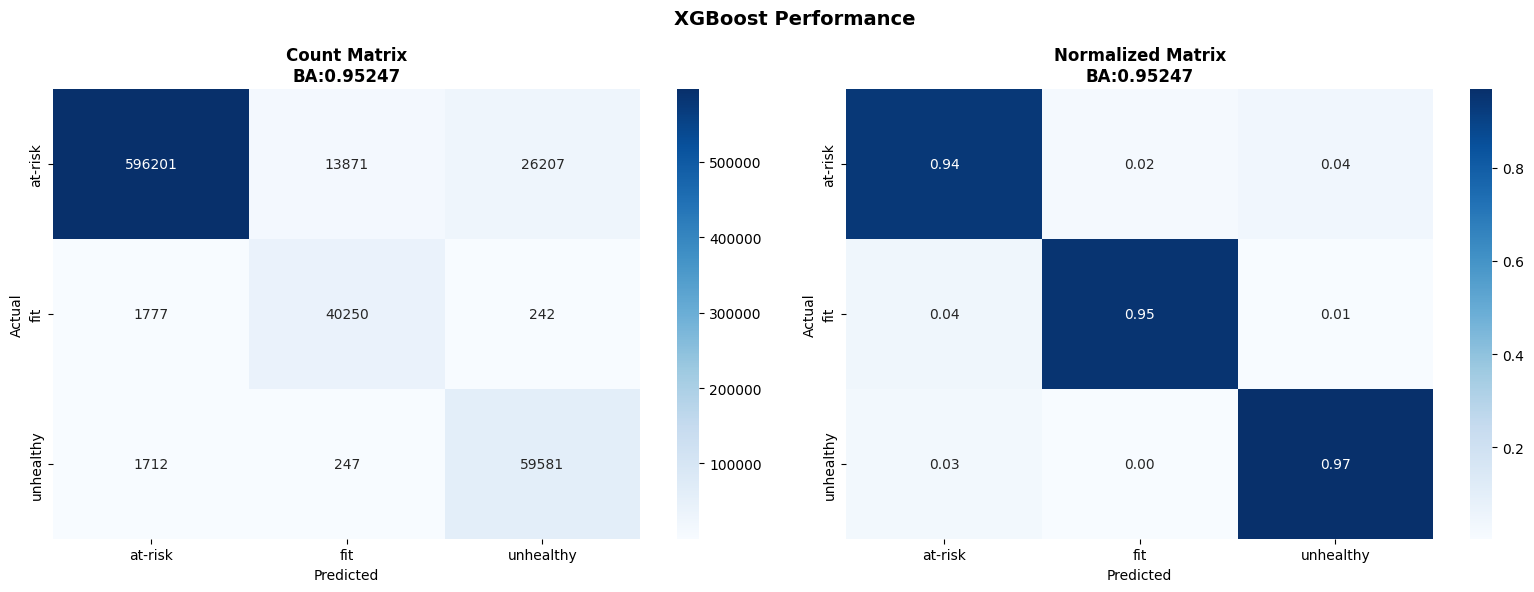

2026-07-04 01:22:06 | INFO     | ================================================================================
2026-07-04 01:22:06 | INFO     | XGBoost
2026-07-04 01:22:06 | INFO     | ================================================================================
2026-07-04 01:22:06 | INFO     | Original BA : 0.95238
2026-07-04 01:22:06 | INFO     | Optimized BA : 0.95247
2026-07-04 01:22:06 | INFO     | 
              precision    recall  f1-score   support

     at-risk       0.99      0.94      0.96    636279
         fit       0.74      0.95      0.83     42269
   unhealthy       0.69      0.97      0.81     61540

    accuracy                           0.94    740088
   macro avg       0.81      0.95      0.87    740088
weighted avg       0.95      0.94      0.94    740088



In [27]:
XGB_PARAMS = {
    "max_depth":5,
    "learning_rate":0.03,
    "min_child_weight":2.3,
    "subsample":0.95,
    "colsample_bytree":0.55,
    "gamma":3.5,
    "reg_alpha":1e-7,
    "reg_lambda":1e-4,
    "objective":"multi:softprob",
    "num_class":len(np.unique(y)),
    "tree_method":"hist",
    "device":"cuda",
    "enable_categorical":True,
    "eval_metric":"mlogloss",
    "random_state":CFG.RANDOM_STATE,
    "n_estimators":12000,
    "early_stopping_rounds":1000,
    "n_jobs":-1
}

# XGB
xgb_results = train_cv_model(
    model_name="XGBoost",
    model_class=XGBClassifier,
    model_params=XGB_PARAMS,
    X=X,
    y=y,
    X_test=X_test,
    skf=skf,
    use_sample_weight=True
)

# XGBoost
xgb_evaluate = evaluate_model(
    y_true=y.values,
    oof_probs=xgb_results["oof_probs"],
    labels=labels,
    display_labels=display_labels,
    model_name="XGBoost"
)

## LGBMClassifier

2026-07-04 01:22:07 | INFO     | Training LightGBM...
2026-07-04 01:22:07 | INFO     | ==================== Fold 1 ====================
[500]	valid_0's multi_logloss: 0.153451
[1000]	valid_0's multi_logloss: 0.133037
2026-07-04 01:25:47 | INFO     | Fold 1 BA: 0.95171
2026-07-04 01:25:47 | INFO     | ==================== Fold 2 ====================
[500]	valid_0's multi_logloss: 0.154659
[1000]	valid_0's multi_logloss: 0.133901
2026-07-04 01:29:27 | INFO     | Fold 2 BA: 0.95195
2026-07-04 01:29:27 | INFO     | ==================== Fold 3 ====================
[500]	valid_0's multi_logloss: 0.154733
[1000]	valid_0's multi_logloss: 0.134186
2026-07-04 01:33:04 | INFO     | Fold 3 BA: 0.95055
2026-07-04 01:33:04 | INFO     | ==================== Fold 4 ====================
[500]	valid_0's multi_logloss: 0.153387
[1000]	valid_0's multi_logloss: 0.132914
2026-07-04 01:36:38 | INFO     | Fold 4 BA: 0.95137
2026-07-04 01:36:38 | INFO     | ==================== Fold 5 ====================
[500

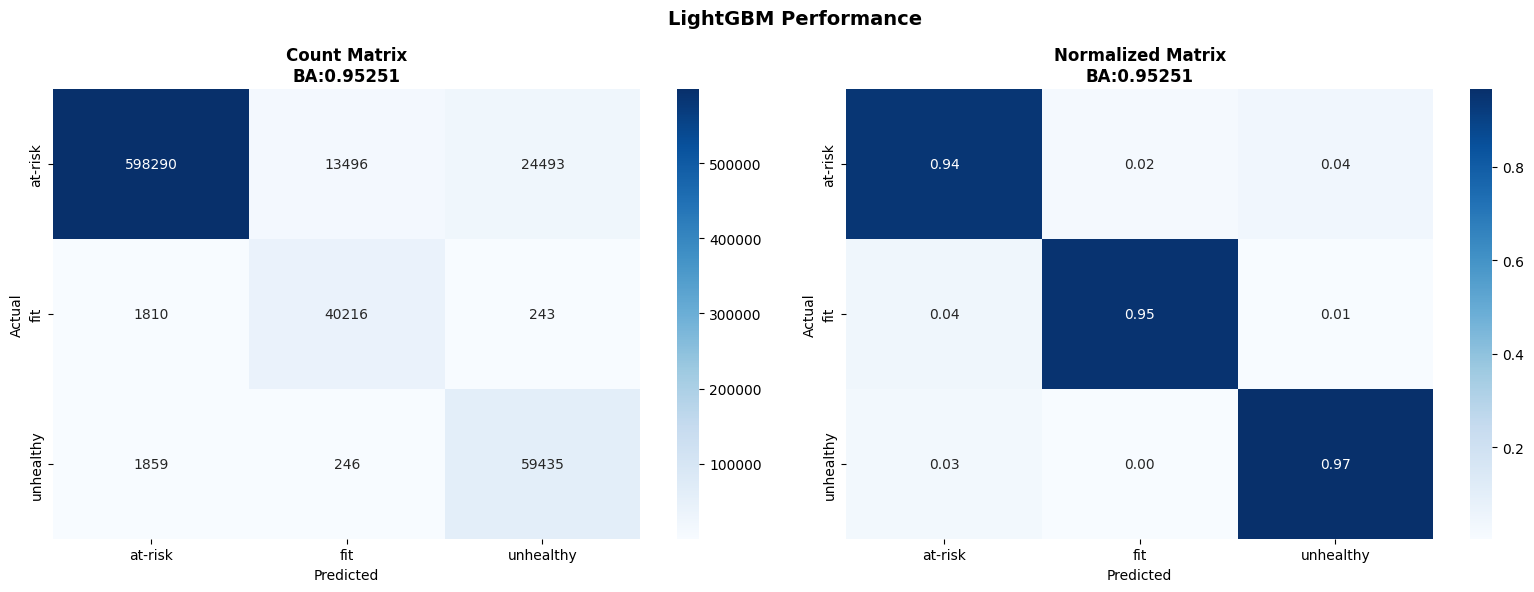

2026-07-04 01:41:46 | INFO     | ================================================================================
2026-07-04 01:41:46 | INFO     | LightGBM
2026-07-04 01:41:46 | INFO     | ================================================================================
2026-07-04 01:41:46 | INFO     | Original BA : 0.95116
2026-07-04 01:41:46 | INFO     | Optimized BA : 0.95251
2026-07-04 01:41:46 | INFO     | 
              precision    recall  f1-score   support

     at-risk       0.99      0.94      0.97    636279
         fit       0.75      0.95      0.84     42269
   unhealthy       0.71      0.97      0.82     61540

    accuracy                           0.94    740088
   macro avg       0.82      0.95      0.87    740088
weighted avg       0.96      0.94      0.95    740088



In [28]:
LGB_PARAMS = {
    "objective": "multiclass",
    "num_class": len(np.unique(y)),
    "metric": "multi_logloss",
    "learning_rate": 0.03350423632108031,
    "n_estimators": 1000,
    "num_leaves": 72,
    "max_depth": 11,
    "min_child_samples": 209,
    "lambda_l2": 1.0,
    "feature_fraction": 0.85,
    "bagging_fraction": 0.85,
    "bagging_freq": 1,
    "class_weight": "balanced",
    "random_state": CFG.RANDOM_STATE,
    "n_jobs": -1,
    "verbose": -1,
    "reg_alpha": 0.6389513105683502,
    "reg_lambda": 0.0023641328616806918
}

# LGBM
lgb_results = train_cv_model(
    model_name="LightGBM",
    model_class=LGBMClassifier,
    model_params=LGB_PARAMS,
    X=X,
    y=y,
    X_test=X_test,
    skf=skf
)

# LightGBM
lgb_evaluate = evaluate_model(
    y_true=y.values,
    oof_probs=lgb_results["oof_probs"],
    labels=labels,
    display_labels=display_labels,
    model_name="LightGBM"
)

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Evaluation</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Evaluation
    </h1>
</div>

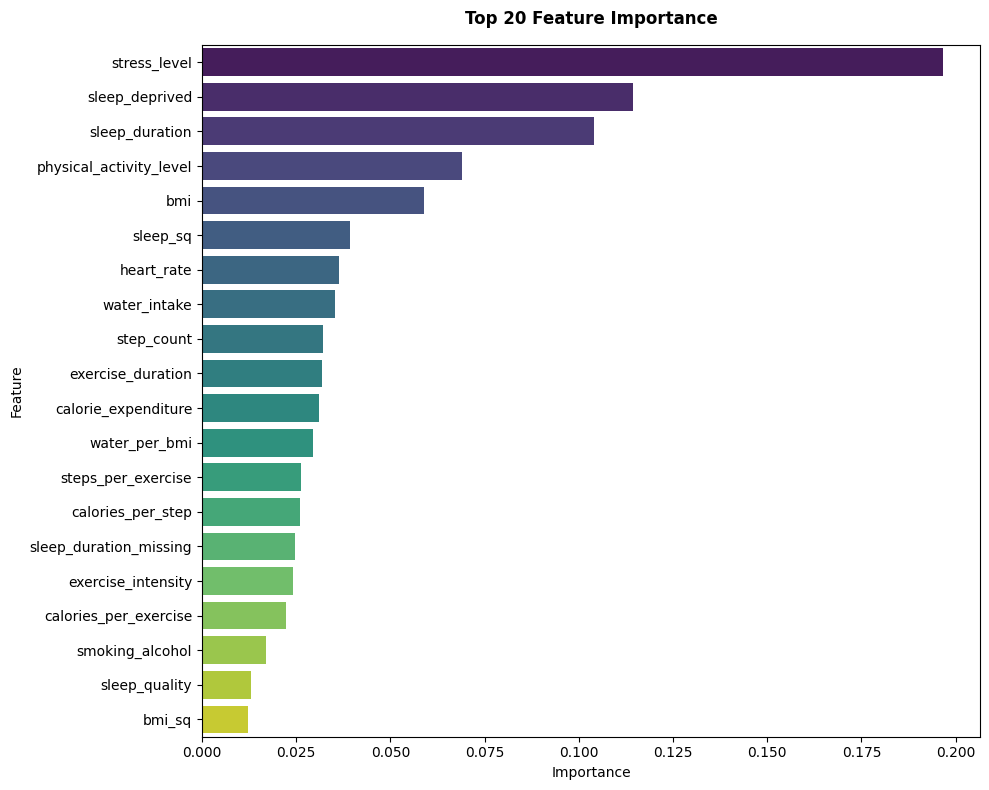

In [29]:
cb_imp = np.mean(cb_results["feature_importances"], axis=0)
xgb_imp = np.mean(xgb_results["feature_importances"], axis=0)
lgb_imp = np.mean(lgb_results["feature_importances"], axis=0)

cb_imp /= cb_imp.sum()
xgb_imp /= xgb_imp.sum()
lgb_imp /= lgb_imp.sum()

ensemble_importance = (cb_imp + xgb_imp + lgb_imp) / 3

df_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": ensemble_importance
}).sort_values(by="Importance", ascending=False).head(20)

plt.figure(figsize=(10, 8))
plt.title("Top 20 Feature Importance", fontsize=12, pad=15, weight="bold") 
ax = sns.barplot(x="Importance", y="Feature", data=df_importance, palette="viridis")
plt.tight_layout()
plt.show()

In [30]:
def save_submission(probs, filename, weighted=False):    
    if weighted:
        labels = probs
    else:
        labels = np.argmax(probs, axis=1)
    submission = pd.DataFrame({
        "id": list_test_id,
        CFG.TARGET_FEATURE: le.inverse_transform(labels)
    })
    submission.to_csv(filename, index=False)
    return submission

In [31]:
# APPLY CLASS WEIGHTS TO PROBABILITIES
weighted_test_probs_xgb = xgb_results["test_probs"] * xgb_evaluate["weights"]
weighted_test_probs_cb  = cb_results["test_probs"] * cb_evaluate["weights"]
weighted_test_probs_lgbm  = lgb_results["test_probs"] * lgb_evaluate["weights"]

y_test_pred_xgb = np.argmax(weighted_test_probs_xgb, axis=1)
y_test_pred_cb  = np.argmax(weighted_test_probs_cb, axis=1)
y_test_pred_lgb  = np.argmax(weighted_test_probs_lgbm, axis=1)

# ENSEMBLE (probability averaging)
# Normalize probabilities after class weighting
weighted_test_probs_xgb /= weighted_test_probs_xgb.sum(axis=1, keepdims=True)
weighted_test_probs_cb /= weighted_test_probs_cb.sum(axis=1, keepdims=True)
weighted_test_probs_lgbm /= weighted_test_probs_lgbm.sum(axis=1, keepdims=True)

# Ensemble
ensemble_probs = (weighted_test_probs_xgb + weighted_test_probs_cb + weighted_test_probs_lgbm) / 3
y_test_pred_final = np.argmax(ensemble_probs, axis=1)

# Decode labels
y_test_pred_final_labels = le.inverse_transform(y_test_pred_final)

# SAVE SUBMISSIONS
save_submission(
    lgb_results["test_probs"],
    "submission_lgb_original.csv"
)

save_submission(
    cb_results["test_probs"],
    "submission_cb_original.csv"
)

save_submission(
    xgb_results["test_probs"],
    "submission_xgb_original.csv"
)

save_submission(
    y_test_pred_xgb,
    "submission_xgb_w.csv",
    weighted=True
)

save_submission(
    y_test_pred_cb,
    "submission_cb_w.csv",
    weighted=True
)

save_submission(
    y_test_pred_lgb,
    "submission_lgb_w.csv",
    weighted=True
)

submission_final = save_submission(
    y_test_pred_final,
    "submission.csv",
    weighted=True
)
submission_final.head()

,id,health_condition
0,690088,unhealthy
1,690089,unhealthy
2,690090,at-risk
3,690091,at-risk
4,690092,unhealthy


<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Recommendation</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Recommendation
    </h1>
</div>

<div style="
    background: linear-gradient(135deg, #14532d, #166534);
    color: #f8fafc;
    padding:25px;
    border-radius:12px;
    margin:25px 0;
    box-shadow:0 6px 18px rgba(0,0,0,0.25);
">

<div style="
    color:#fde68a;
    font-size:22px;
    font-weight:600;
    margin-bottom:18px;
">
💡 Recommendations
</div>

<ul style="font-size:15px; line-height:1.8;">

<li>
<b>Promote regular physical activity</b> by encouraging daily exercise and higher step counts, as these show the strongest positive association with healthy individuals.
</li>

<li>
<b>Improve sleep habits</b> through initiatives that increase both sleep duration and sleep quality, reducing the likelihood of unhealthy health conditions.
</li>

<li>
<b>Implement stress management programs</b>, including mindfulness, counseling, and workload management, since stress level is one of the strongest predictors of health condition.
</li>

<li>
<b>Encourage healthier lifestyles</b> by promoting balanced diets, maintaining healthy BMI, and reducing smoking and alcohol consumption.
</li>

<li>
<b>Prioritize intervention on lifestyle behaviors</b> rather than demographic characteristics, as gender and several physiological measures contribute relatively little to distinguishing health conditions.
</li>

</ul>

<div style="
    margin-top:18px;
    padding:12px 16px;
    background-color:rgba(253,230,138,0.15);
    border-left:4px solid #fde68a;
    border-radius:6px;
    font-size:15px;
">

<b>Overall Recommendation:</b> Preventive health programs should primarily focus on
<b>physical activity, sleep quality, stress management, and healthy lifestyle habits</b>,
as these represent the most influential and actionable factors associated with better health outcomes.

</div>

</div>

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        🙏 Thanks for Reading! 🚀
    </h1>
    <p style="color: #ffffff; font-size: 18px; text-align: center;">
        Happy Coding! 🙌😊
    </p>
</div>
